# **Riconoscere automaticamente il livello CEFR di un testo: un confronto tra metodi a regole, apprendimento automatico e LLM**
Il progetto ha come obiettivo il classificare automaticamente un testo in base al livello linguistico, facendo riferimento al Quadro Comune Europeo di Riferimento per le lingue (*QCER*), in inglese *CEFR* (Common European Framework of Reference for languages). Verranno esplorati vari metodi, raggruppati in 3 approcci differenti (*Rule-Based, Machine Learning* e *LLM*), e ne verrà valutata la performance su un dataset di testing.


##**Grafici e conclusioni**
**NoteBook 3/3**


Una volta raccolti i *classification_report* in dei file JSON, possiamo elaborarli per vedere quale siano le differenze di performance tra i vari metodi.
I dati a disposizione sono:
1. Dataset **main**:
    * Approcci Rule Based:

        Approccio|Macro-categoria | Categoria specifica | Preprocessing
      -------- |-------------------|------------------|--------------
      Rule Based |Lexical Analysis | Raw Counts |    Tutte e 9 le categorie
      Rule Based |Lexical Analysis | Weight Extraction |    Tutte e 9 le categorie
      Rule Based | Readability | Flesch Kincaid |    Tutte e 9 le categorie
      Rule Based | Readability | Gunning Fog |    Tutte e 9 le categorie
      Rule Based | Readability | Coleman Liau|    Tutte e 9 le categorie
      Rule Based | Readability | ARI  |    Tutte e 9 le categorie

    * Approcci Machine Learning:

      Approccio| Macro-categoria | Categoria specifica | Preprocessing
      -------|-------------------|------------------|--------------
      Machine Learning | Tradizionale | Random Forest |    Tutte e 9 le categorie
        Machine Learning |Tradizionale | Logistic Regression |    Tutte e 9 le categorie
        Machine Learning |Tradizionale | Gradient Boosting |    Tutte e 9 le categorie
        Machine Learning |FastText | FastText |    Tutte e 9 le categorie

    * Approcci LLM:
        Approccio|Macro-categoria | Categoria specifica | Preprocessing
      -------- |-------------------|------------------|--------------
      LLM |Gemini | Few Shot |    0.raw
      LLM |Gemini | Zero Shot |    0.raw

1. Dataset **generalized**:
    * Approcci Rule Based:

        Approccio|Macro-categoria | Categoria specifica | Preprocessing
      -------- |-------------------|------------------|--------------
      Rule Based |Lexical Analysis | Raw Counts |    Tutte e 9 le categorie
      Rule Based |Lexical Analysis | Weight Extraction |    Tutte e 9 le categorie
      Rule Based | Readability | Flesch Kincaid |    Tutte e 9 le categorie
      Rule Based | Readability | Gunning Fog |    Tutte e 9 le categorie
      Rule Based | Readability | Coleman Liau|    Tutte e 9 le categorie
      Rule Based | Readability | ARI  |    Tutte e 9 le categorie

    * Approcci Machine Learning:

      Approccio| Macro-categoria | Categoria specifica | Preprocessing
      -------|-------------------|------------------|--------------
      Machine Learning | Tradizionale | Random Forest |    Tutte e 9 le categorie
        Machine Learning |Tradizionale | Logistic Regression |    Tutte e 9 le categorie
        Machine Learning |Tradizionale | Gradient Boosting |    Tutte e 9 le categorie
        Machine Learning |FastText | FastText |    Tutte e 9 le categorie

    * Approcci LLM:
        Approccio|Macro-categoria | Categoria specifica | Preprocessing
      -------- |-------------------|------------------|--------------
      LLM | Nessuno | Nessuno |    Nessuno





A partire dai vari dati, per entrambi i dataset, è possibile svolgere varie analisi:
1. Per ogni metodo, vedere come ha performato e se ci sono differenze con il dataset generalizzato ;
2. Vedere il migliore metodo per ogni approccio (Rule-Based, LM e LLM) ;
3. Paragonare i vari metodi migliori per identificare il migliore approccio.


##**Importazione dati e librerie**

In [1]:
import os
import json
import zipfile

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

import gdown

In [2]:
url = r'https://drive.google.com/uc?id=1DF2qp68Cd9xMwyGj8lY3mKi4P49702if'
gdown.download(url, 'material_notebook_3.zip', quiet=True)

'material_notebook_3.zip'

In [3]:
zip_file_path = r'/content/material_notebook_3.zip'
extract_dir = r'/content/material_notebook_3'

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

In [4]:
main_path = r'/content/material_notebook_3/final_reports'
for file_path in [f for f in os.listdir(main_path) if f.endswith('.json')]:
  with open(os.path.join(main_path,file_path), 'r') as f:
    if 'main' in file_path:
      main_results = json.load(f)
    elif 'generalized' in file_path:
      generalized_results = json.load(f)

Viene creata una funzione che prende come argomento l'insieme di tipologie di preprocessing e, in base alla F1-Score della *Weighted Average*, estrae quella migliore, e ritorna un dizionario con la seguente struttura:


```
{
'preprocessing_type' : chiave_dell_argomento,
'classification_report' : classification_report
}
```

In [5]:
def retrieve_best_weightedF1(method):
    best_preprocessing_type_key = max(method, key=lambda k: method[k]['weighted avg']['f1-score'])

    return {
        'preprocessing_type': best_preprocessing_type_key,
        'classification_report': method[best_preprocessing_type_key]
    }

Dopo aver importato i file e creato la funzione, il loro contenuto viene "livellato", in modo da avere la seguente struttura:

* Dataset Main
  * Approcci Rule-Based :
    * Raw Counts ;
    * Weight Extraction ;
    * Flesch Kincaid Formula ;
    * ... ;
    * ARI
  * Approcci Machine Learning :
      * Random Forest ;
      * ... ;
      * Fasttext
  * Approccio LLM :
      * Zero Shot ;
      * Few Shot

* Dataset Generalizzato
  * Approcci Rule-Based :
    * Raw Counts ;
    * Weight Extraction ;
    * Flesch Kincaid Formula ;
    * ... ;
    * ARI
  * Approcci Machine Learning :
      * Random Forest ;
      * ... ;
      * Fasttext

Dove ogni metodo avrà la struttura di output di *retrieve_best_weightedF1(method)*.

In [6]:
data = {
    'main': {
        'rule_based': {
            method_name: {
                'approach': 'rule_based',
                'method_name': method_name,
                'preprocessing_type': best_f1_data['preprocessing_type'],
                'classification_report': best_f1_data['classification_report']
            }
            for method_name, method_data in (
                main_results['rule_based']['lexical_analysis']
                | main_results['rule_based']['readability']
            ).items()
            for best_f1_data in [retrieve_best_weightedF1(method_data)]
        },
        'machine_learning': {
            method_name: {
                'approach': 'machine_learning',
                'method_name': method_name,
                'preprocessing_type': best_f1_data['preprocessing_type'],
                'classification_report': best_f1_data['classification_report']
            }
            for method_name, method_data in (
                main_results['machine_learning']['traditional']
                | {'fasttext' : main_results['machine_learning']['fasttext']}
            ).items()
            for best_f1_data in [retrieve_best_weightedF1(method_data)]
        },
        'LLM': {
            method_name: {
                'approach': 'LLM',
                'method_name': method_name,
                'preprocessing_type': best_f1_data['preprocessing_type'],
                'classification_report': best_f1_data['classification_report']
            }
            for method_name, method_data in main_results['LLM']['gemini'].items()
            for best_f1_data in [retrieve_best_weightedF1(method_data)]
        }
    },
    'generalized': {
        'rule_based' : {
            method_name: {
                'approach': 'rule_based',
                'method_name': method_name,
                'preprocessing_type': best_f1_data['preprocessing_type'],
                'classification_report': best_f1_data['classification_report']
            }
            for method_name, method_data in (
                generalized_results['rule_based']['lexical_analysis']
                | generalized_results['rule_based']['readability']
            ).items()
            for best_f1_data in [retrieve_best_weightedF1(method_data)]
          },
        'machine_learning': {
            method_name: {
                'approach': 'machine_learning',
                'method_name': method_name,
                'preprocessing_type': best_f1_data['preprocessing_type'],
                'classification_report': best_f1_data['classification_report']
            }
            for method_name, method_data in (
                generalized_results['machine_learning']['traditional']
                | {'fasttext' : generalized_results['machine_learning']['fasttext']}
            ).items()
            for best_f1_data in [retrieve_best_weightedF1(method_data)]
        }
    }
}

Creiamo anche una funzione che restituisca il miglior metodo per ognuno dei 3 approcci:

In [7]:
def retrieve_best_weightedF1_across_approaches(approaches):
  output = {
      'rule_based': {},
      'machine_learning': {},
      'LLM': {}
          }
  for approach_name, methods_data in approaches.items():
    best_method_key = max(methods_data, key=lambda method_key: methods_data[method_key]['classification_report']['weighted avg']['f1-score'])
    output[approach_name] = methods_data[best_method_key]
  return output

Estraiamo i vari metodi migliori:

In [8]:
approaches_MAIN = data['main']
approaches_GENERALIZED = data['generalized']

best_across_approaches_MAIN = retrieve_best_weightedF1_across_approaches(approaches_MAIN)
best_across_approaches_GENERALIZED = retrieve_best_weightedF1_across_approaches(approaches_GENERALIZED)

###**Metriche**
Le metriche usate per la valutazione delle performance saranno quelle fornite dal *classification_report* di SKLearn, quindi:
####**Per ogni metodo, per ogni etichetta:**


  ---
  \begin{equation} Precision = \frac{TP}{TP+FP}\end{equation}

  Di tutte le etichette predette come positive, quante effettivamente lo erano?
  ---
  ---
  \begin{equation} Recall = \frac{TP}{TP+FN}\end{equation}

  Di tutte le etichette effettivamente positive (TP), quante sono state correttamente identificate dal modello?
  ---
  ---    
  \begin{equation} F1 = 2* \frac{Precision*Recall}{Precision+Recall}\end{equation}

  Media armonica tra Precision e Recall, in modo da bilanciare quando una delle due misure è molto buona (o molto poco buona) rispetto all'altra
  ---
  ---
####**Per il paragone tra i vari metodi:**
  * *Weighted-F1*: media delle metriche per ogni classe, "pesata" in modo da contrastare le classi altamente sbilanciate.

###**Funzioni per i grafici**
Vengono qui definite varie funzioni per mostrare graficamente i risultati nelle sezioni successive:

In [9]:
# @title 1. Heatmap Precision, Recall e F1-Score per ogni metodo
def display_report_heatmap(method_data):
  """
  This function displays Precision, Recall and F1-Score as a heatmap for a single method (raw_counts, ari, fasttext, ...)
  """
  classification_report_data = method_data['classification_report']
  method_name = ' '.join([item.capitalize() for item in method_data['method_name'].split('_')]).strip(' ')
  if 'Ari' in method_name:
    method_name = 'ARI'
  approach = ' '.join([item.capitalize() for item in method_data['approach'].split('_')]).strip(' ')
  if 'Llm' in approach:
    approach = 'LLM'
  preprocessing_type = method_data['preprocessing_type'][2:].capitalize()

  metrics_data = {}
  for label, metrics in classification_report_data.items():
      if label.startswith('__label__') and label.replace('__label__', '') in ['A1', 'A2', 'B1', 'B2', 'C1']:
          metrics_data[label.replace('__label__', '')] = {
              'Precision': metrics['precision'],
              'Recall': metrics['recall'],
              'F1-Score': metrics['f1-score']
          }

  df_metrics = pd.DataFrame.from_dict(metrics_data, orient='index')
  weightedF1 = round(classification_report_data['weighted avg']['f1-score'],ndigits=2)

  with plt.style.context('seaborn-v0_8-paper'):
    fig, ax = plt.subplots(figsize=(8, 4.5), dpi=300)

    sns.heatmap(df_metrics, annot=True, cmap='Blues', fmt=".2f", linewidths=.7, linecolor='black',
                cbar_kws={'label': 'F1-Score', 'shrink': 0.8},
                annot_kws={'fontweight': 'bold'},
                ax=ax)

    ax.set_title(f'{method_name} ({approach})', pad=20, fontsize=14)

    ax.text(0.5, 1.02, f'Preprocessing: {'-'.join([item.capitalize() for item in preprocessing_type.split('_')]).strip('-')} | WeightedF1 : {weightedF1}', transform=ax.transAxes, fontsize=10,
            verticalalignment='bottom', horizontalalignment='center', color='black')

    ax.set_xlabel('Metric', fontsize=12, fontweight='bold')
    ax.set_ylabel('CEFR Level', fontsize=12, fontweight='bold')

    plt.xticks(rotation=0, ha='center', fontsize=10, fontweight='bold')
    plt.yticks(rotation=0, fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

In [10]:
# @title 2. Barplot tra metodi per un approccio

def display_approach_barplot(approach_data):
  """
  This function displays Weighted Average (Precision, Recall and F1-Score) as a barplot for each method in 1 approach (Rule-Based, ML or LLM)
  """

  graph_title = [' '.join(word.capitalize() for word in v['approach'].split('_')) for v in approach_data.values()][0]

  x = np.arange(len(approach_data)) #numero di gruppi da plottare
  y1 = [round(approach_data["classification_report"]["weighted avg"]["precision"],2) for approach_data in approach_data.values()] #dati Precision da plottare
  y2 = [round(approach_data["classification_report"]["weighted avg"]["recall"],2) for approach_data in approach_data.values()] #dati Recall da plottare
  y3 = [round(approach_data["classification_report"]["weighted avg"]["f1-score"],2) for approach_data in approach_data.values()] #dati F1-Score da plottare

  width = 0.3
  plt.figure(figsize=(8, 6),dpi=300)
  bars1 = plt.bar(x - width, y1, width, color='#2845D6', edgecolor = '#F0FFC3')
  bars2 = plt.bar(x, y2, width, color='#1A2CA3', edgecolor = '#F0FFC3')
  bars3 = plt.bar(x + width, y3, width, color='#0D1A63',edgecolor = '#F0FFC3')

  for bar in [bars1, bars2, bars3]:
    plt.bar_label(bar, fmt="%.2f", padding=3, fontsize=6, family='monospace')

  for y in np.arange(0, 1.1, 0.1):
    plt.axhline(y=y, linestyle="--", linewidth=0.6, alpha=0.5, color='grey')

  plt.xticks(x, [
                ' '.join(item.capitalize() for item in key.split('_')).strip() if key.lower() not in ['ari','llm'] else key.upper()for key in approach_data.keys()],
                rotation=45,
                family = 'sans-serif',
                fontweight='medium'
                )

  plt.xlabel("Methods",fontweight='bold')
  plt.ylabel("Scores",fontweight='bold')
  plt.legend([bars1, bars2, bars3], ["Precision", "Recall", "F1-Score"],bbox_to_anchor=(1.20, 1.016))
  plt.title(f'Metrics for {graph_title} methods | Weighted Average',fontweight='bold')
  plt.ylim(0, 1)
  plt.show()


In [11]:
# @title 3. Barplot tra approcci

def display_best_approaches_barplot(approach_data):
  """
  This function displays Weighted Average (Precision, Recall and F1-Score) as a barplot for each method in 1 approach (Rule-Based, ML or LLM)
  """

  filtered_approach_data = {k: v for k, v in approach_data.items() if v}
  if 'LLM' in filtered_approach_data:
    dataset_type = 'main'
  else:
    dataset_type = 'generalized'


  x = np.arange(len(filtered_approach_data)) #numero di gruppi da plottare

  labels = []
  y1 = []
  y2 = []
  y3 = []

  for key, value in filtered_approach_data.items():
    approach_label = ' '.join(item.capitalize() for item in key.split('_')).strip()
    if key.lower() == 'llm':
        approach_label = 'LLM'

    method_name = value['method_name']
    method_label = ' '.join(item.capitalize() for item in method_name.split('_')).strip()
    if method_name.lower() == 'ari':
        method_label = 'ARI'

    labels.append(f"{approach_label}\n({method_label})")
    y1.append(round(value["classification_report"]["weighted avg"]["precision"],2))
    y2.append(round(value["classification_report"]["weighted avg"]["recall"],2))
    y3.append(round(value["classification_report"]["weighted avg"]["f1-score"],2))


  width = 0.3
  plt.figure(figsize=(8, 6),dpi=300)
  bars1 = plt.bar(x - width, y1, width, color='#2845D6', edgecolor = '#F0FFC3')
  bars2 = plt.bar(x, y2, width, color='#1A2CA3', edgecolor = '#F0FFC3')
  bars3 = plt.bar(x + width, y3, width, color='#0D1A63',edgecolor = '#F0FFC3')

  for bar in [bars1, bars2, bars3]:
    plt.bar_label(bar, fmt="%.2f", padding=3, fontsize=10, family='monospace')

  for y in np.arange(0, 1.1, 0.1):
    plt.axhline(y=y, linestyle="--", linewidth=0.6, alpha=0.5, color='grey')


  plt.xticks(x,
                labels,
                rotation=0,
                family = 'sans-serif',
                fontweight='medium'
                )

  plt.xlabel("Methods",fontweight='bold')
  plt.ylabel("Scores",fontweight='bold')
  plt.legend([bars1, bars2, bars3], ["Precision", "Recall", "F1-Score"],bbox_to_anchor=(1.20, 1.016))
  plt.title(f'Best performance for {dataset_type.lower()} dataset | Weighted Average',fontweight='bold')
  plt.ylim(0, 1)
  plt.show()


##**Rule-Based: migliore *Weighted F1-Score***

###**Raw Counts**
Entrambi i dataset hanno una Weighted F1-Score molto bassa, notiamo come ci sia un forte bias nei confronti della classe A1: il "modello" quindi ha predetto correttamente il 98% dei testi effettivamente A1, ma tende a considerare ogni testo A1. Ciò è dovuto alla natura del modello, che semplicemente conta le parole per livello, e alla natura dei testi che, anche su un dataset "Lowercased-Nopunctuation-Nostopwords", sono composti per lo più da parole legate alla classe A1.

####**Dataset *main***

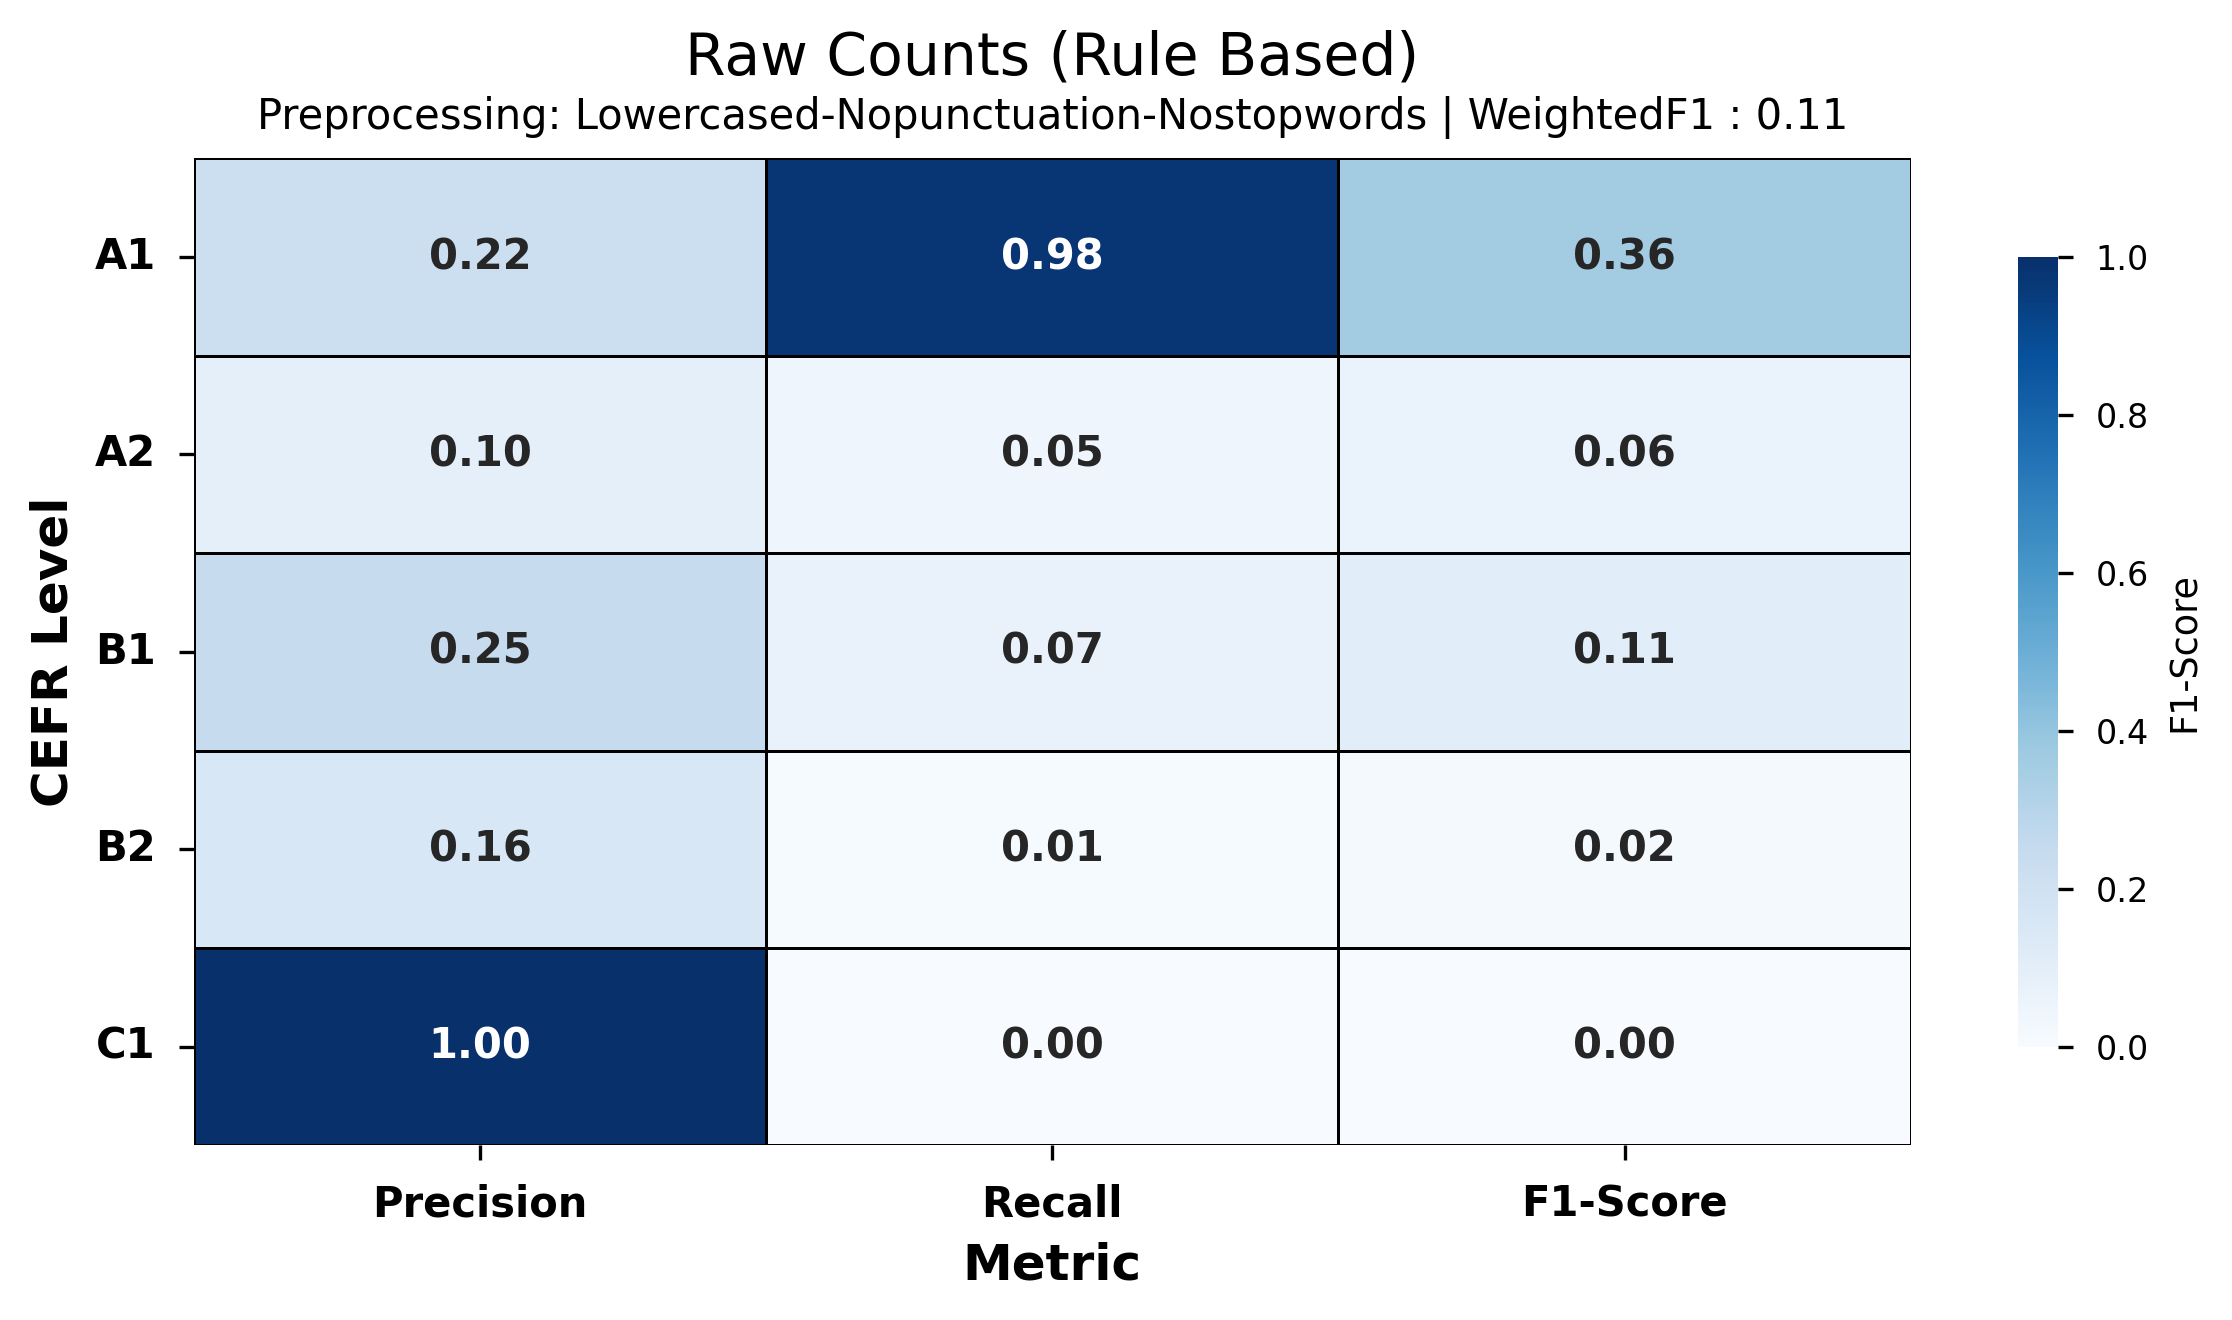

In [12]:
display_report_heatmap(data['main']['rule_based']['raw_counts'])

####**Dataset *generalizzato***

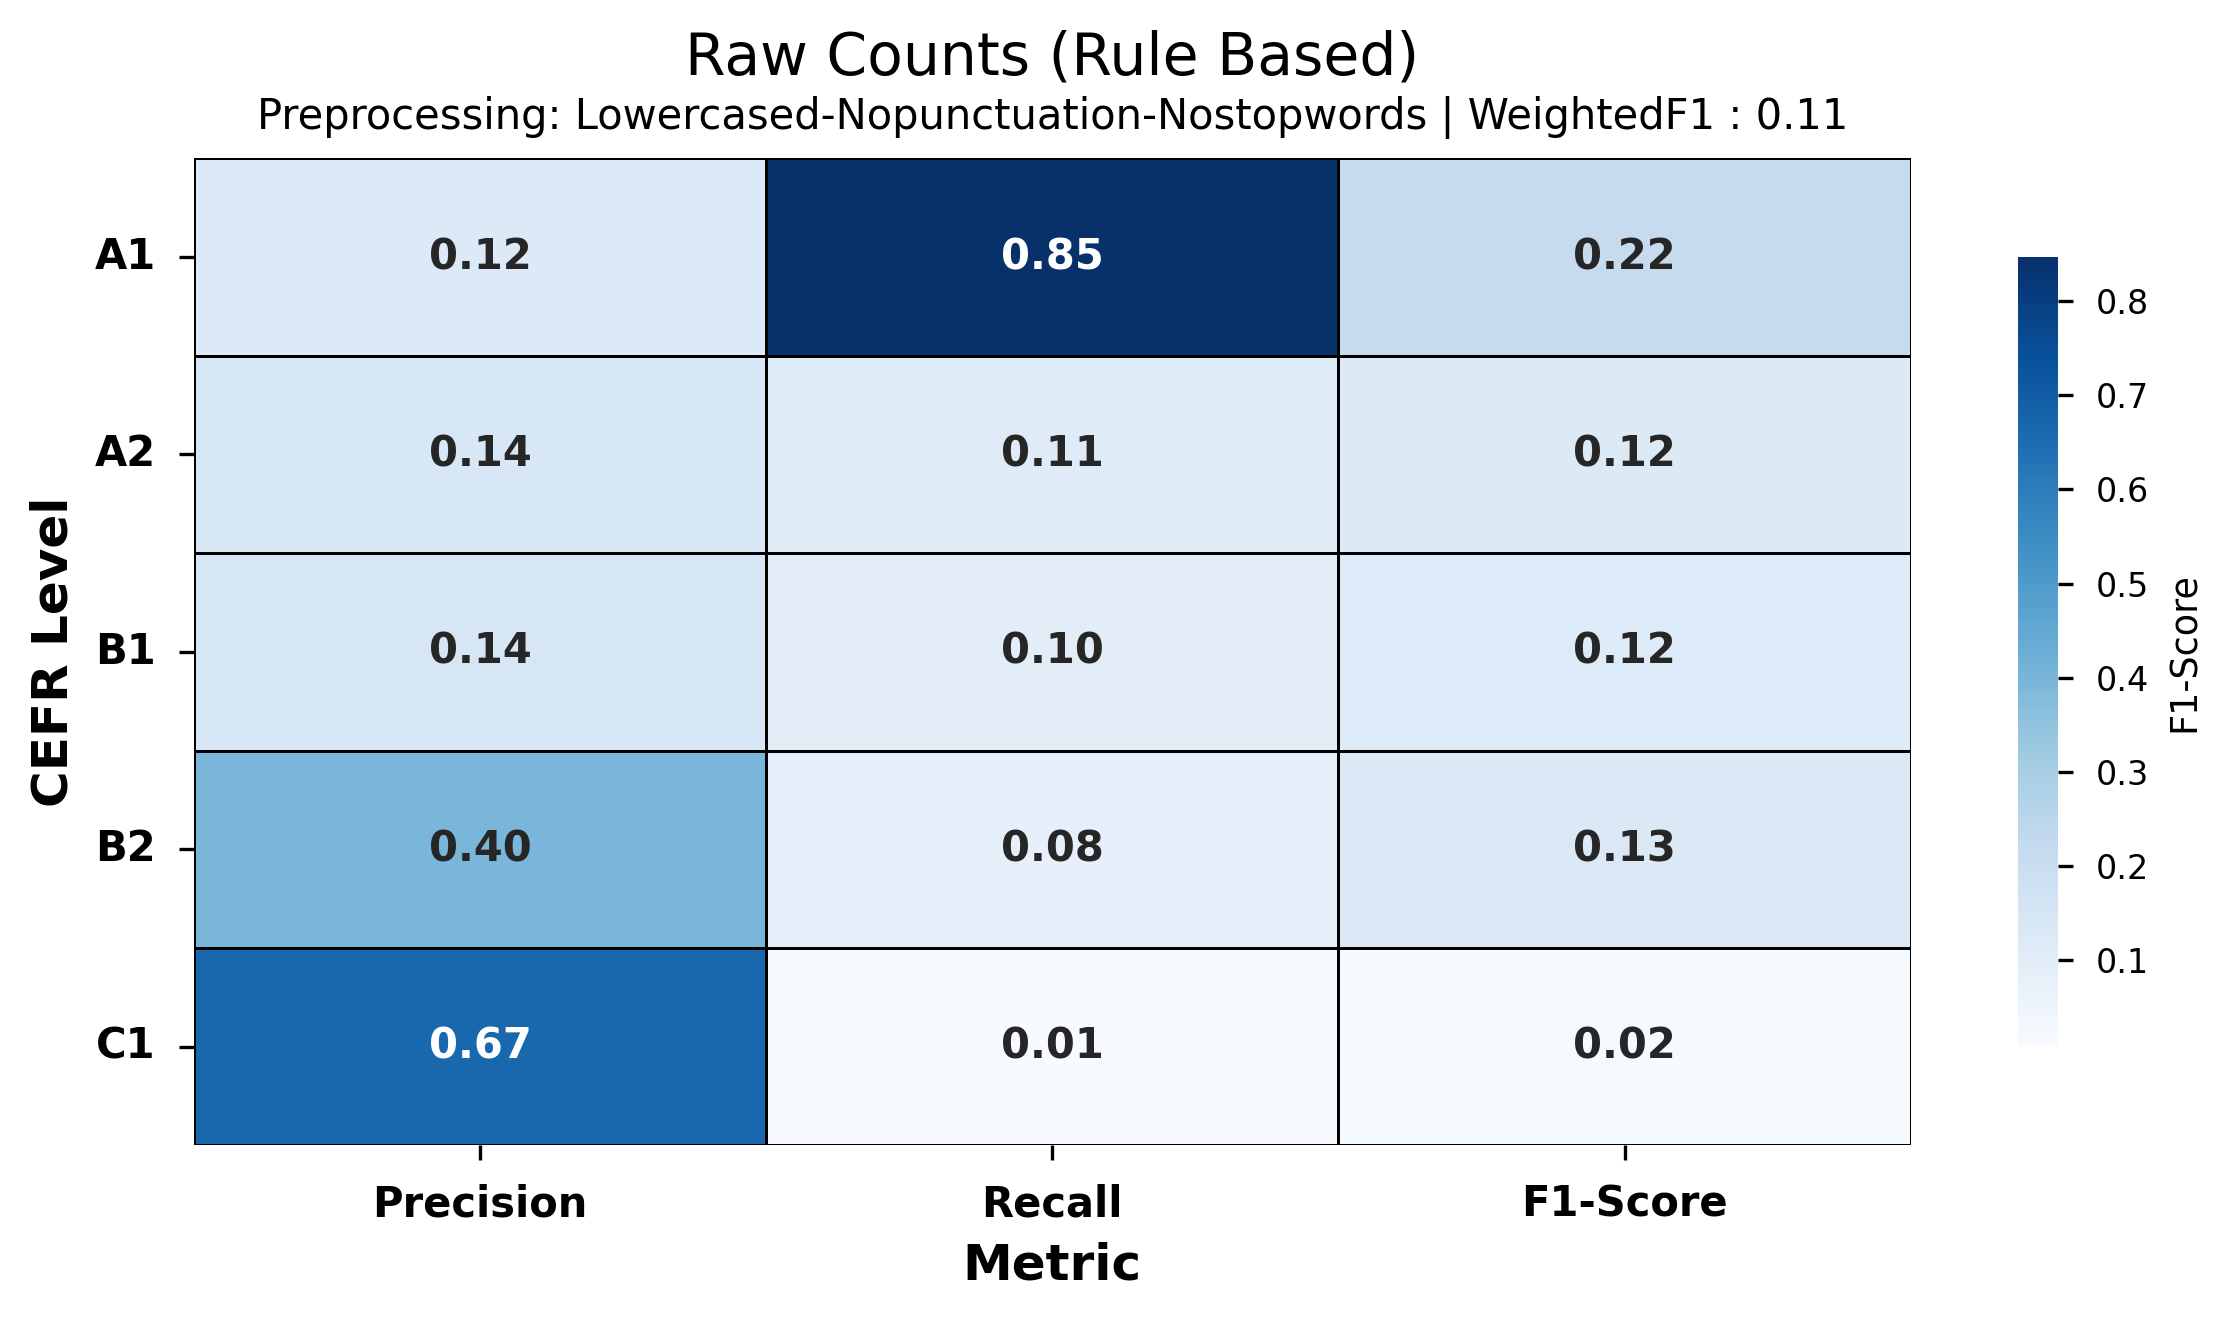

In [13]:
display_report_heatmap(data['generalized']['rule_based']['raw_counts'])

Non ci sono troppe differenze tra i due dataset.

###**Weight Extraction**


####**Dataset *main***
Tramite l'estrazione dei pesi delle parole, notiamo già come ci sia un forte aumento della Weighted F1-Score (0.87). In generale, il "modello" riesce a definire bene quando un testo è A1 o C1 (quindi "agli estremi opposti"), ma tende a confondersi leggermente se un testo è di un livello intermedio:

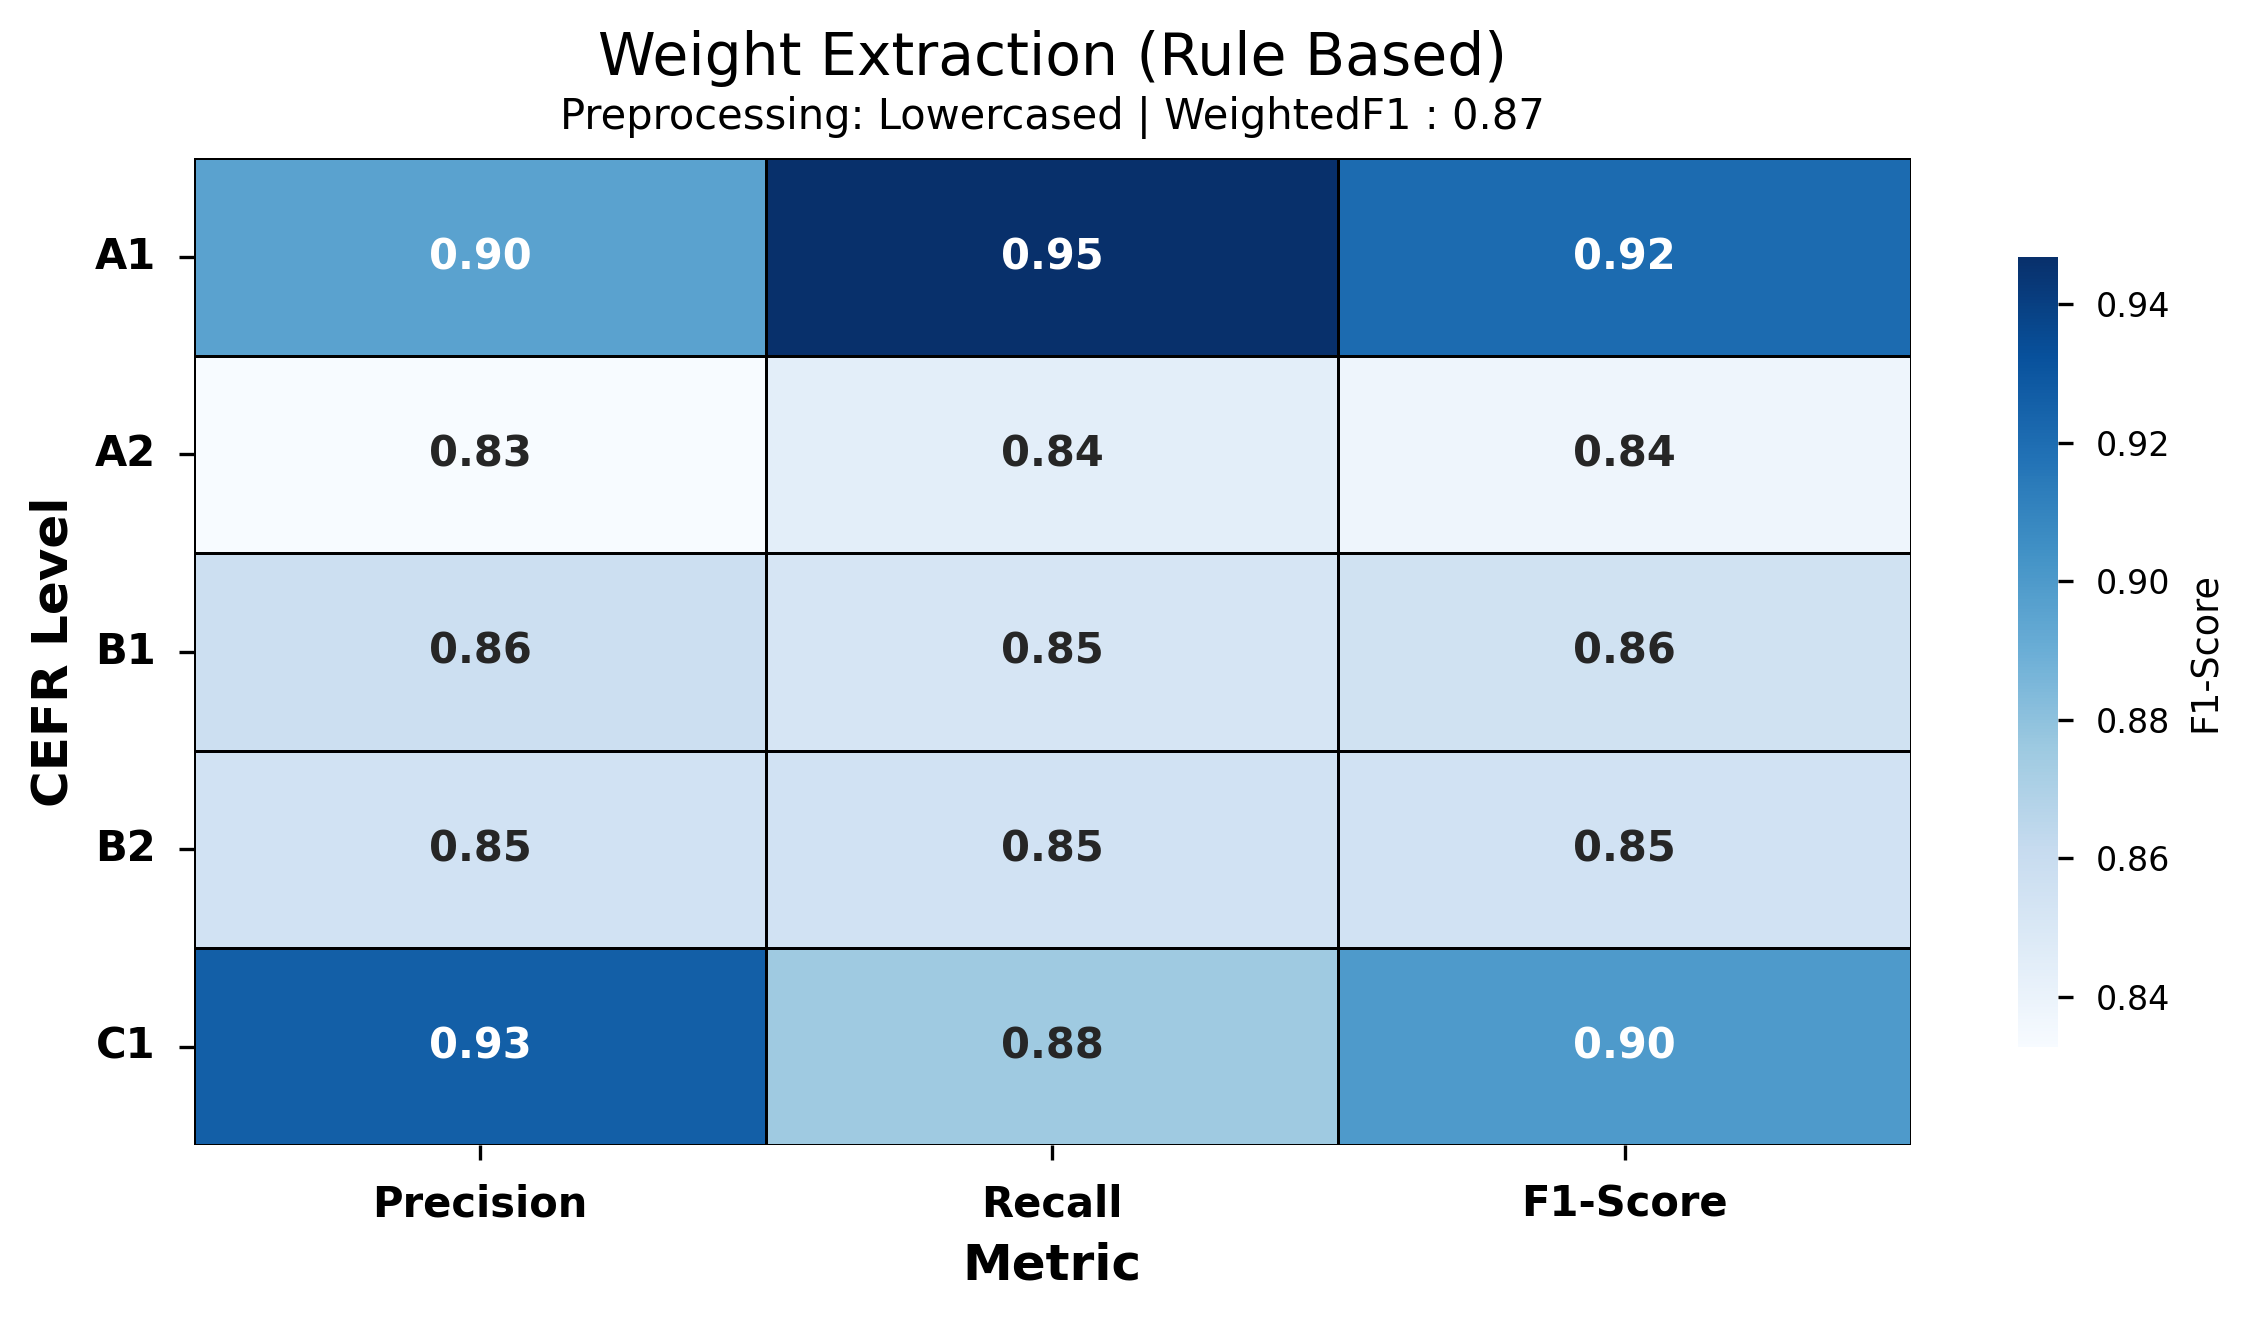

In [14]:
display_report_heatmap(data['main']['rule_based']['weight_extraction'])

####**Dataset *generalizzato***
Tuttavia, notiamo come sia presente una forte dipendenza al dataset di training, dato che, con un dataset per generalizzare, c'è un forte *generalization gap* e la Weighted F1 crolla.

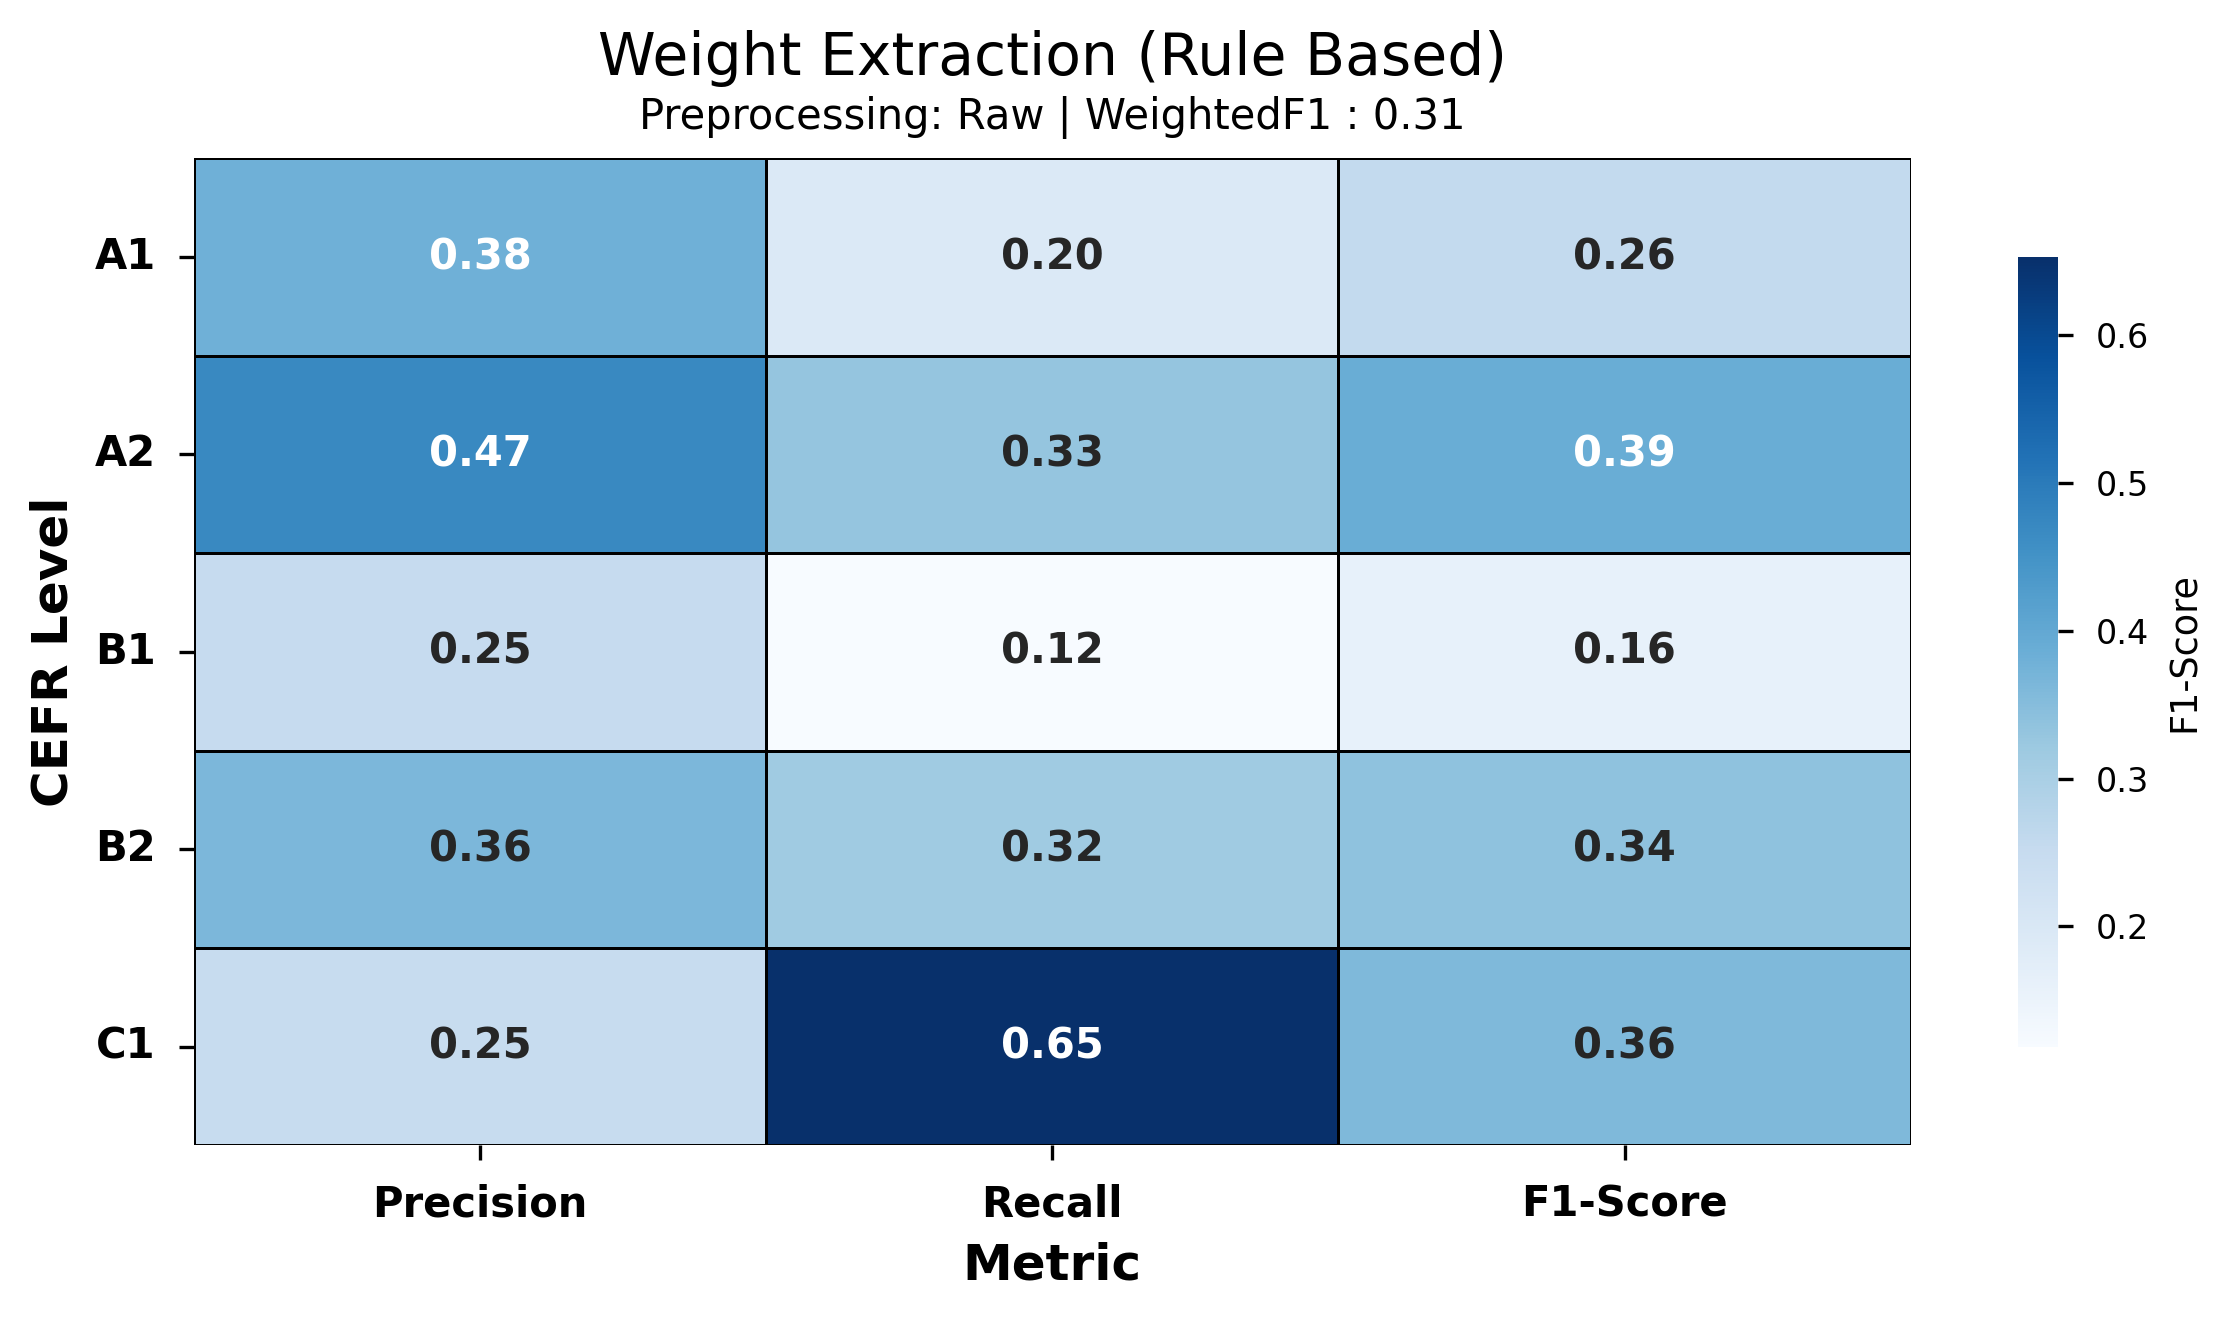

In [15]:
display_report_heatmap(data['generalized']['rule_based']['weight_extraction'])

###**Formule di leggibilità**
In tutte queste formule troviamo come migliore preprocessing il testo senza modifiche ("raw"), se non in Coleman Liau, e notiamo come riescano a predire non troppo male i testi agli estremi opposti (A1 o C1), con una confusione crescente più il testo è "centrale", come nel caso di B1.

###**Flesch Kincaid**
Troviamo un aumento della performance nel dataset generalizzato:

####**Dataset *main***

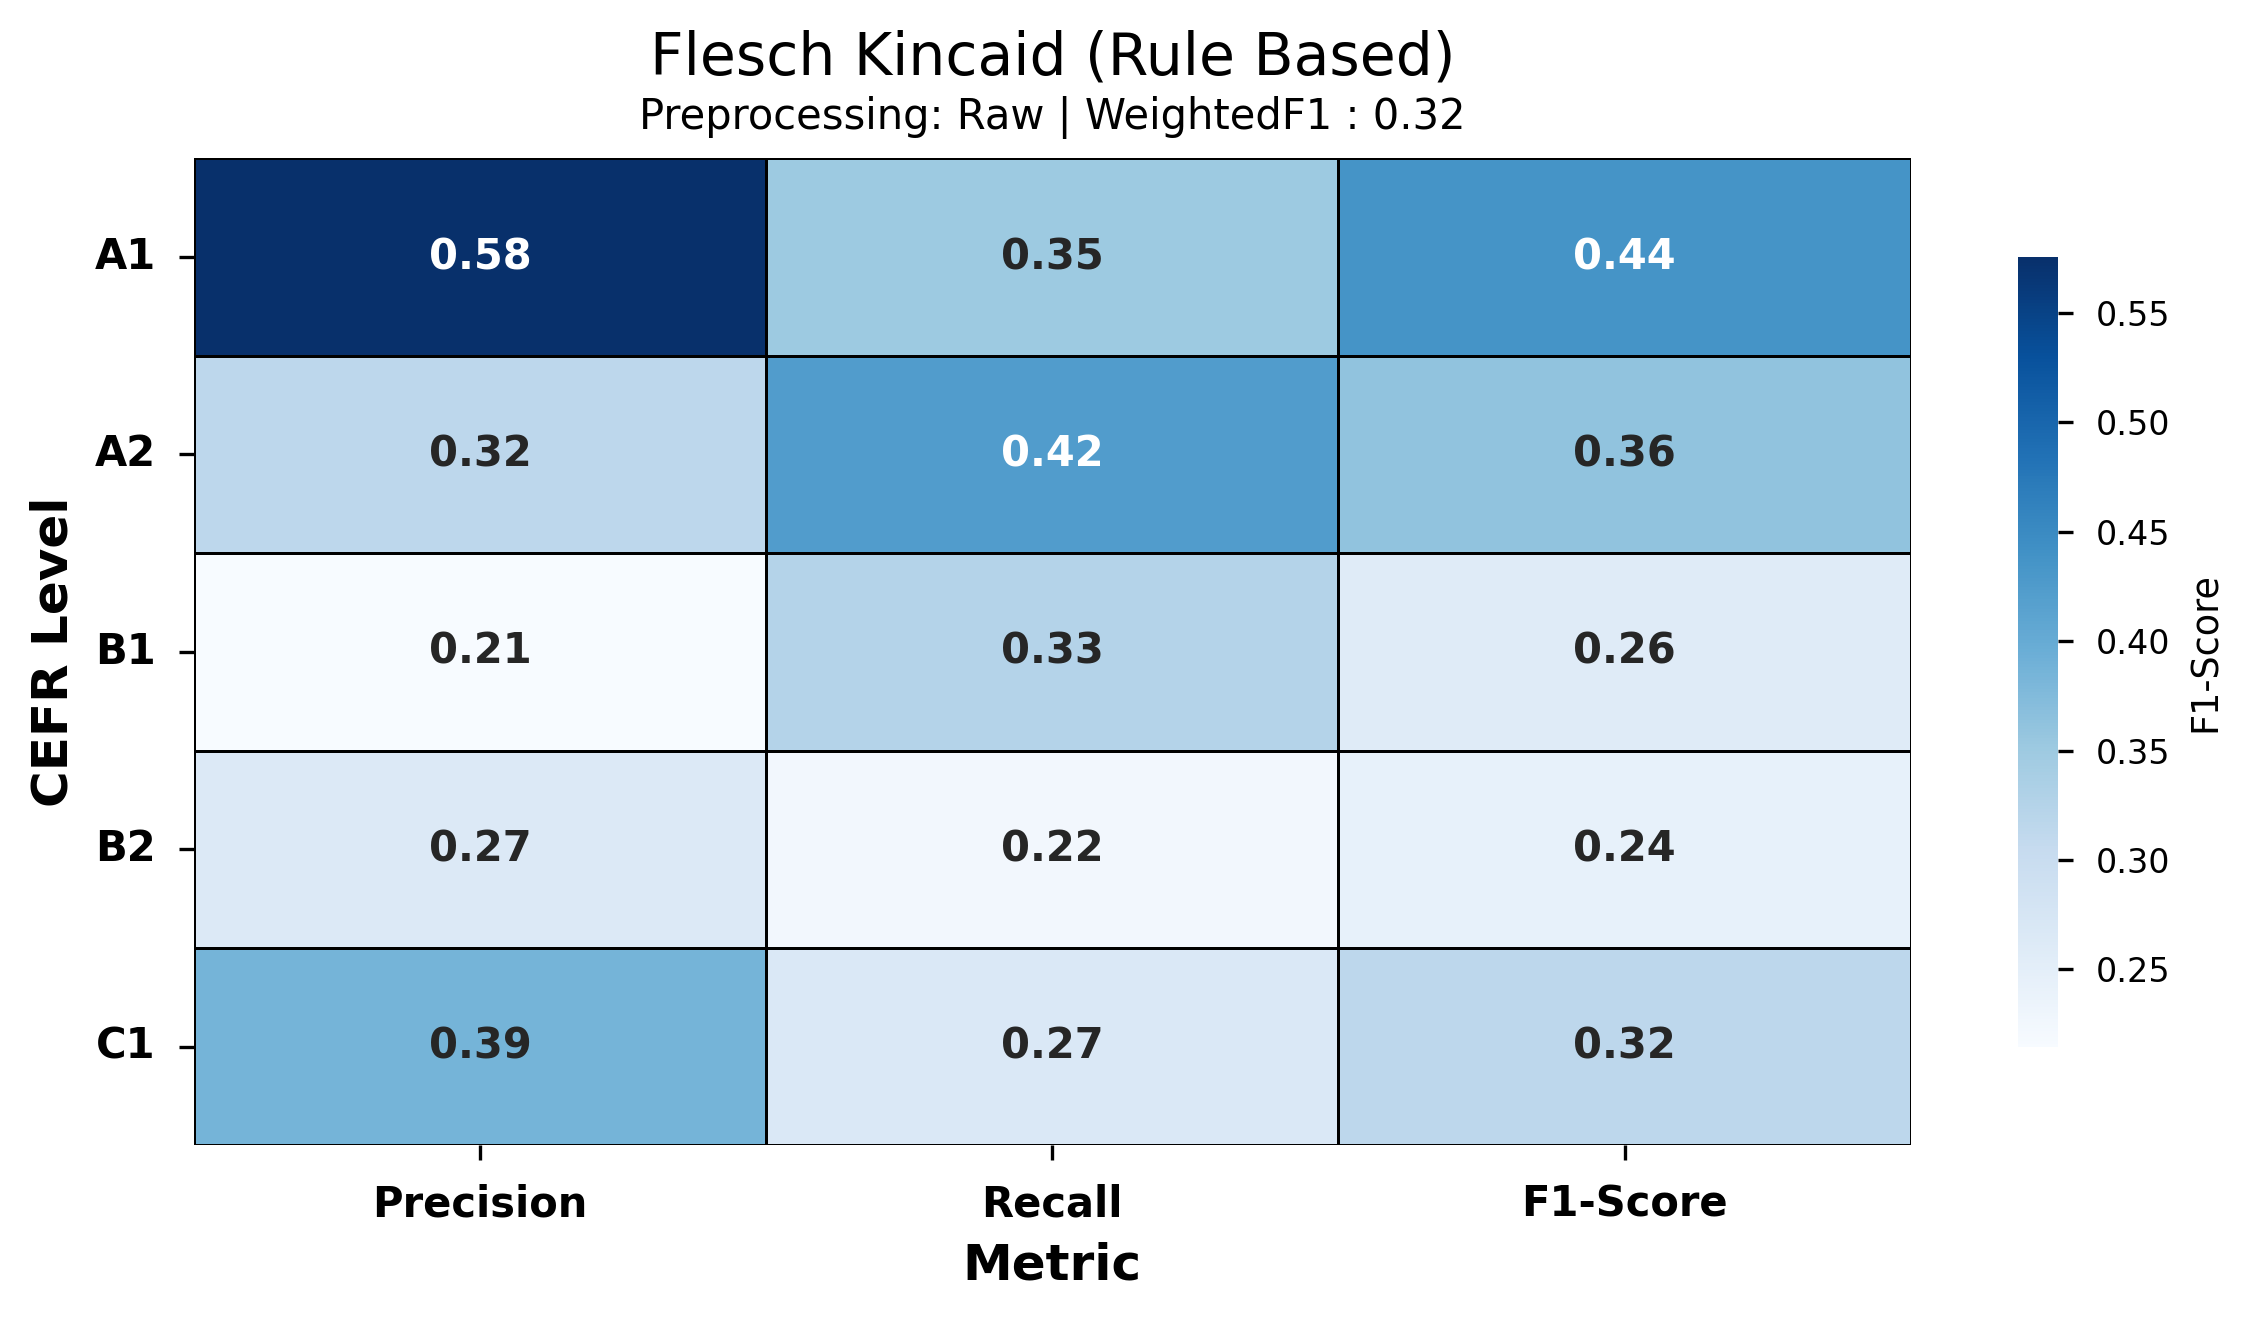

In [16]:
display_report_heatmap(data['main']['rule_based']['flesch_kincaid'])

####**Dataset *generalizzato***

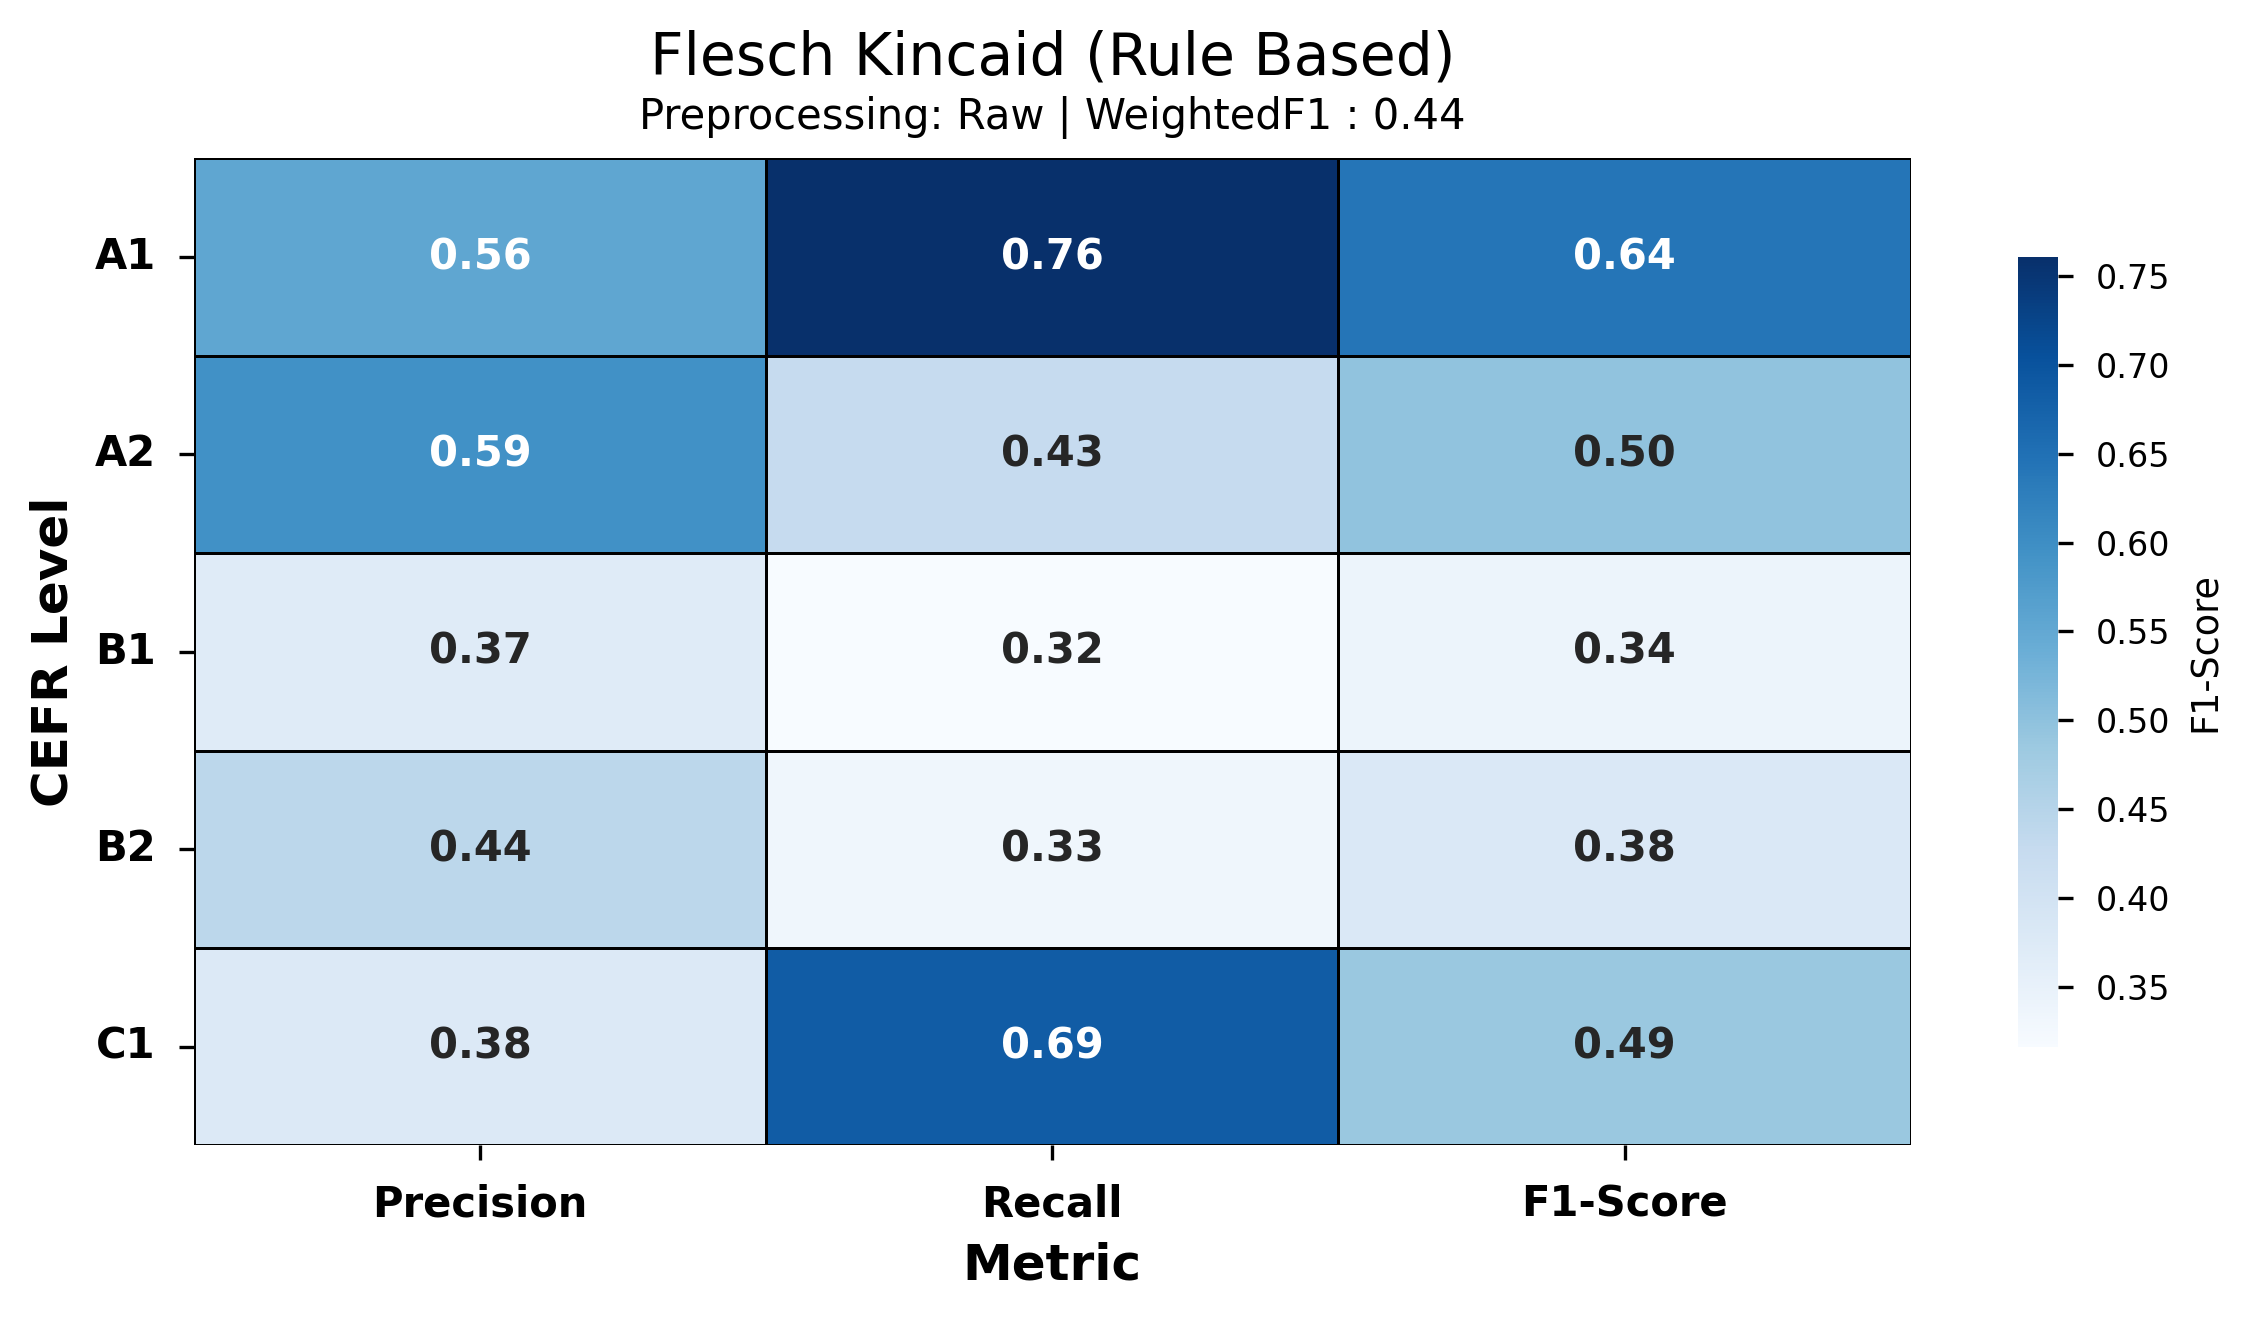

In [17]:
display_report_heatmap(data['generalized']['rule_based']['flesch_kincaid'])

###**Gunning Fog**
Le performance dei due dataset sono per lo più stabili.

####**Dataset *main***

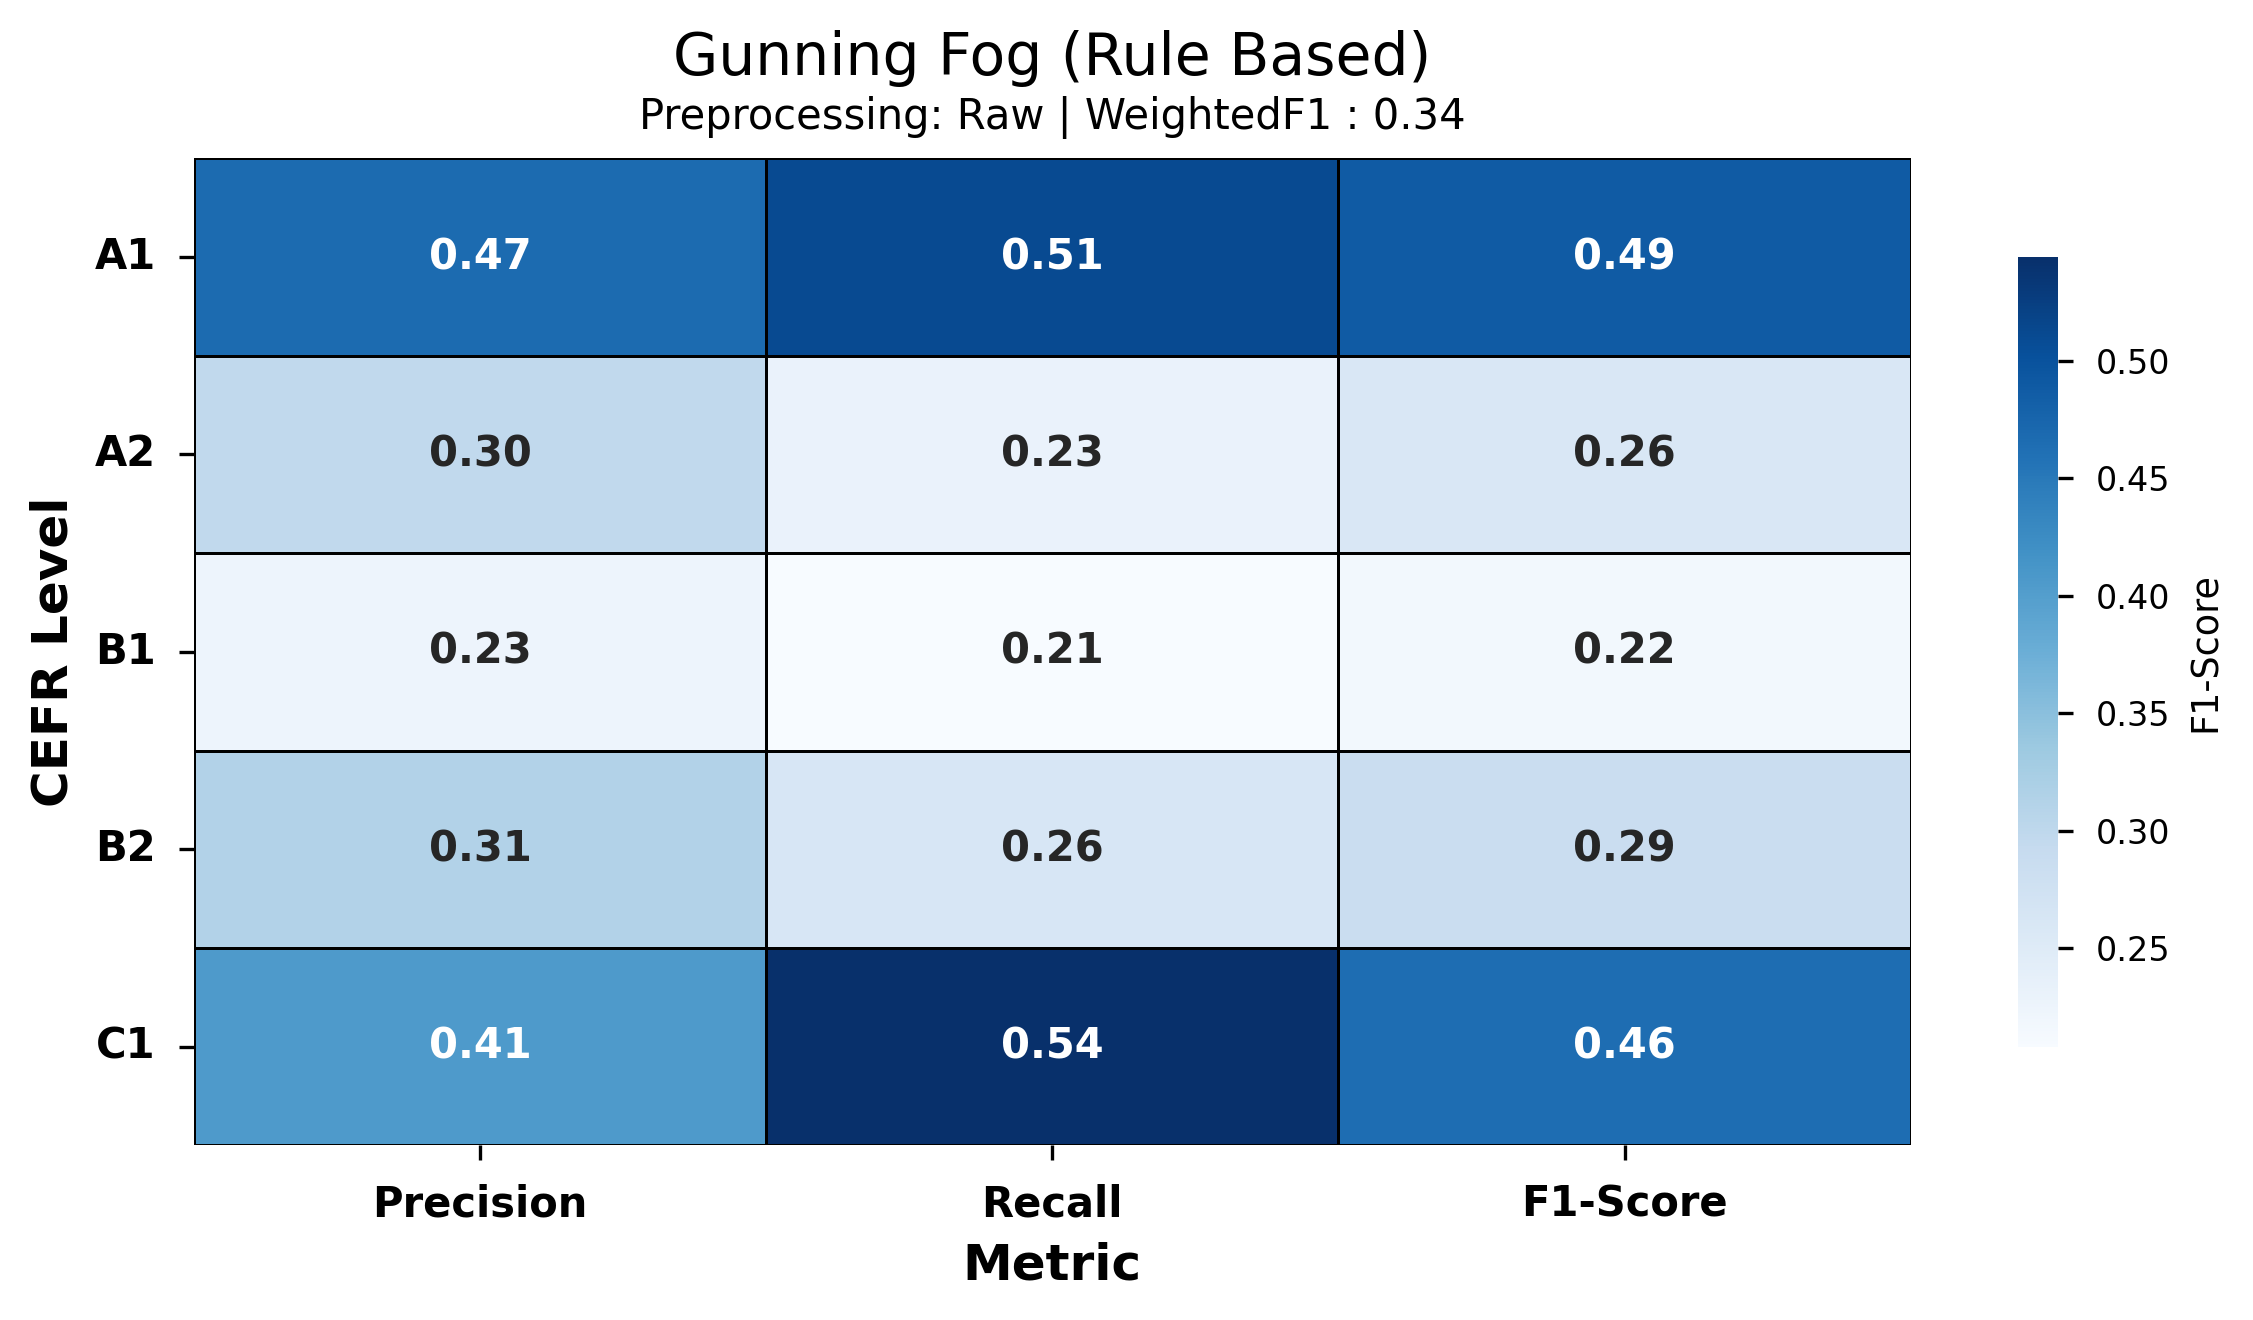

In [18]:
display_report_heatmap(data['main']['rule_based']['gunning_fog'])

####**Dataset *generalizzato***

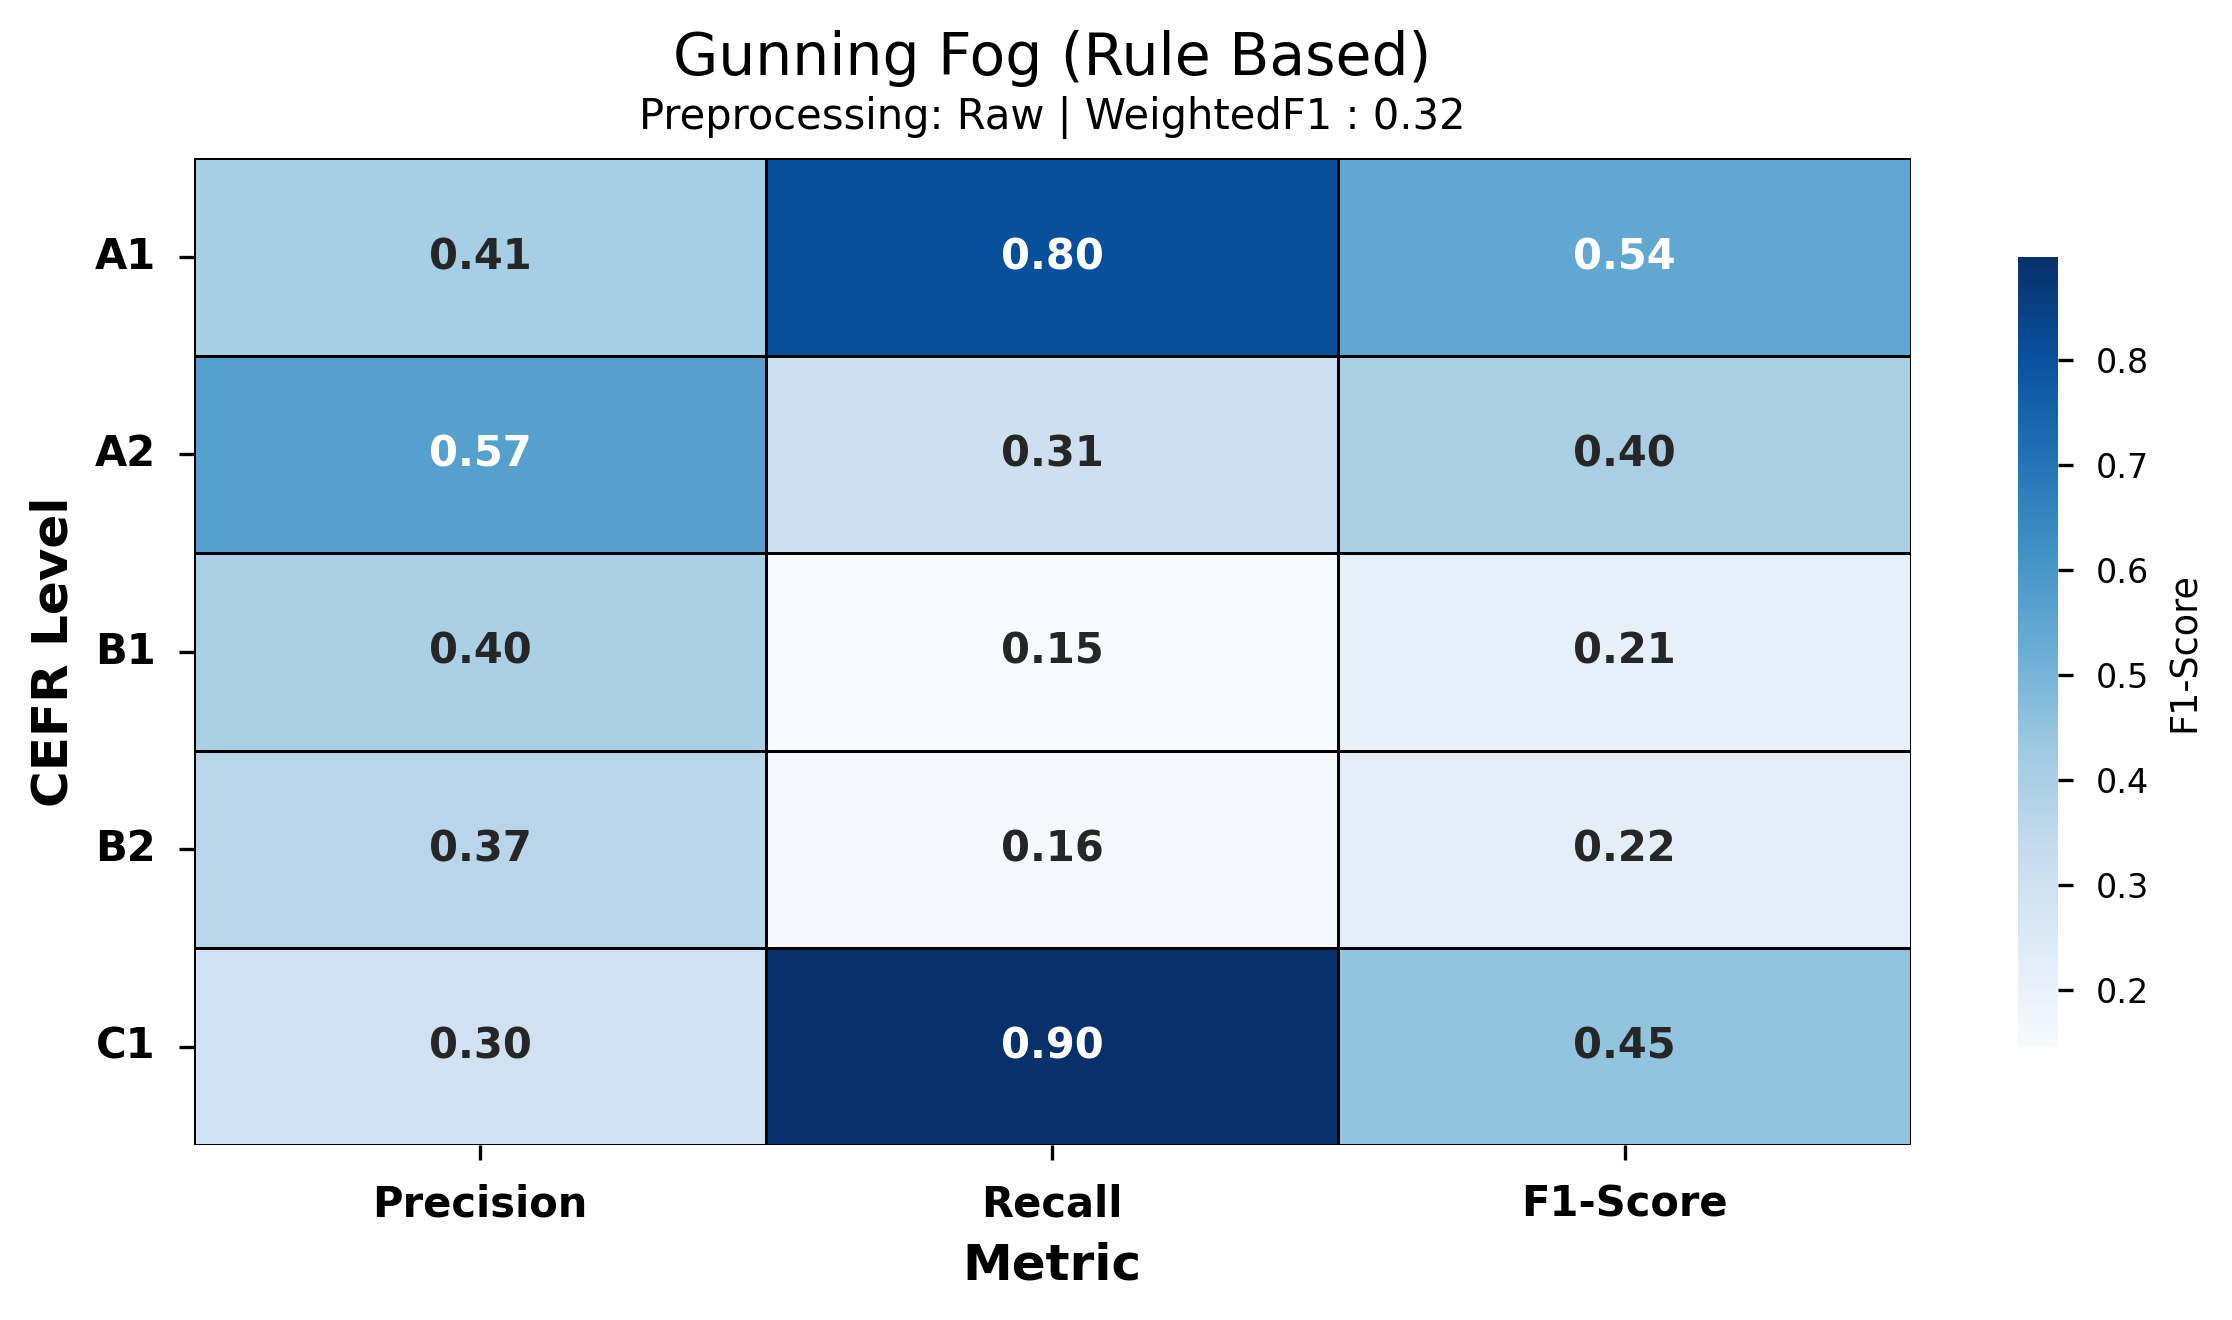

In [19]:
display_report_heatmap(data['generalized']['rule_based']['gunning_fog'])

###**Coleman Liau**
Notiamo due punti interessanti:
1. La performance crolla nel dataset generalizzato ;
2. Tra le 4 formule, Coleman Liau è l'unica a performare meglio con un testo reso minuscolo, senza punteggiatura e senza stopwords: ciò è probabilmente dovuto al fatto che questa formula, basata fondamentalmente sui caratteri, riesce a performare meglio una volta tolto il "noise", cioè quella serie di elementi confondenti come le stopwords o la punteggatura. Inoltre, Coleman Liau "premia" parole con lunghezza maggiore, mentre le stopwords generalemente sono composte da pochi caratteri (*a, the, of, and, ...*).

####**Dataset *main***

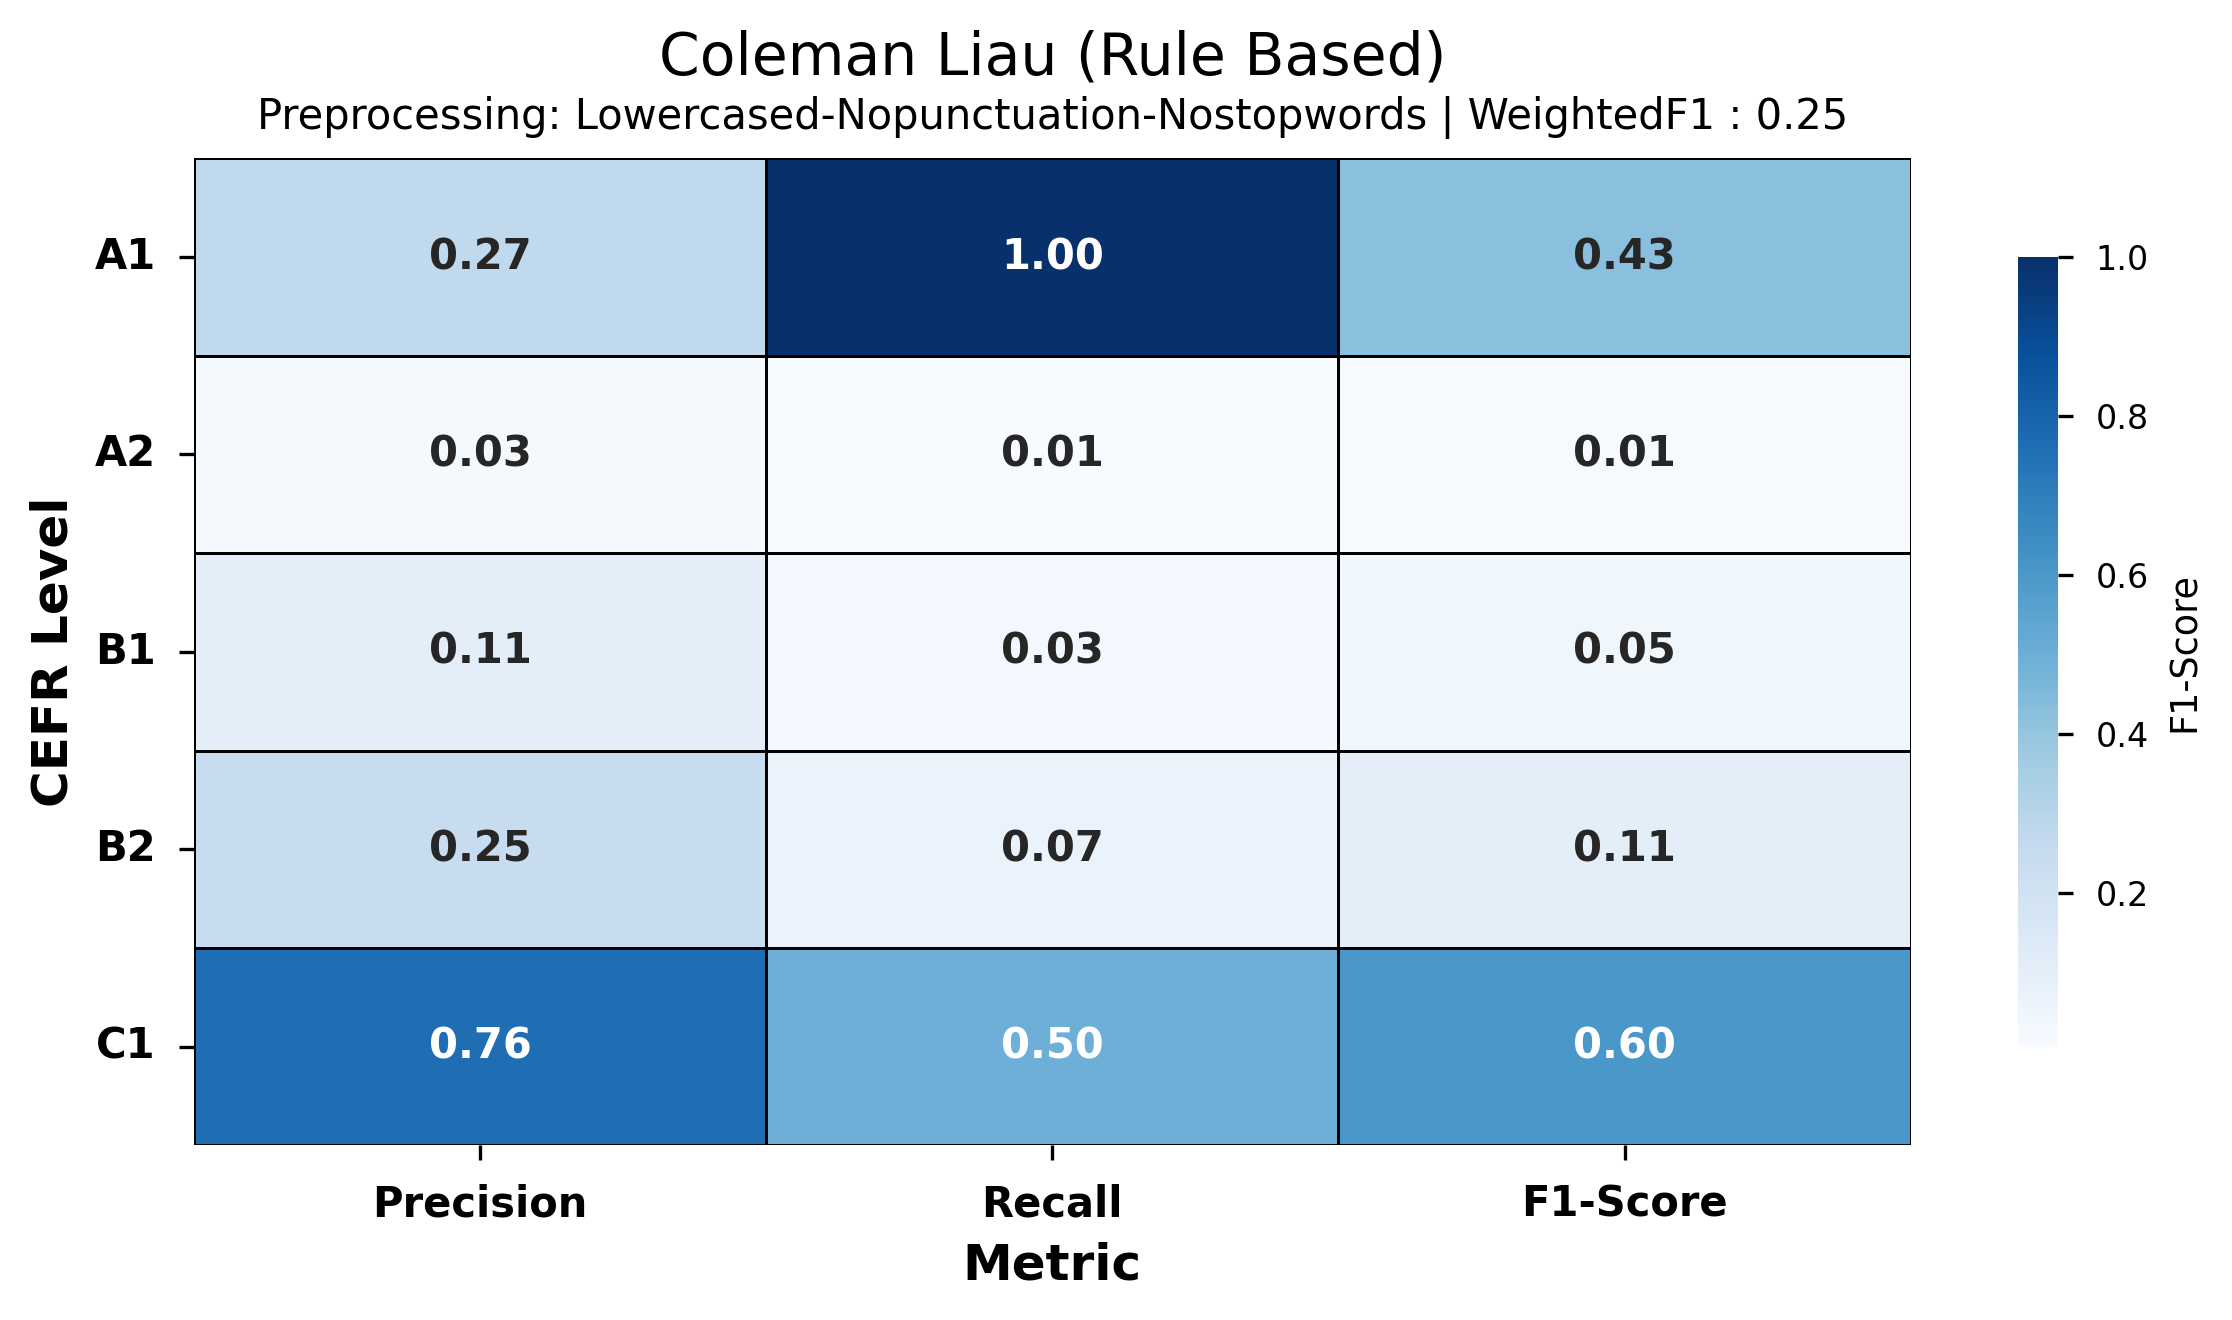

In [20]:
display_report_heatmap(data['main']['rule_based']['coleman_liau'])

####**Dataset *generalizzato***

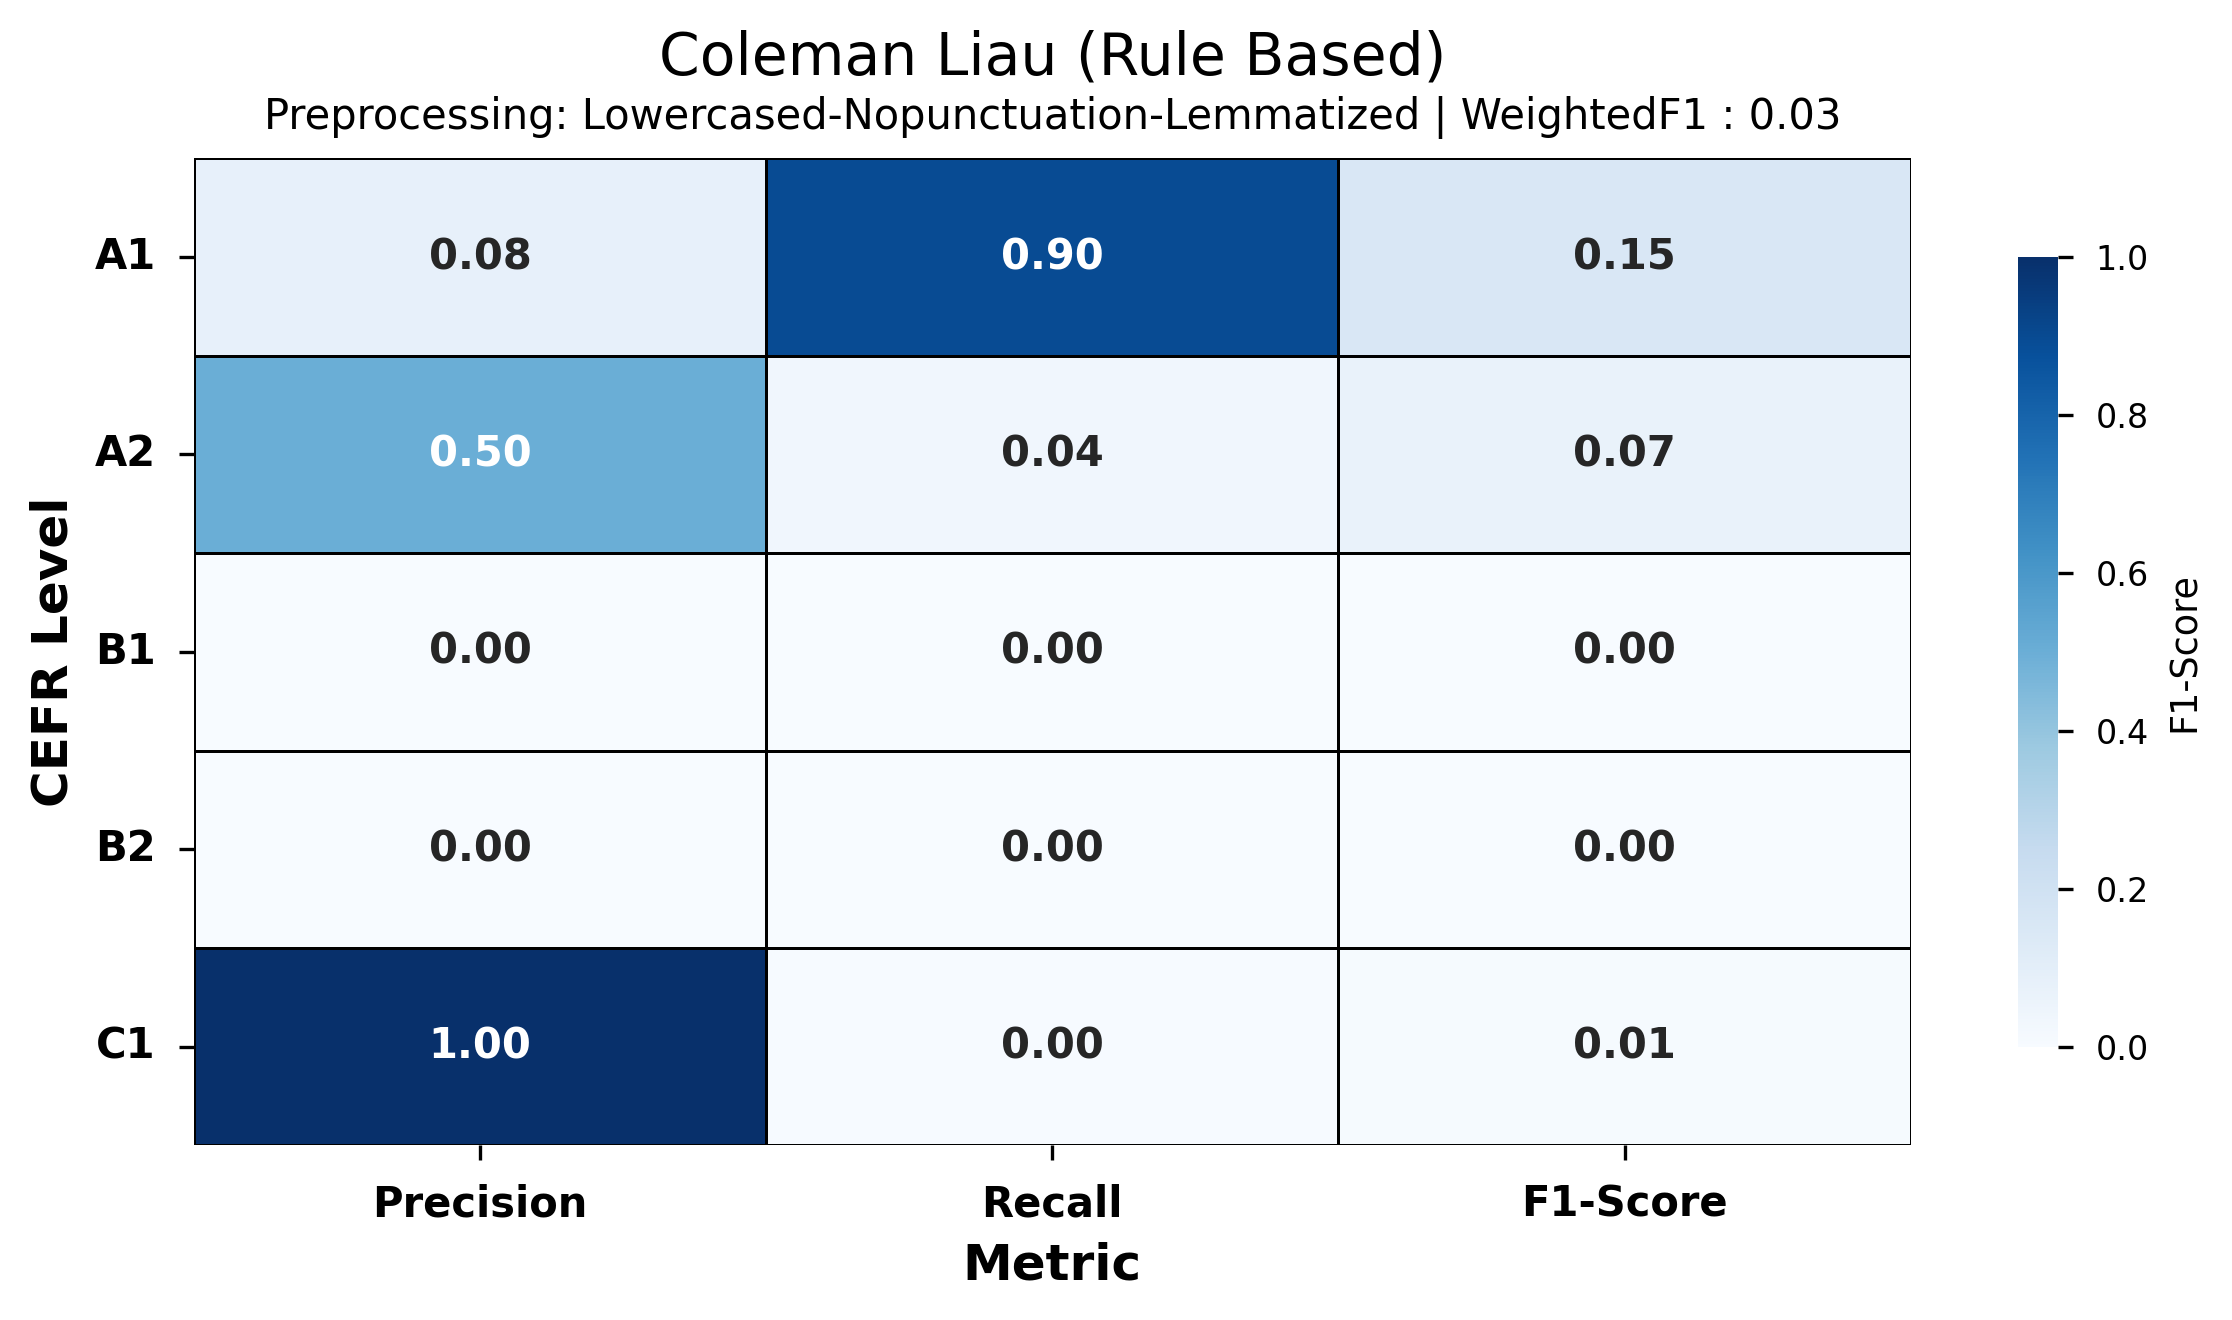

In [21]:
display_report_heatmap(data['generalized']['rule_based']['coleman_liau'])

###**Automated Readability Index**
Non c'è troppa differenza tra i due dataset:

####**Dataset *main***

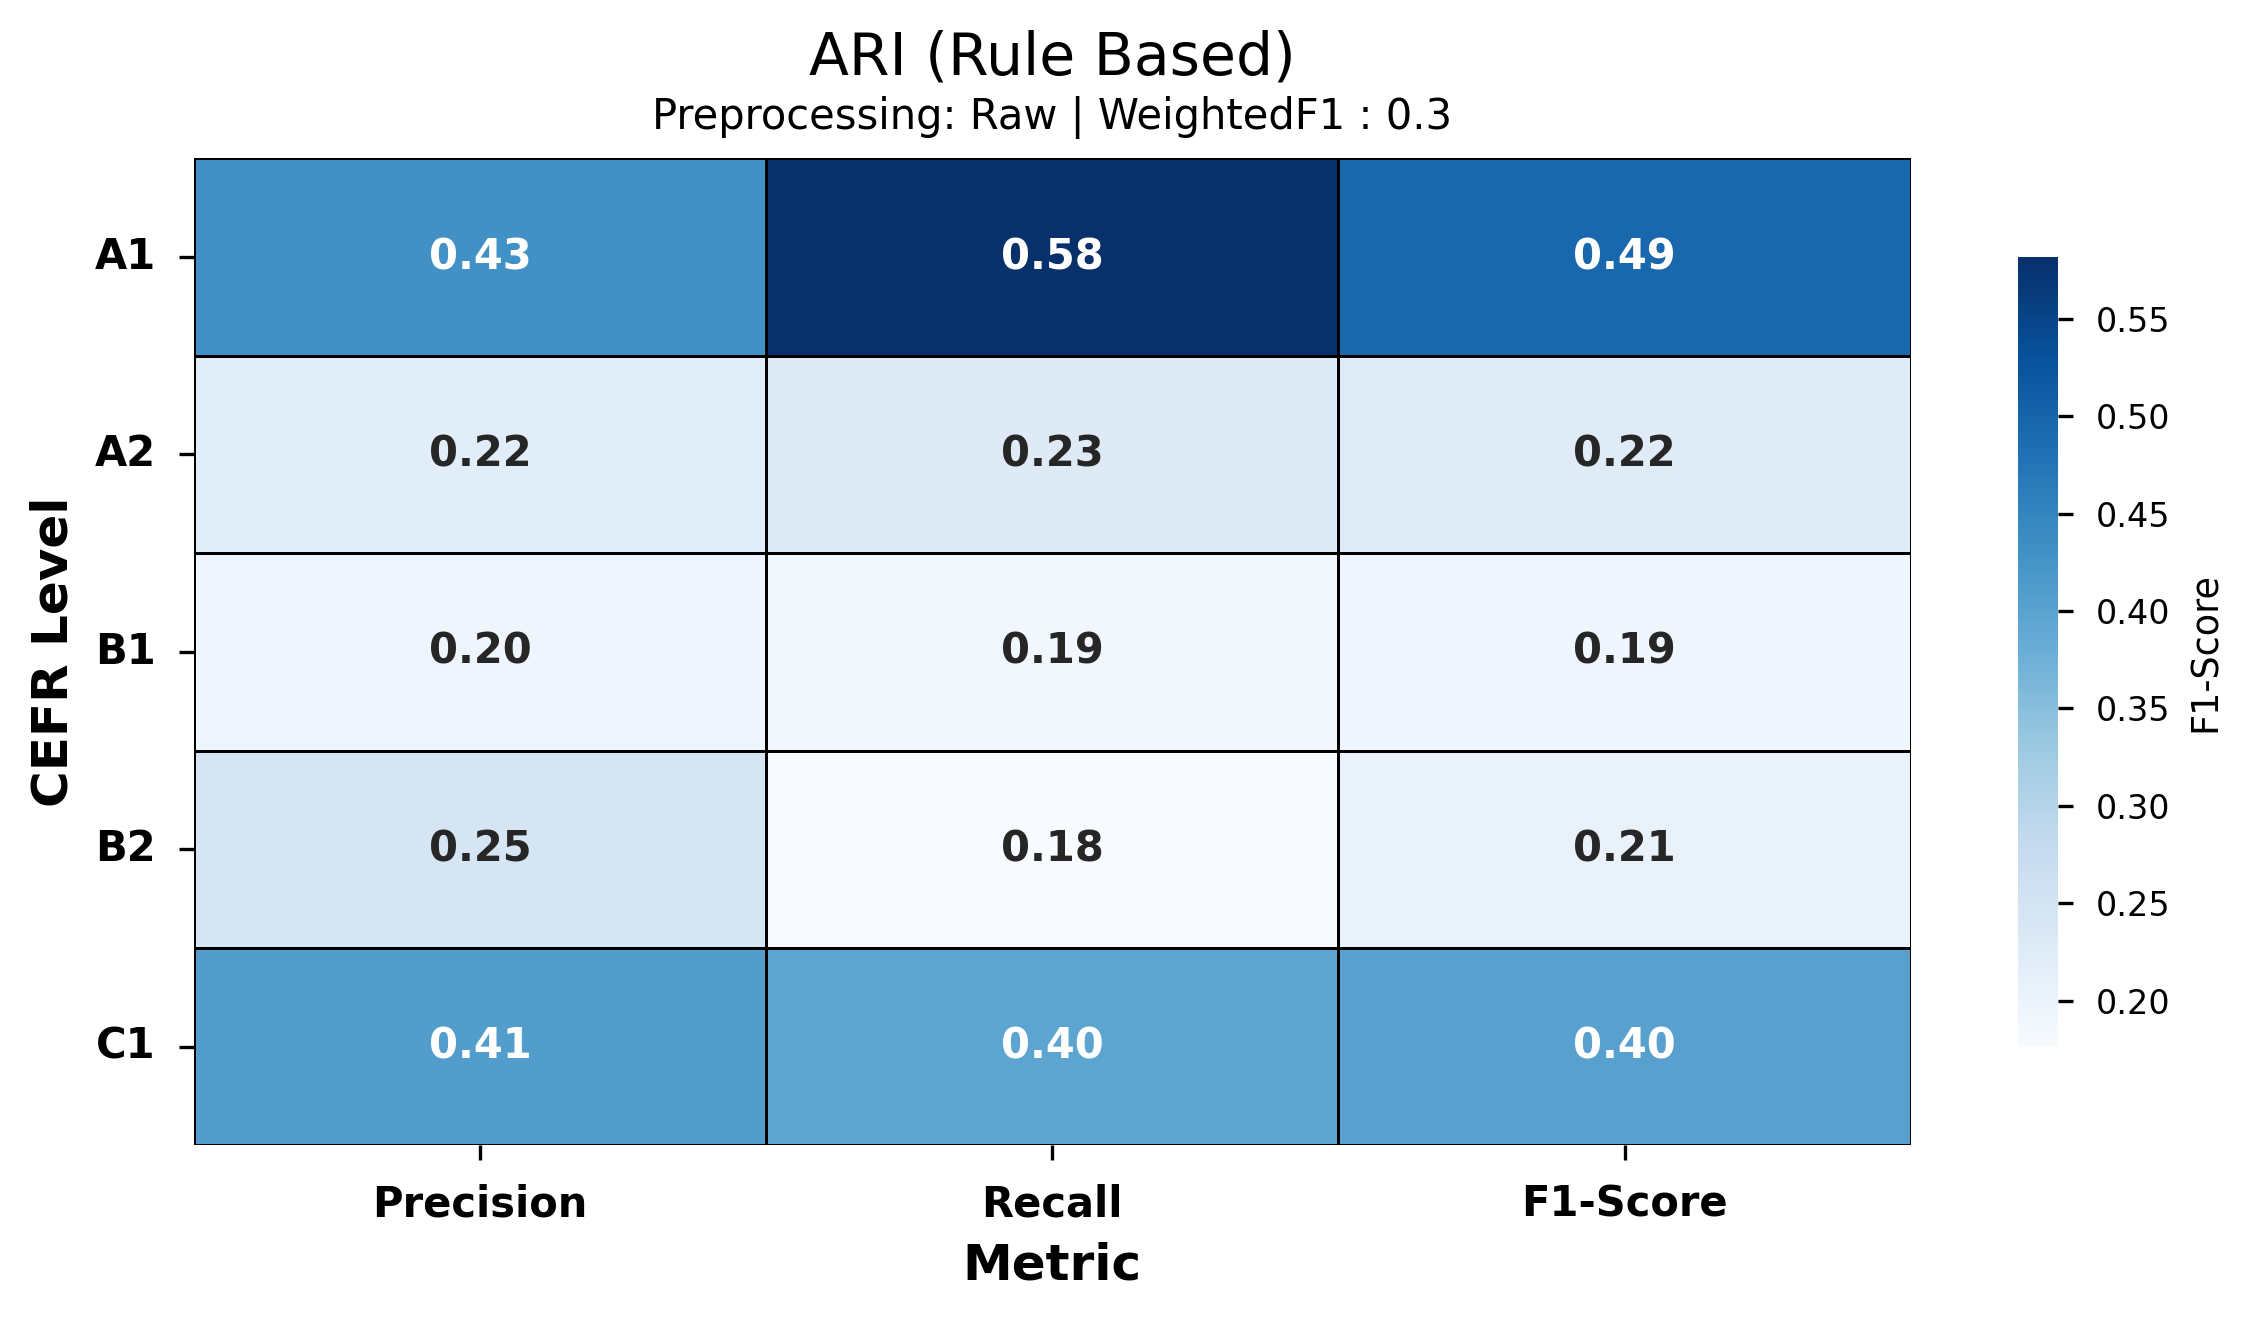

In [22]:
display_report_heatmap(data['main']['rule_based']['ARI'])

####**Dataset *generalizzato***

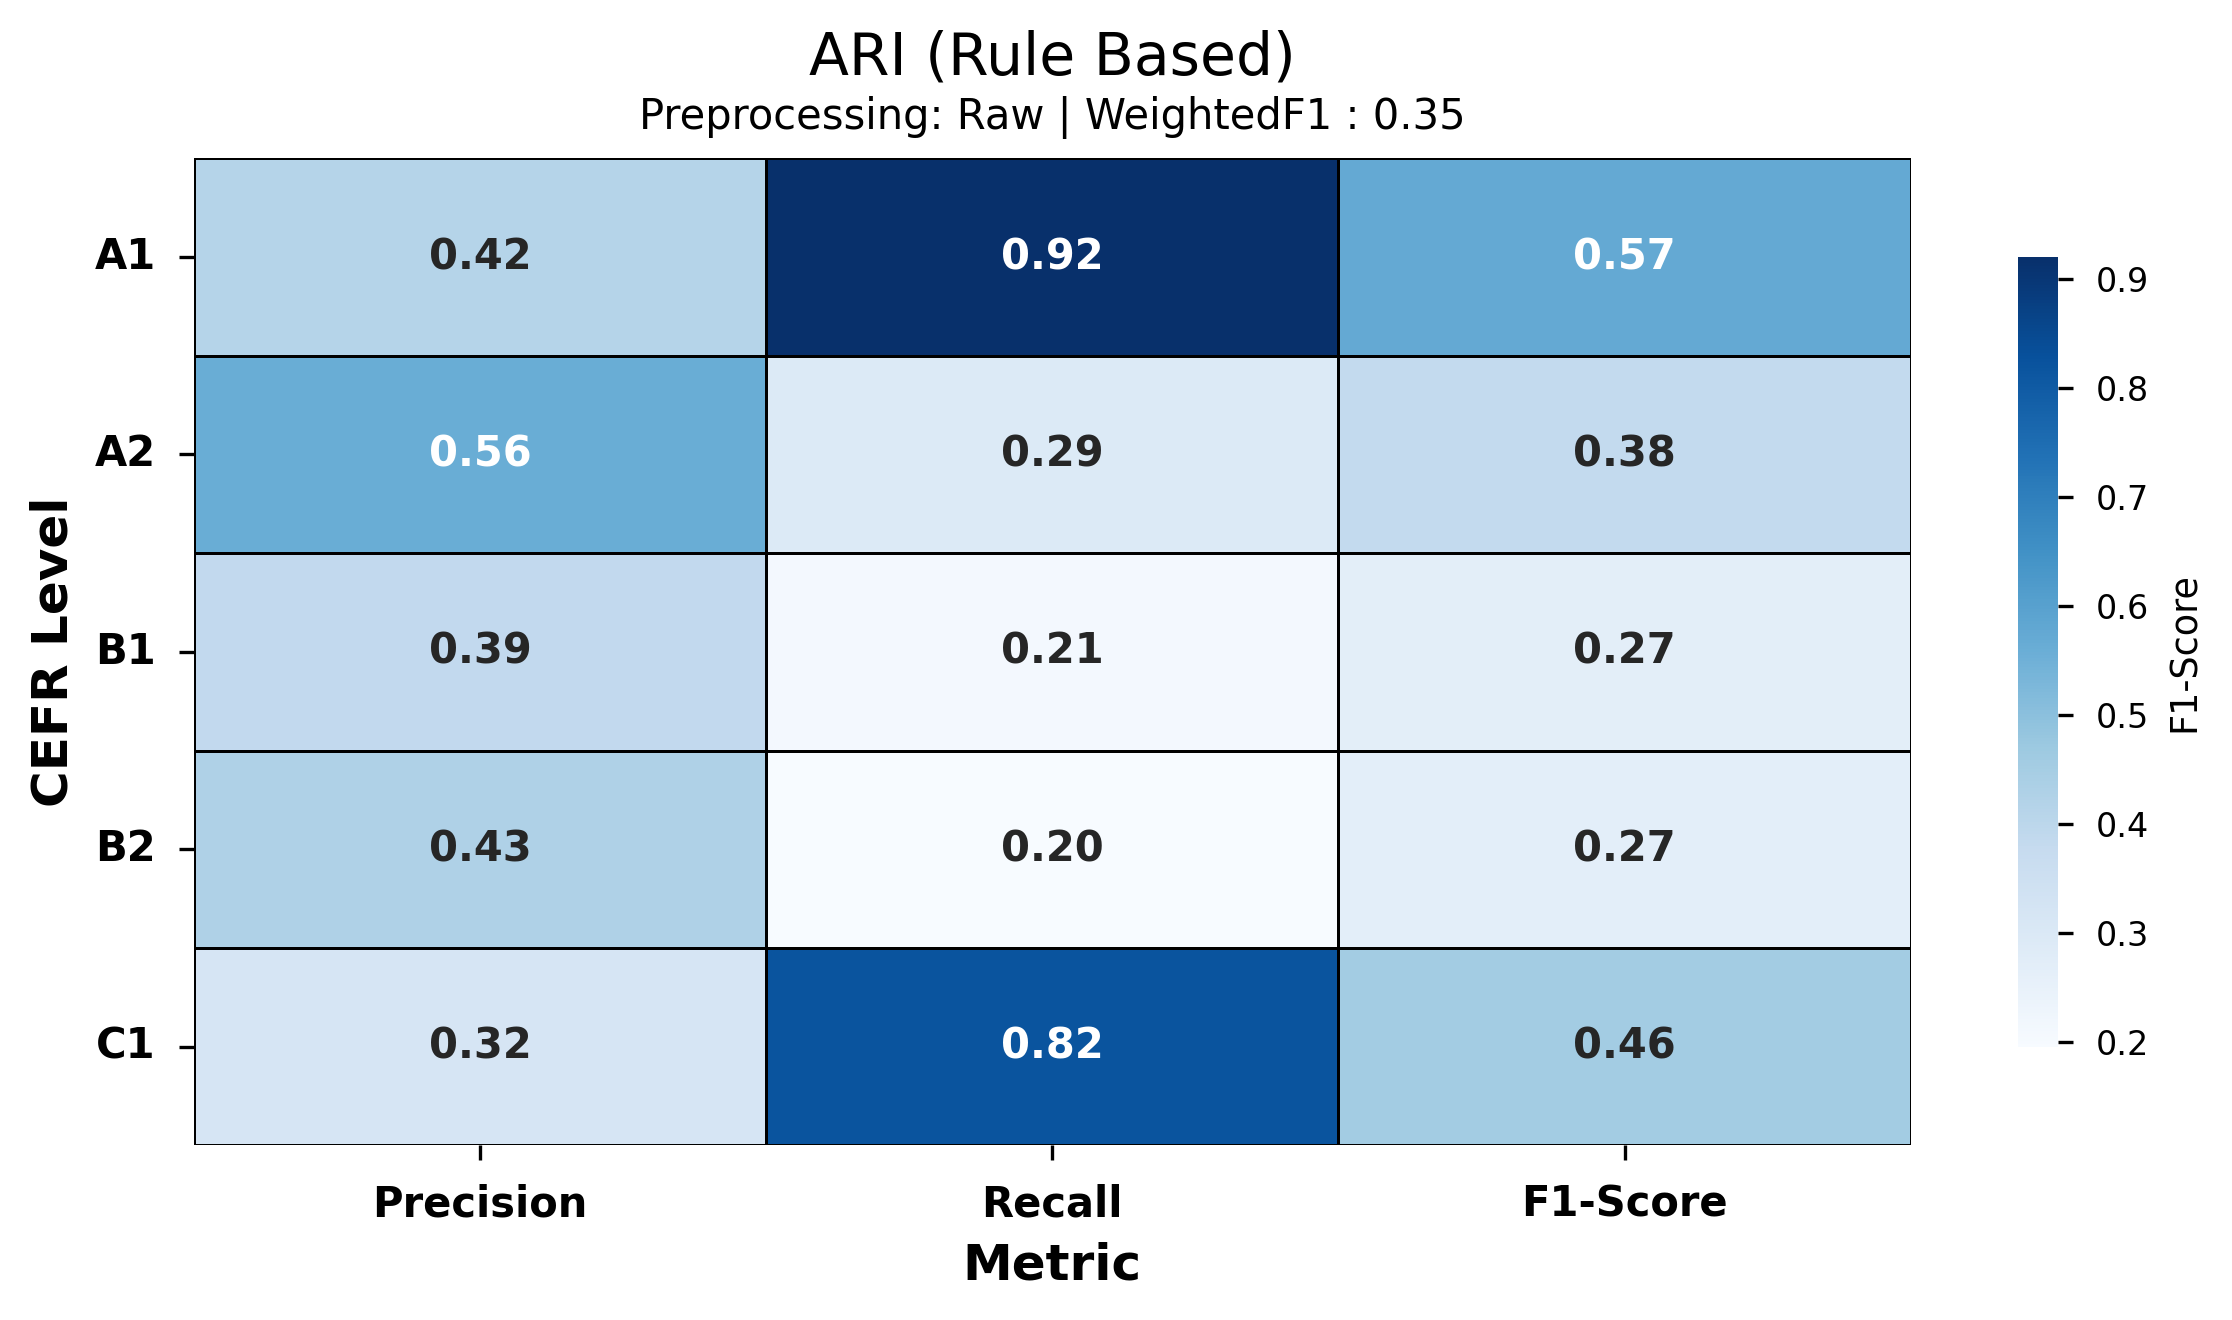

In [23]:
display_report_heatmap(data['generalized']['rule_based']['ARI'])

###**Paragone dei vari metodi Rule-Based**

####**Dataset main**
Il miglior metodo sul dataset *main* è l'estrazione dei pesi delle parole. Nonostante ciò, è importante sottolineare due punti fondamentali:
1. Questo metodo dipende fortemente dal dataset di "training": se una parola non appare in quel dataset, allora verrà esclusa se trovata in un testo da predire quando il modello viene testato;
2. Il modello è troppo legato alla sola dimensione lessicale di un testo. Ricordiamo come il livello CEFR di un testo sia composto non solo dal lessico utilizzato, ma anche dalla sintassi che lega le parole tra loro.

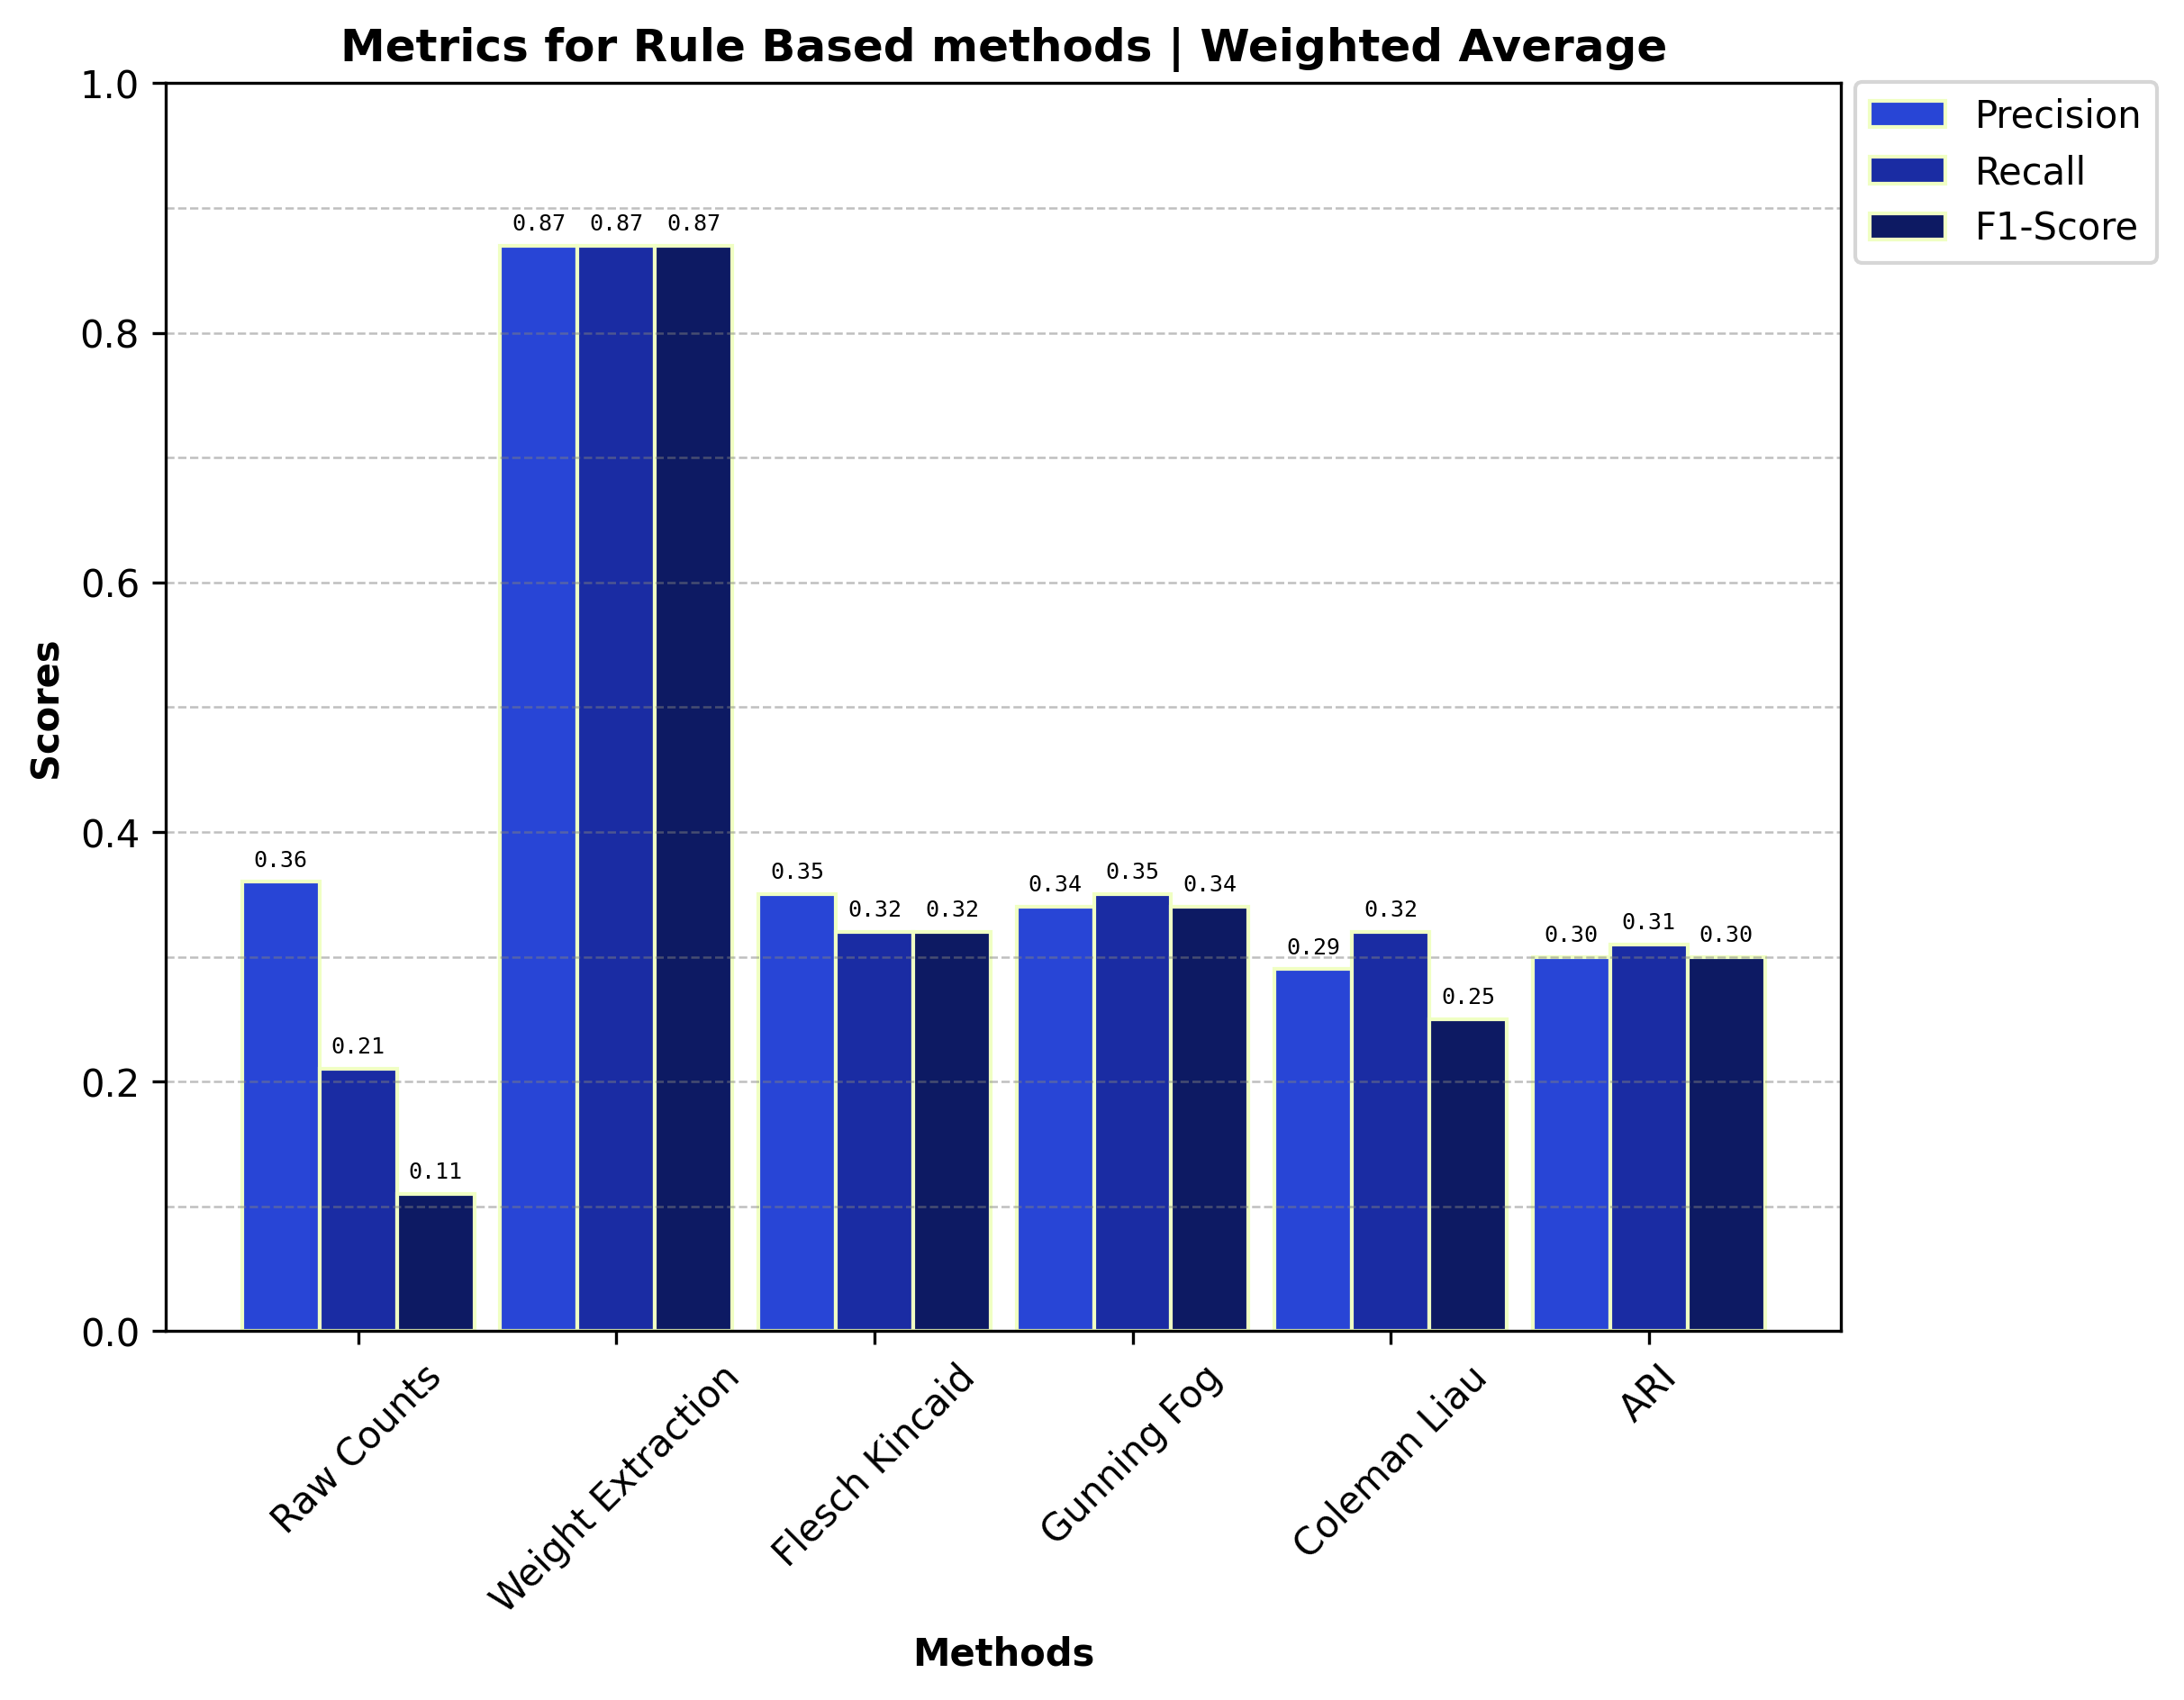

In [24]:
display_approach_barplot(data['main']['rule_based'])

####**Dataset generalizzato**
Facendo riferimento alla cella precedente, notiamo infatti come il metodo perde molti punti se testato su un dataset diverso. A parte *Coleman Liau*, gli altri metodi sono per lo più stabili, probabilmente perché non dipendono dal dataset di training.

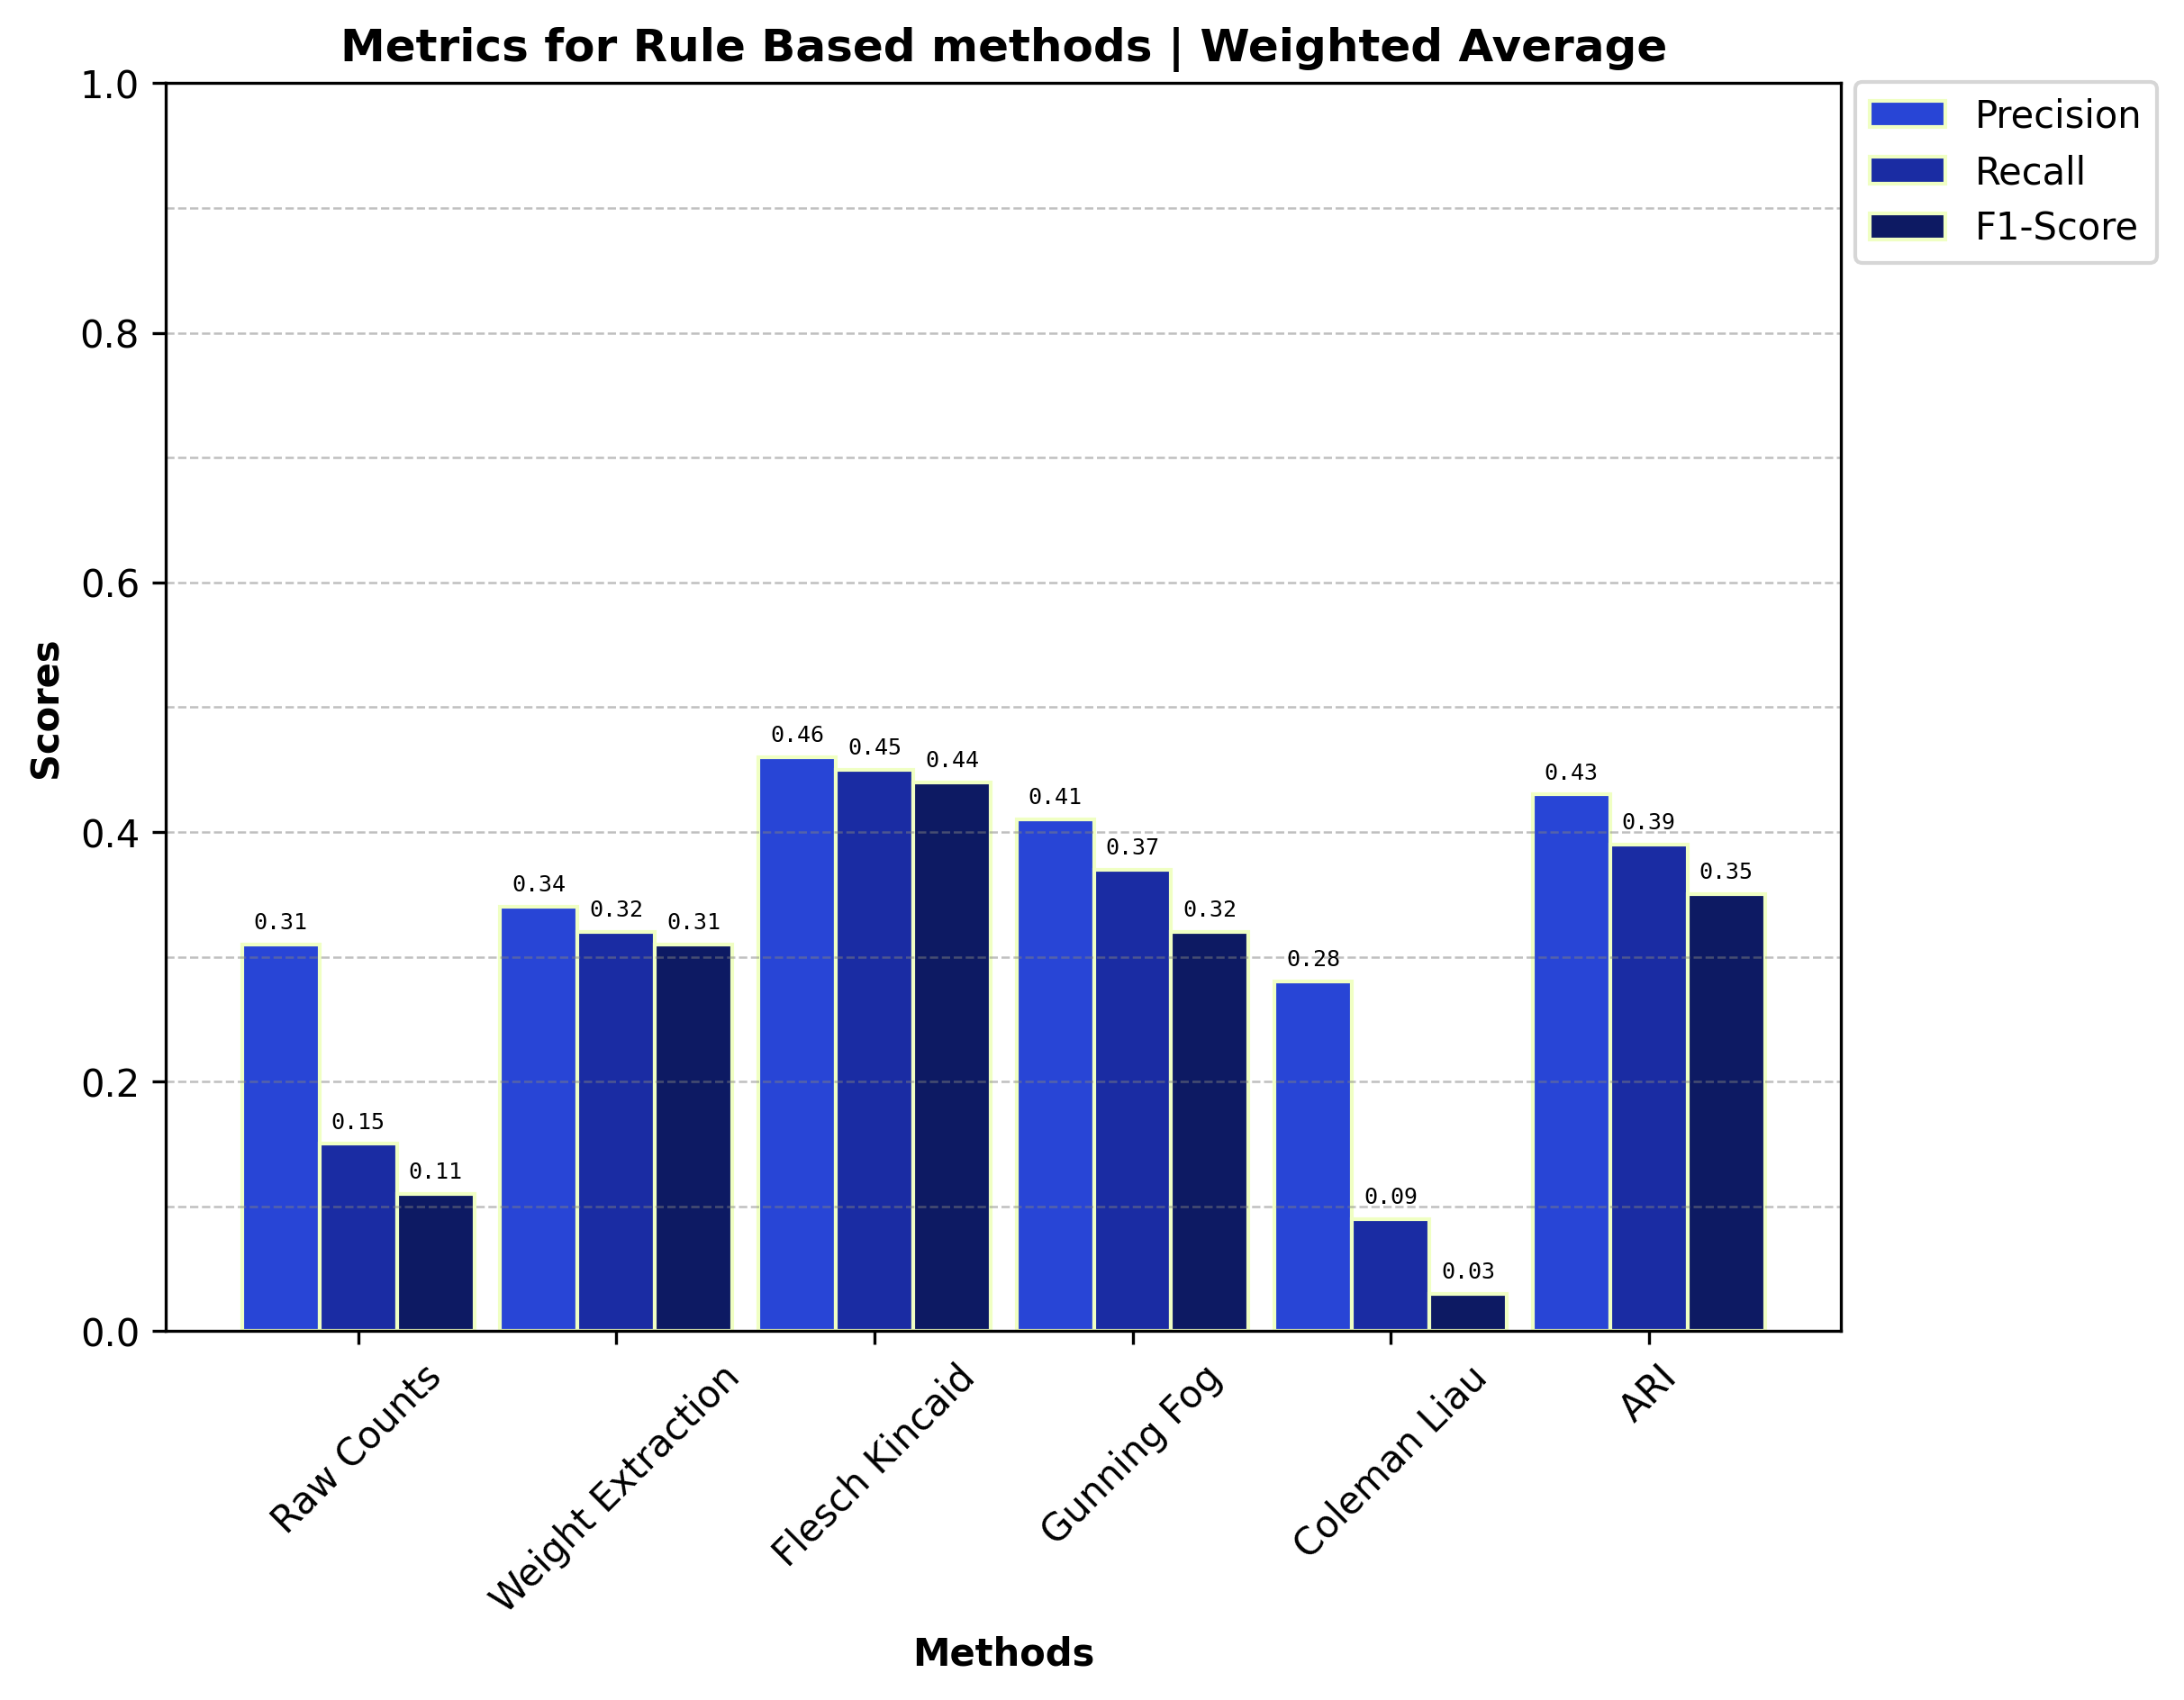

In [25]:
display_approach_barplot(data['generalized']['rule_based'])

##**Machine Learning: migliore *Weighted F1-Score***
Tutti questi metodi sono basati sul training tramite un dataset e, nonostante le performance nettamente superiori, mostrano forte dipendenza da esso:
1. I tre modelli "tradizionali" (RF, LR e GB) sono stati allenati tramite delle features lessicali, morfologiche (ex. numero di verbi al *past simple*), sintattiche (ex. numero di proposizioni subordinate);
2. Fasttext è stato allenato tramite il self-supervised learning (estrazione automatica di features).

###**Random Forest**
Come nei metodi precedenti, troviamo sempre più facilità a riconoscere le classi agli estremi:

####**Dataset MAIN**

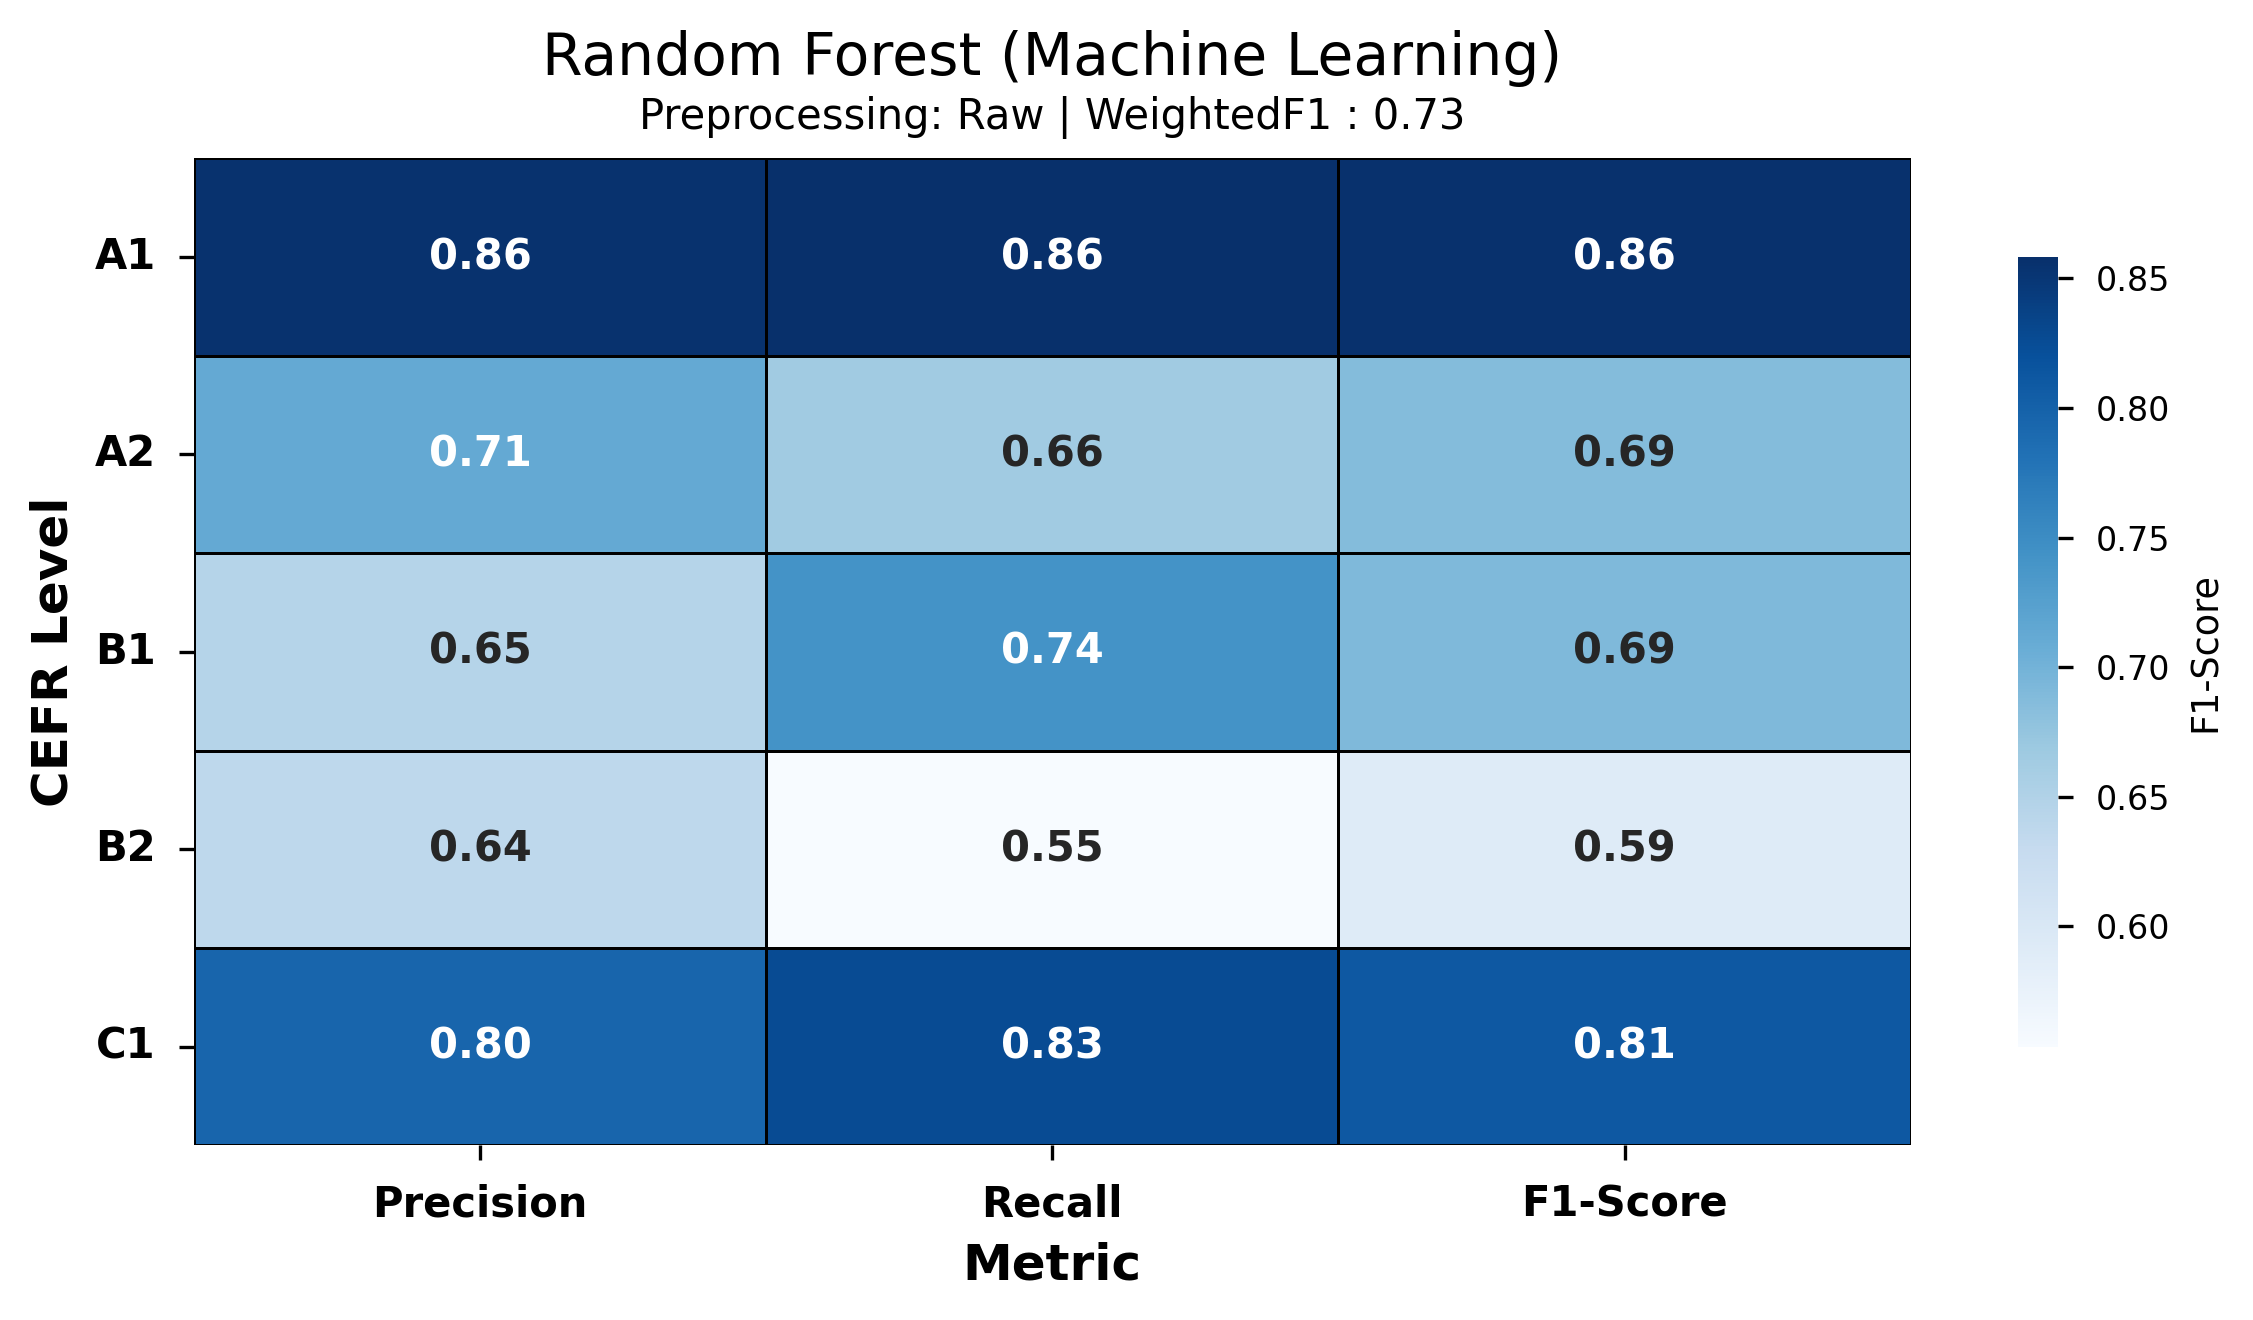

In [26]:
display_report_heatmap(data['main']['machine_learning']['random_forest'])

####**Dataset GENERALIZED**
Anche qui la performance crolla, dato che il modello è molto legato al dataset di training:

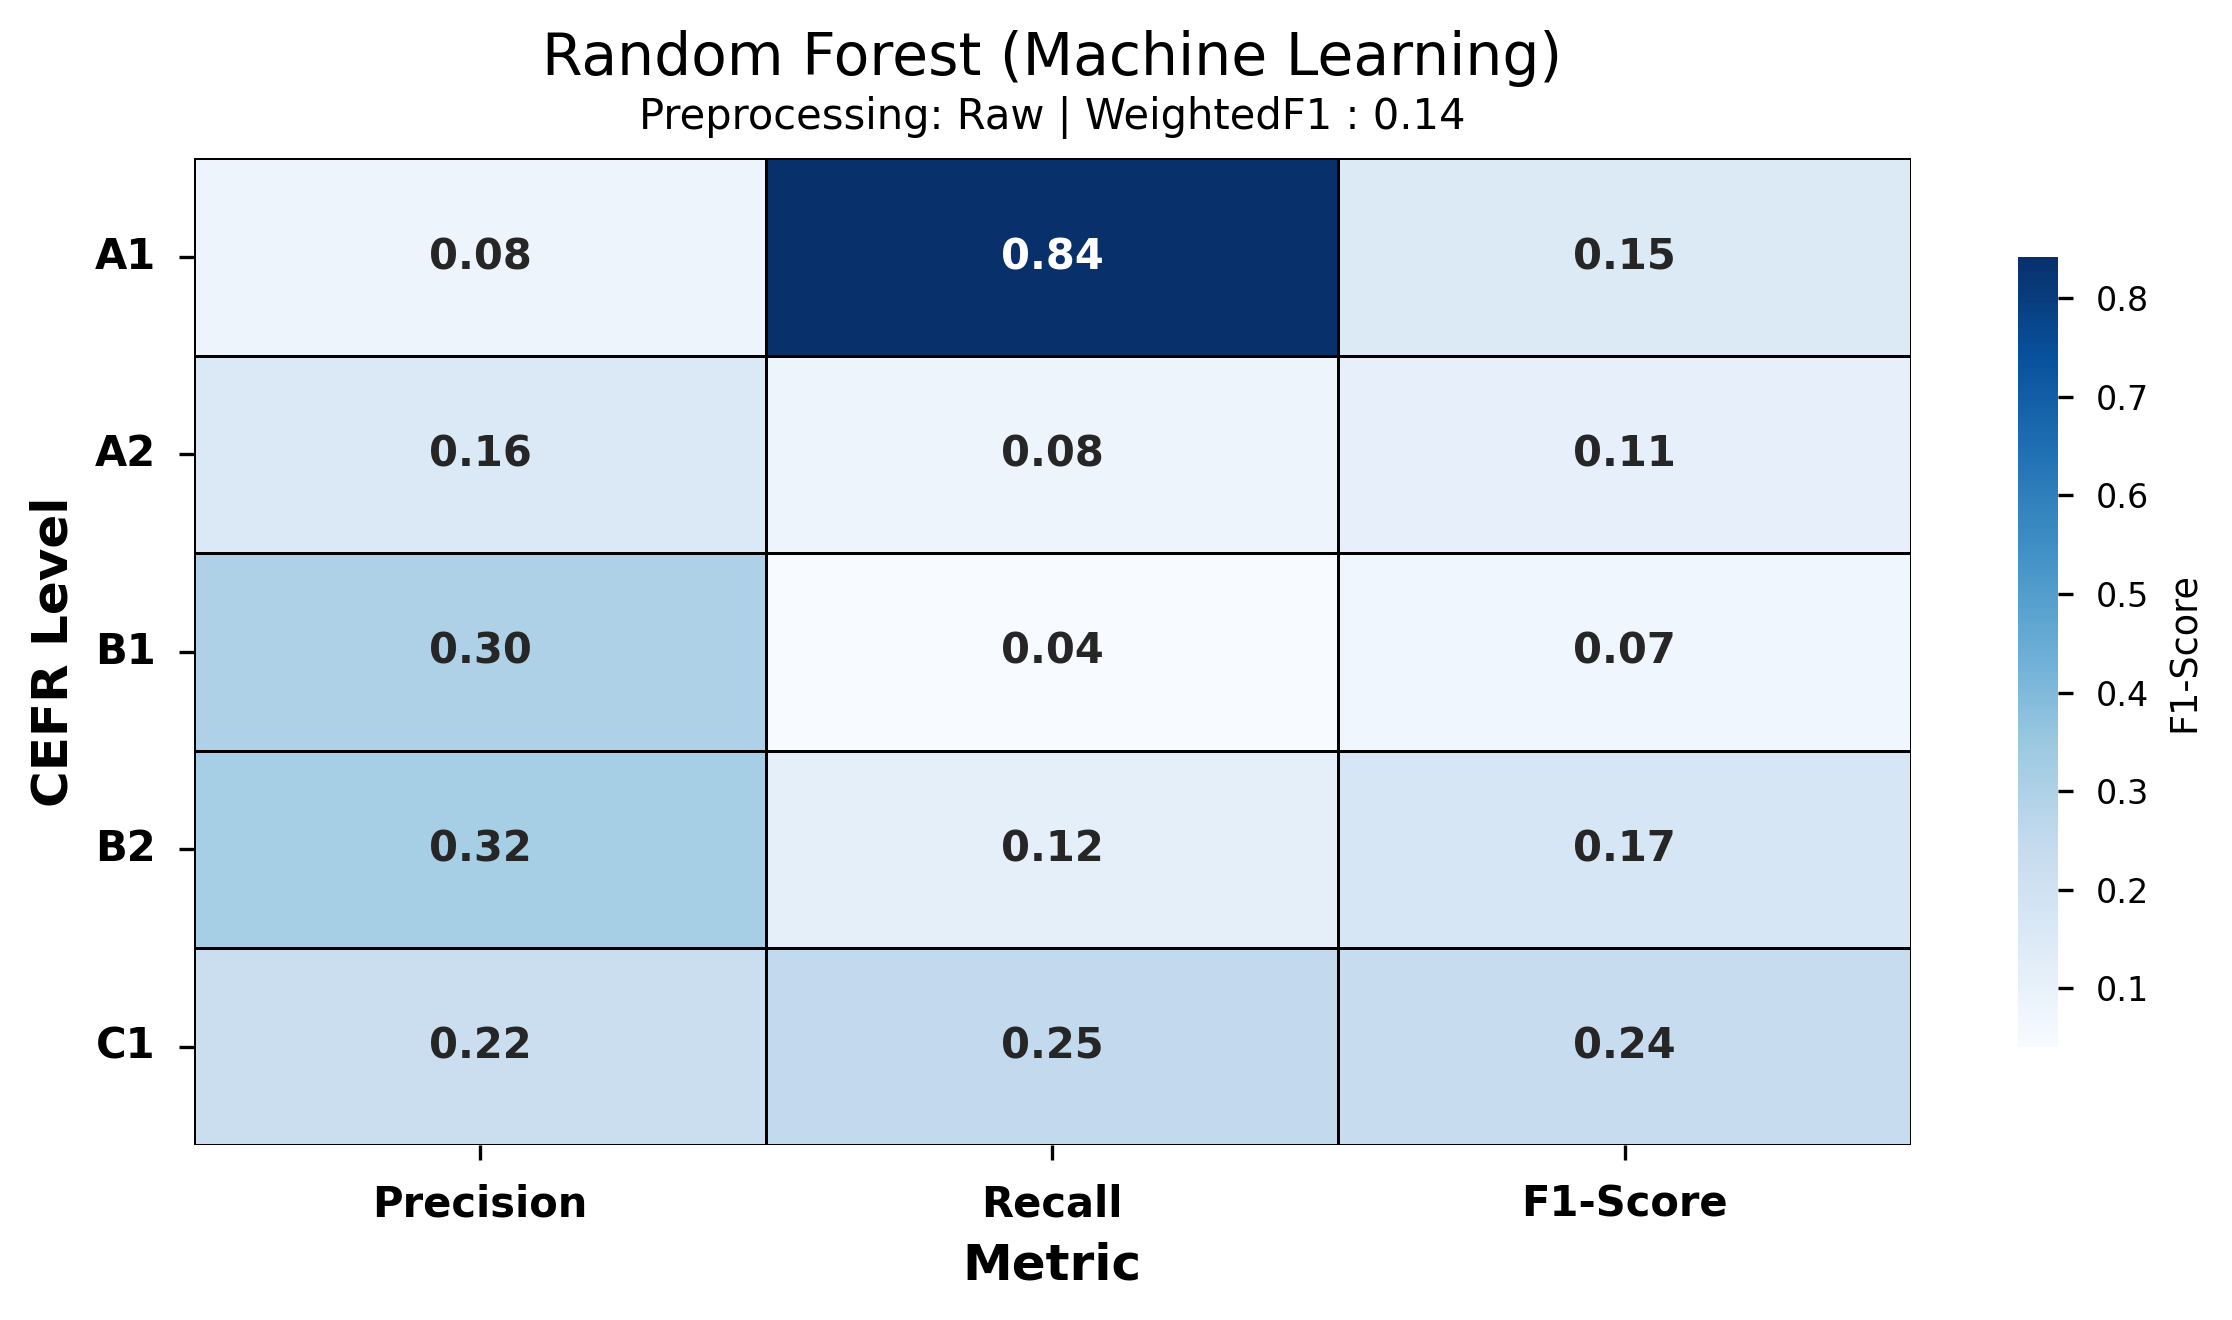

In [27]:
display_report_heatmap(data['generalized']['machine_learning']['random_forest'])

###**Logistic Regression**

####**Dataset MAIN**
Risultati molto simili al modello Random Forest, anche se notiamo come l'F1 Score di A1 e C1 abbia una differenza leggermente più marcata nei confronti di A2, B1 e B2 rispetto al modello precedente:

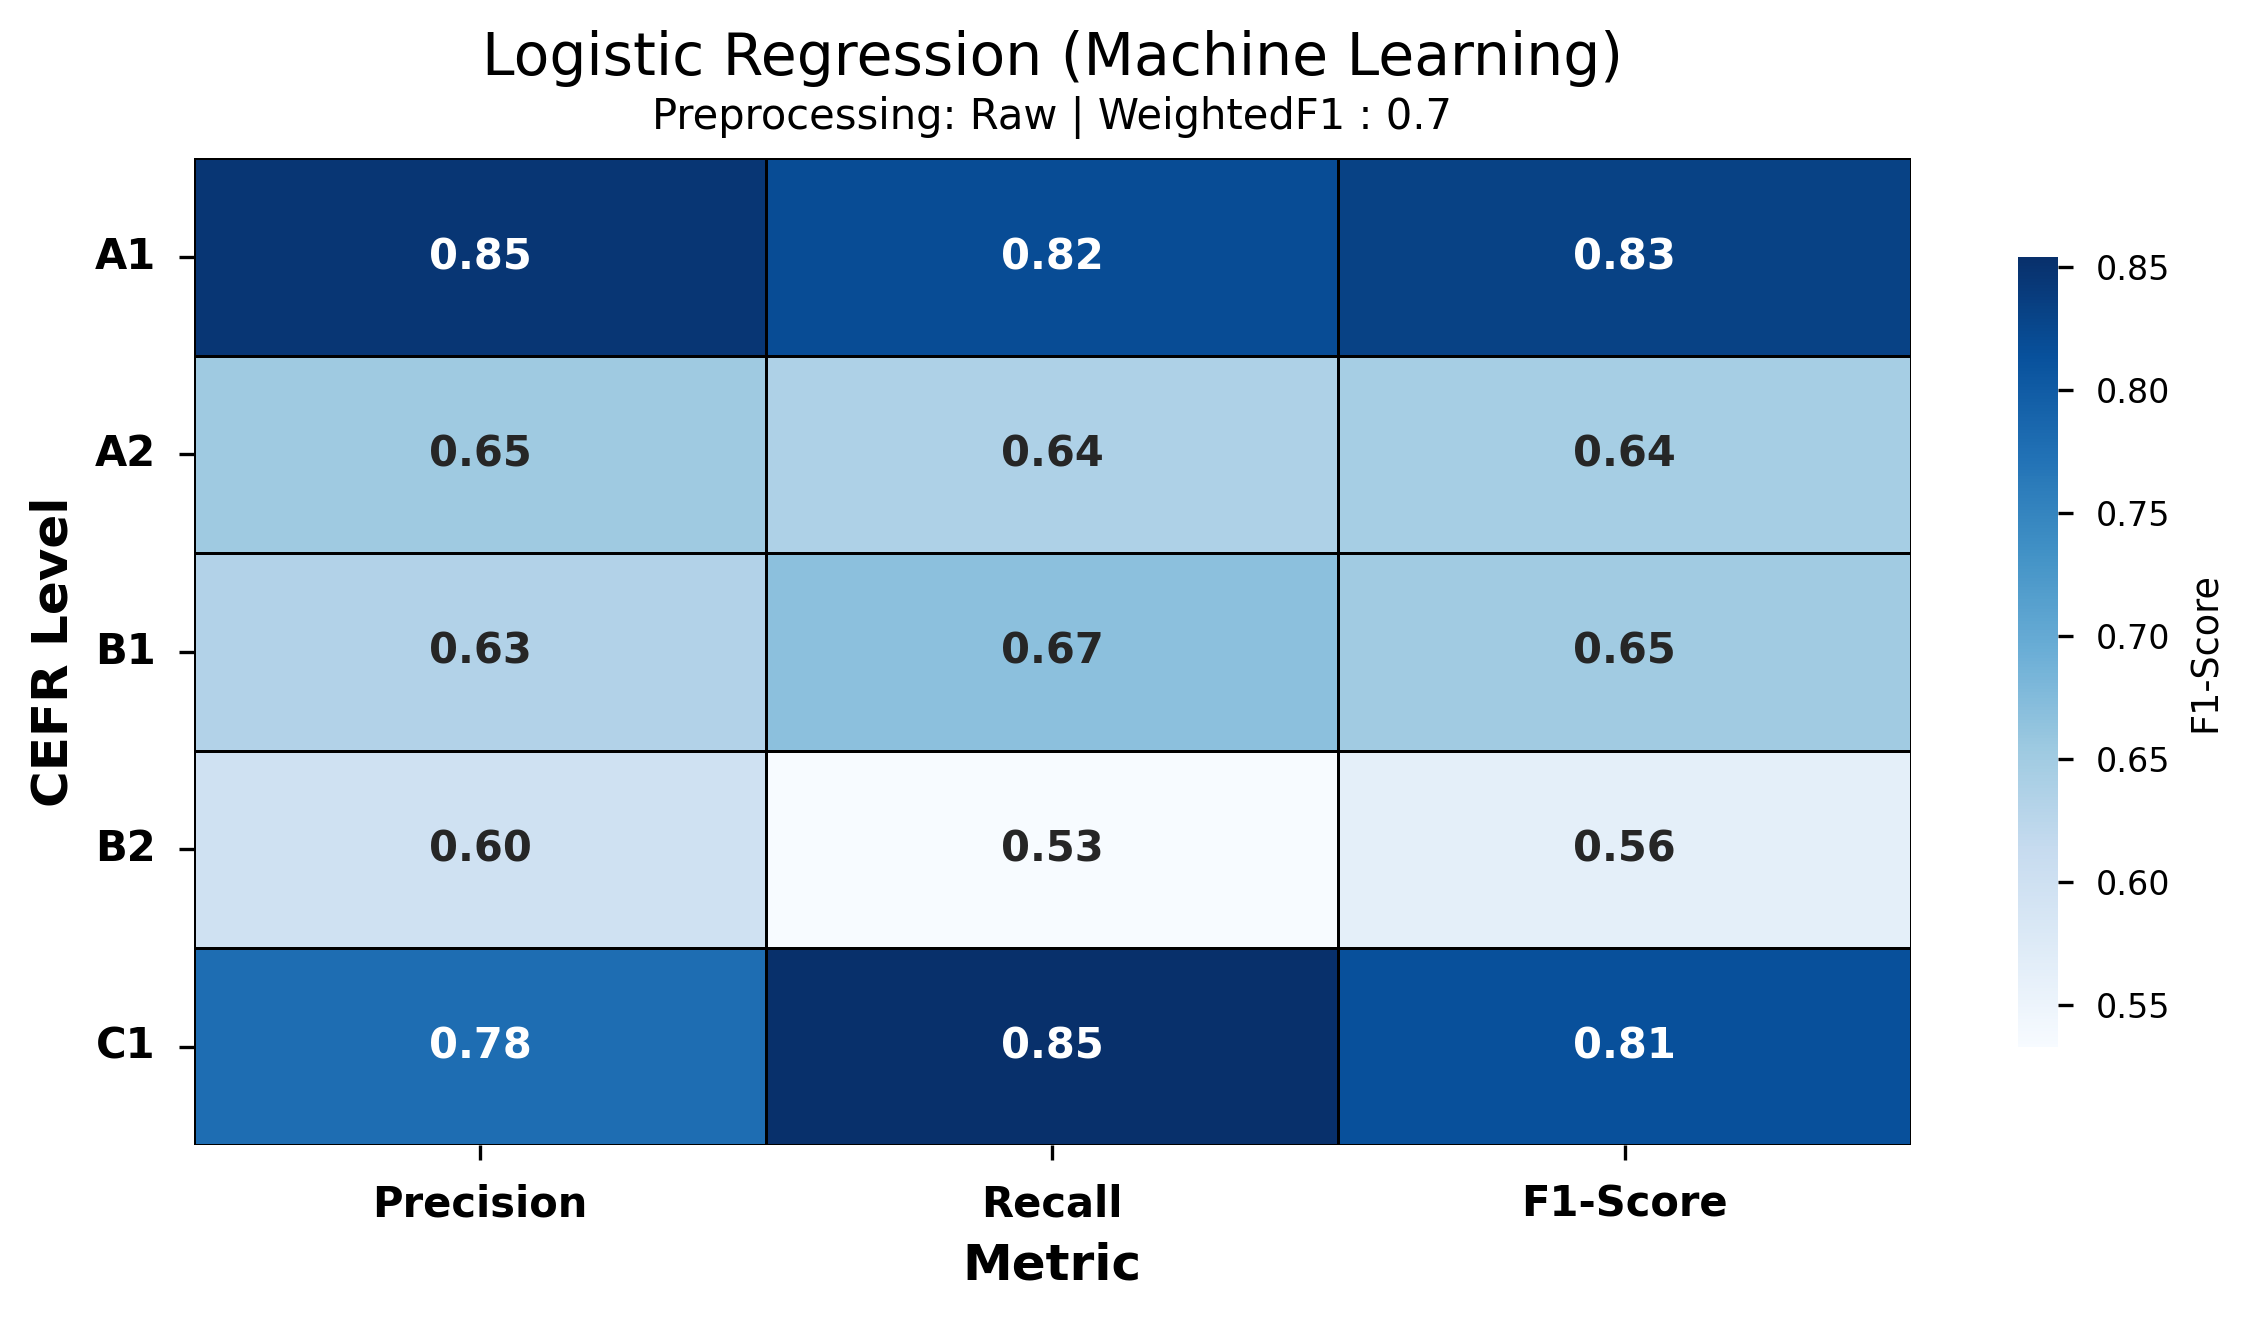

In [28]:
display_report_heatmap(data['main']['machine_learning']['logistic_regression'])

####**Dataset GENERALIZED**

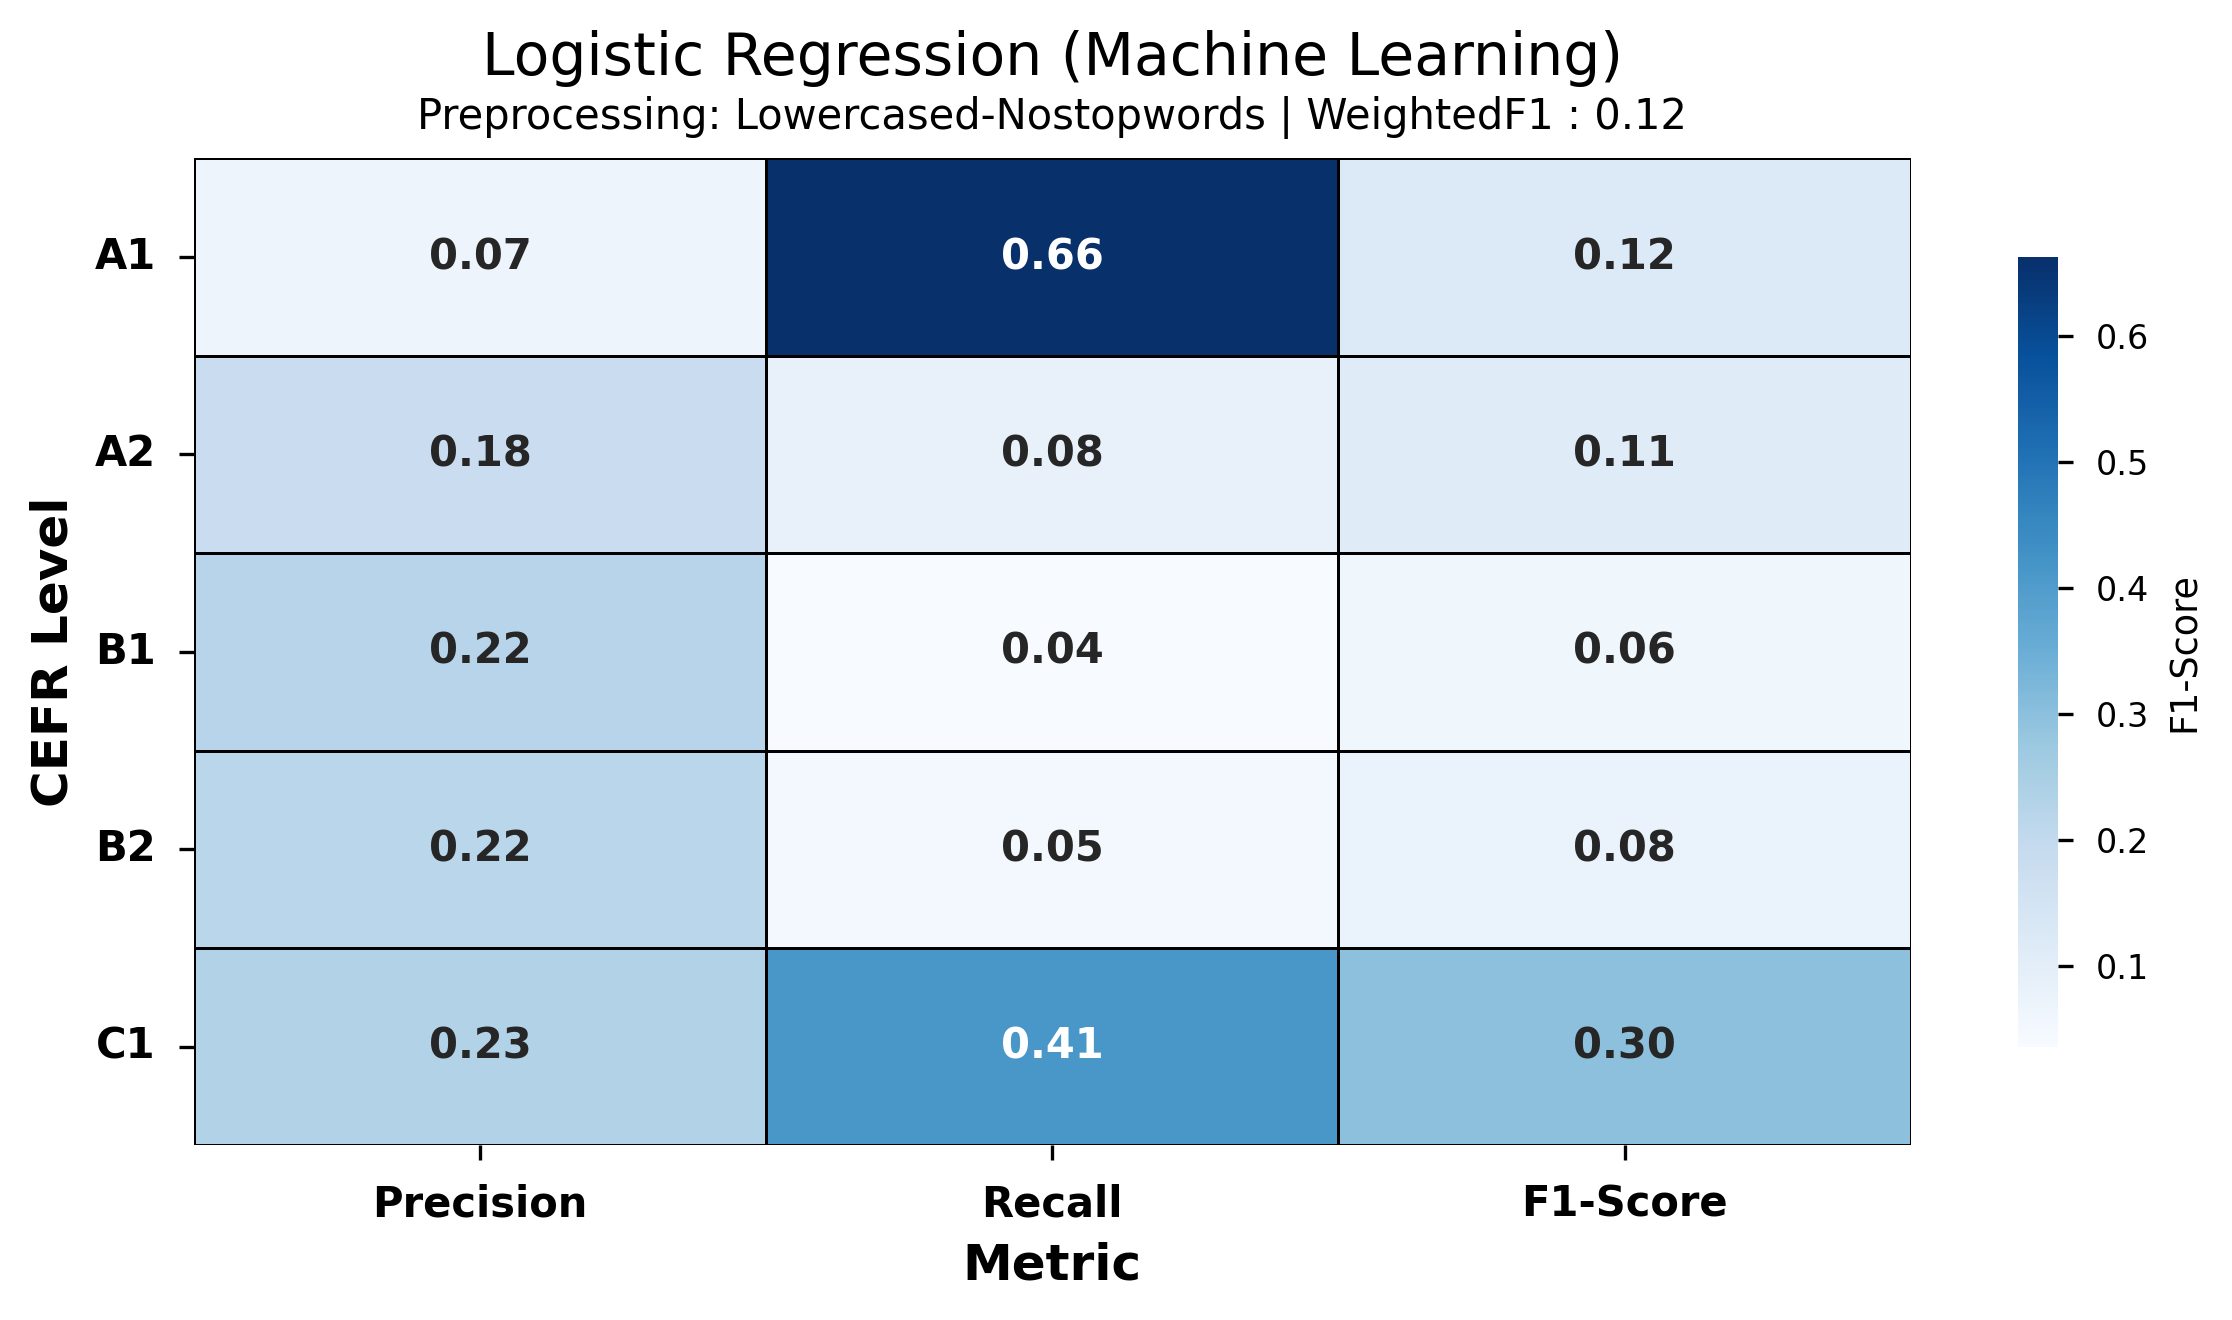

In [29]:
display_report_heatmap(data['generalized']['machine_learning']['logistic_regression'])

###**Gradient Boosting**

####**Dataset MAIN**

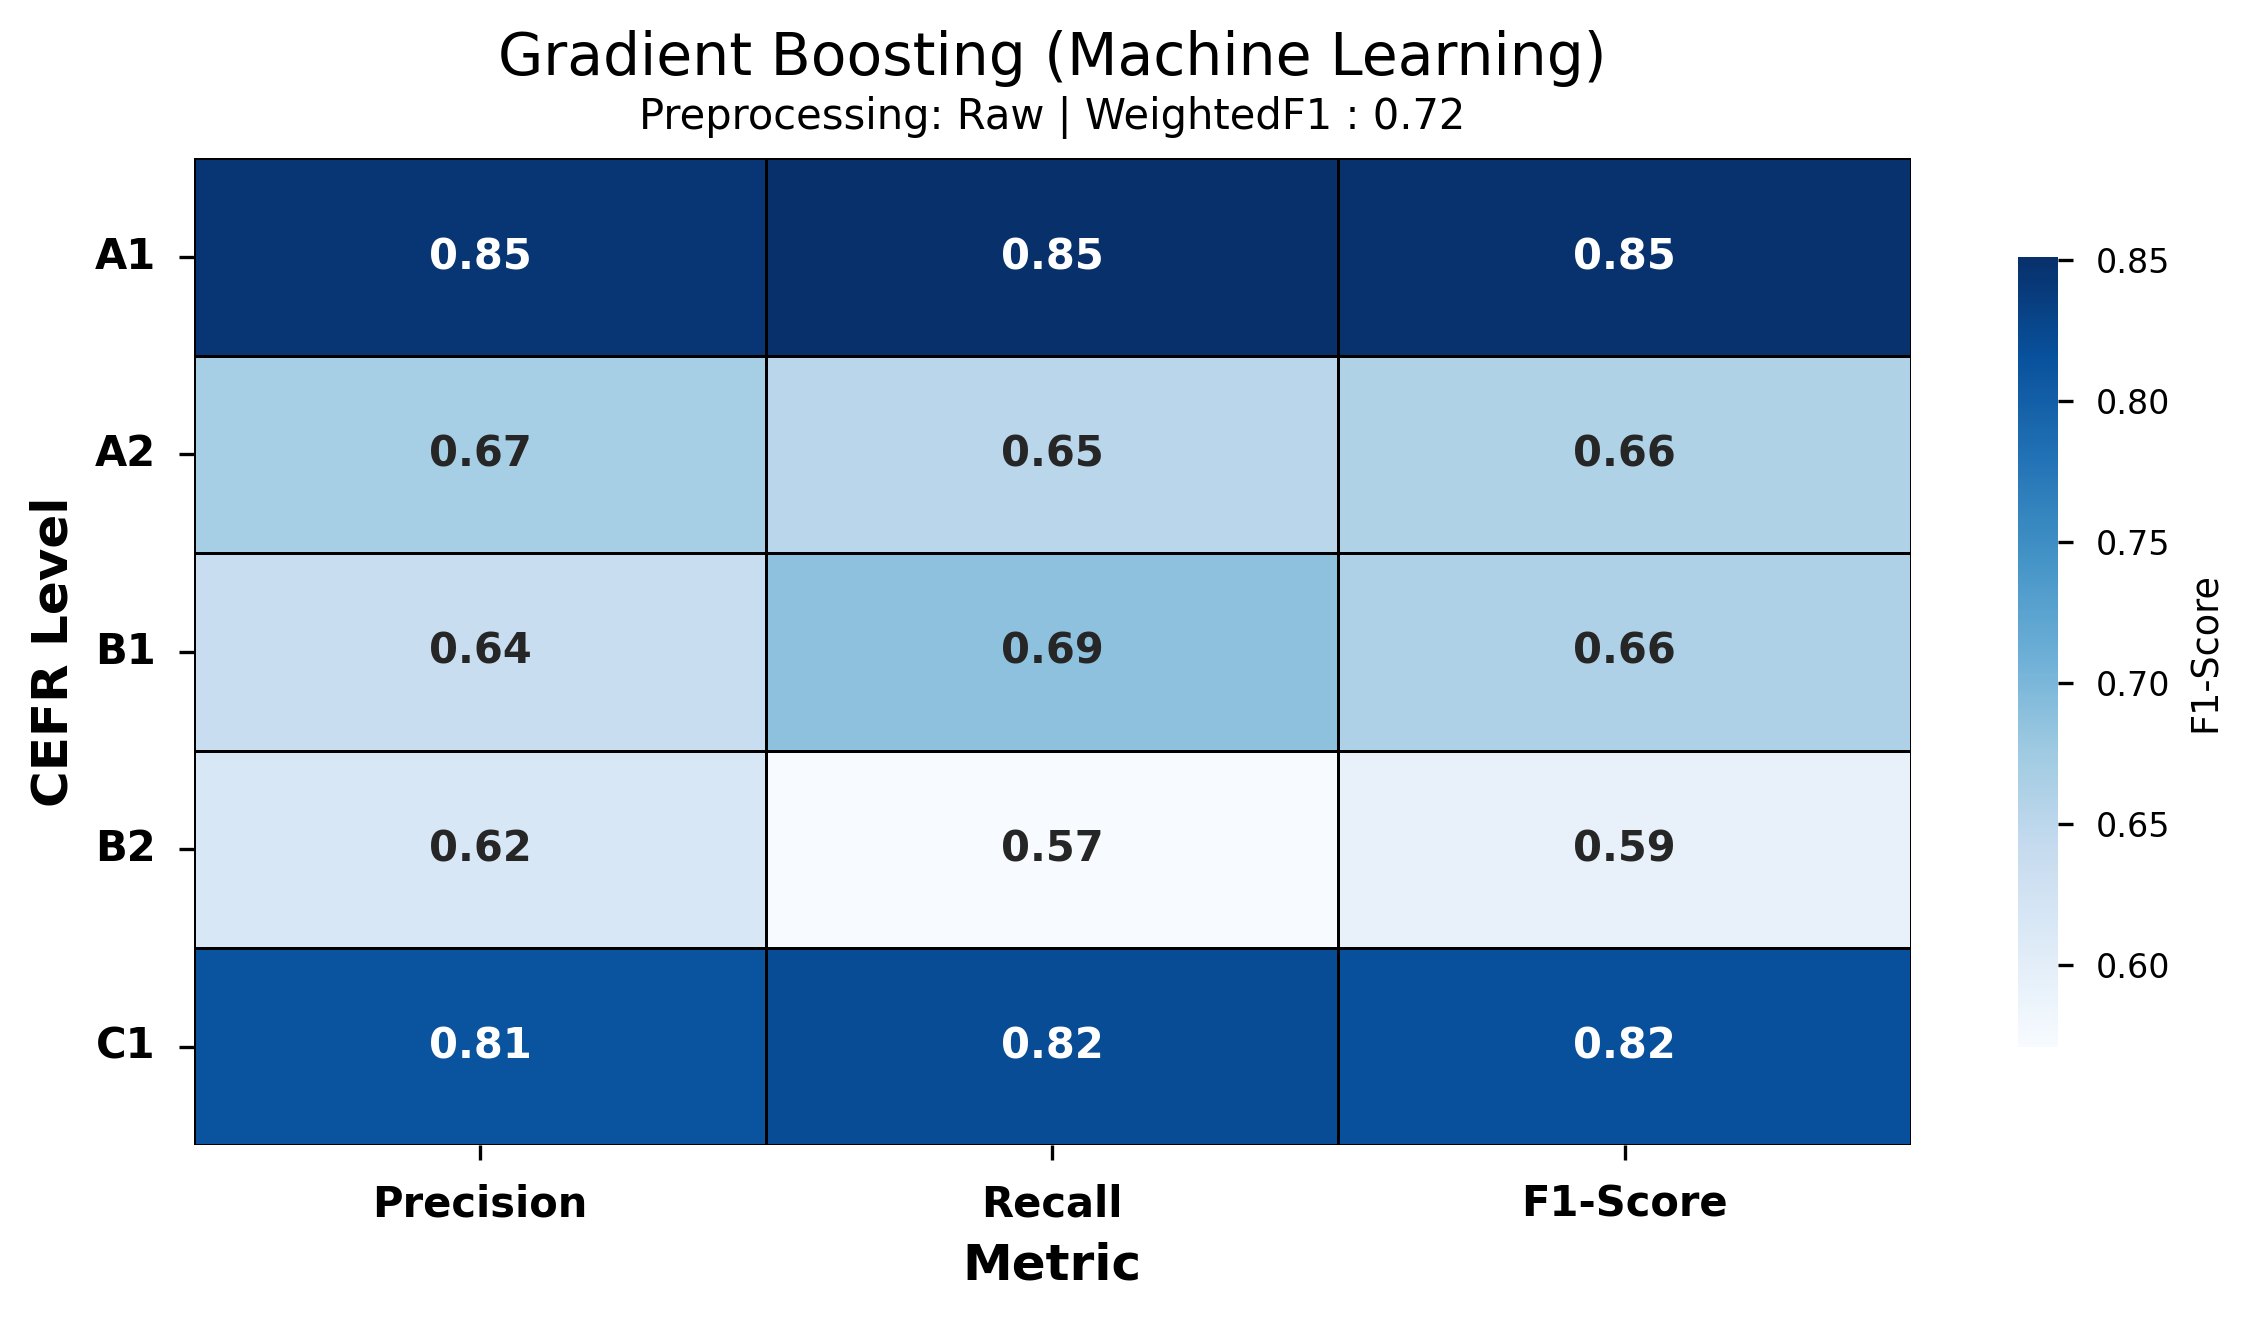

In [30]:
display_report_heatmap(data['main']['machine_learning']['gradient_boosting'])

####**Dataset GENERALIZED**

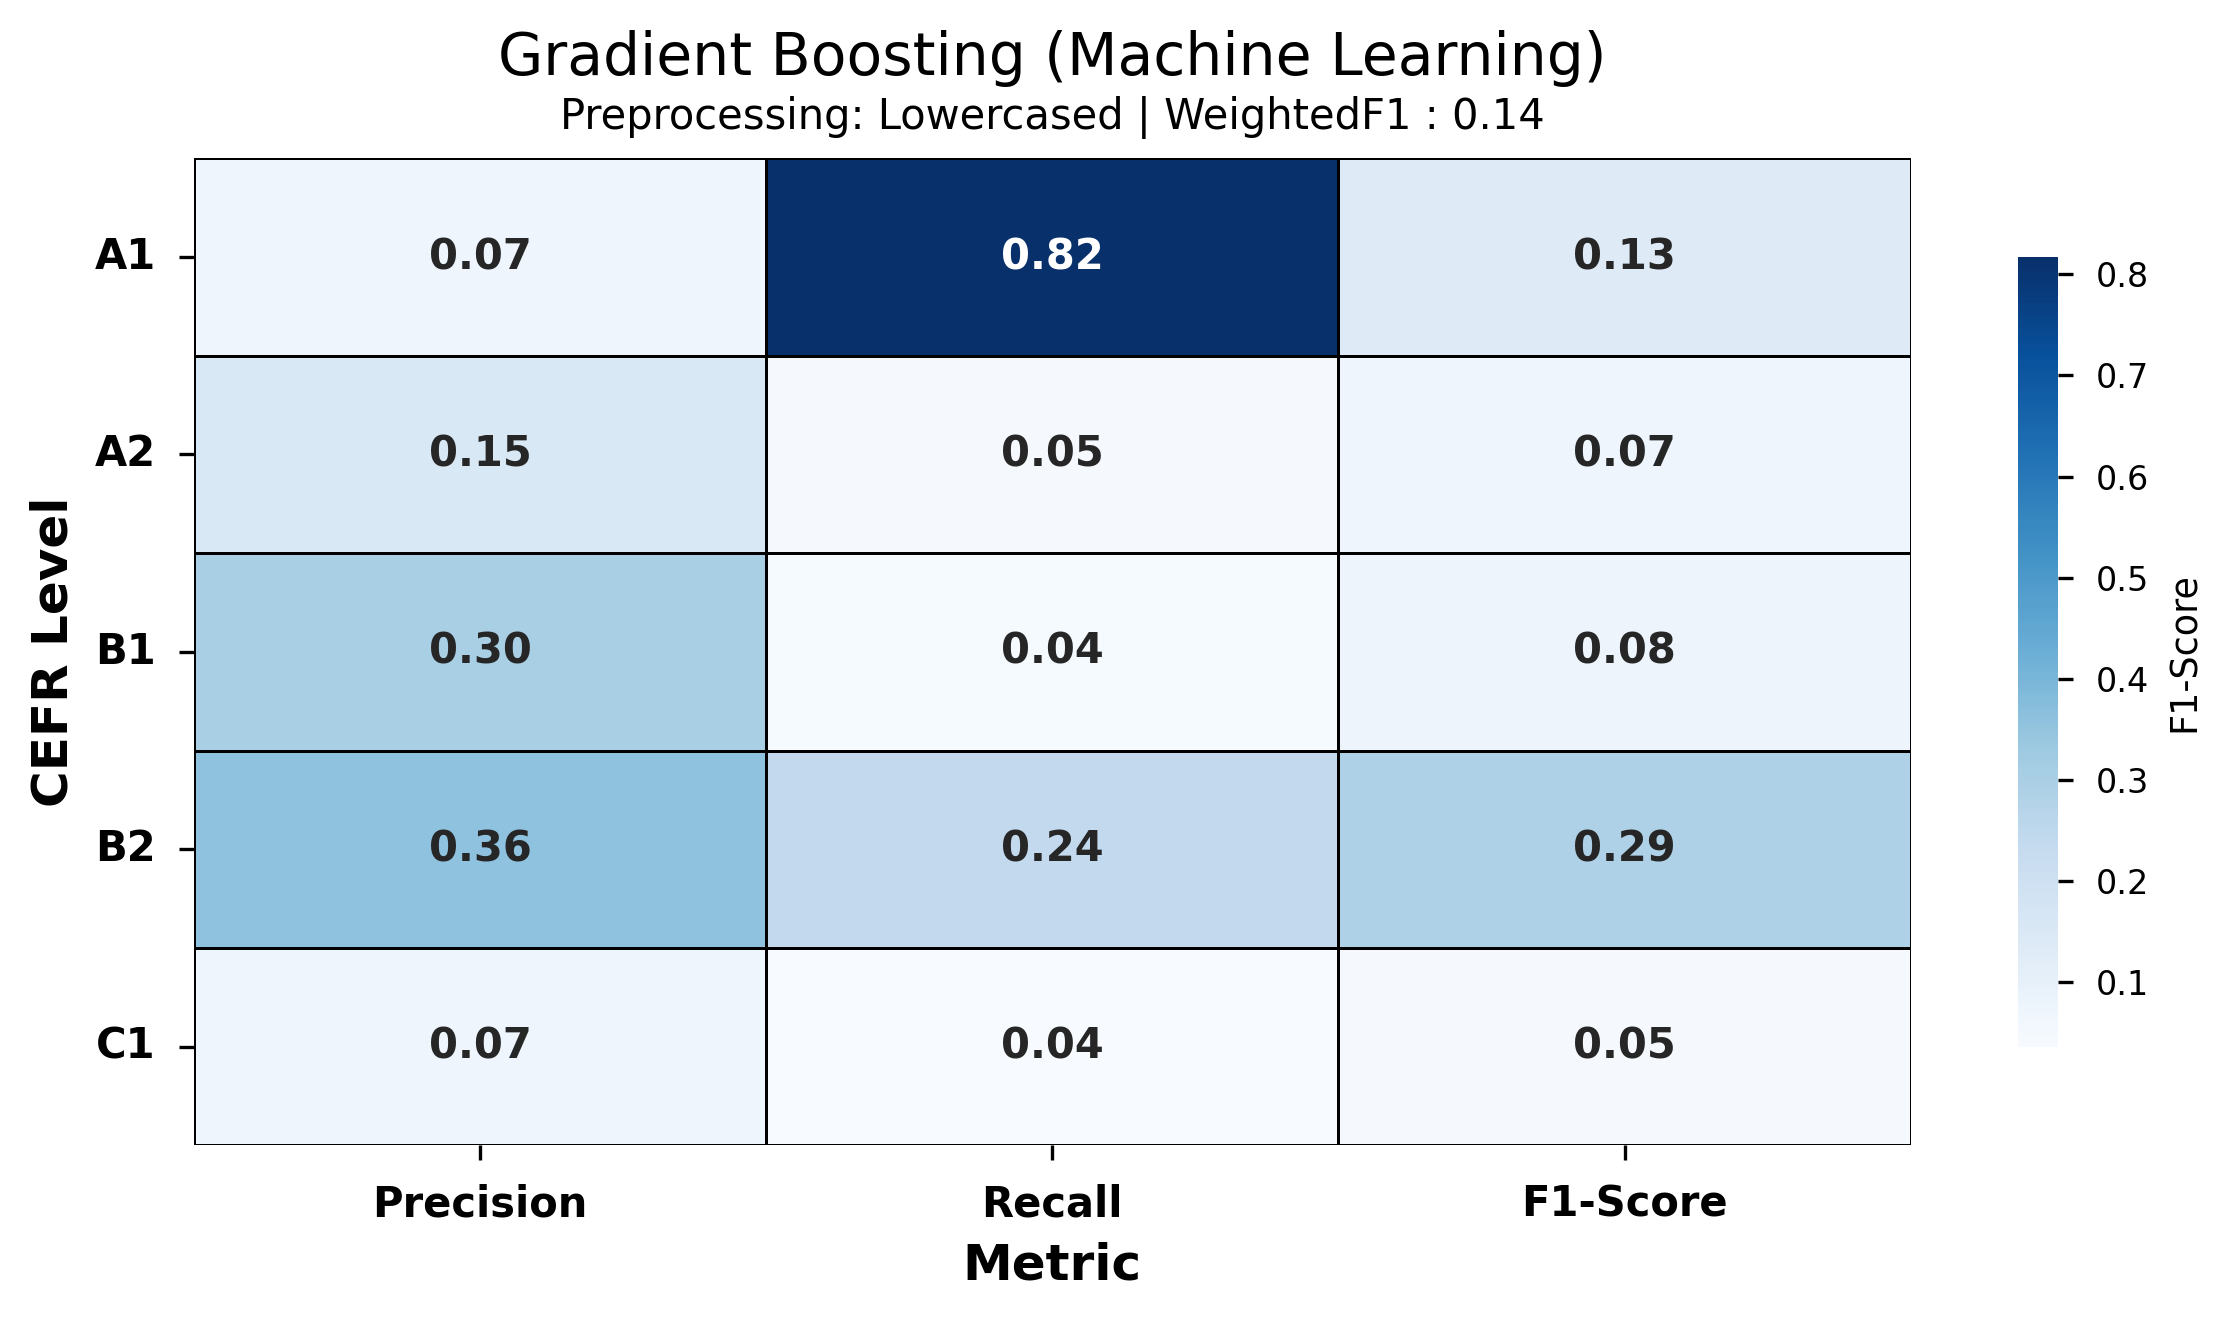

In [31]:
display_report_heatmap(data['generalized']['machine_learning']['gradient_boosting'])

###**Fasttext**

####**Dataset MAIN**
Fasttext invece presenta dei risultati molto promettenti, con la Weighted F1 per ora maggiore. Anche qui sottolineiamo una maggiore differenza tra l'F1-Score "ai margini" e quelle centrali.
La Recall per *C1* è a 0.99, quindi il modello sembra essere molto affidabile nel trovare quasi tutti i testi che sono effettivamente *C1*.

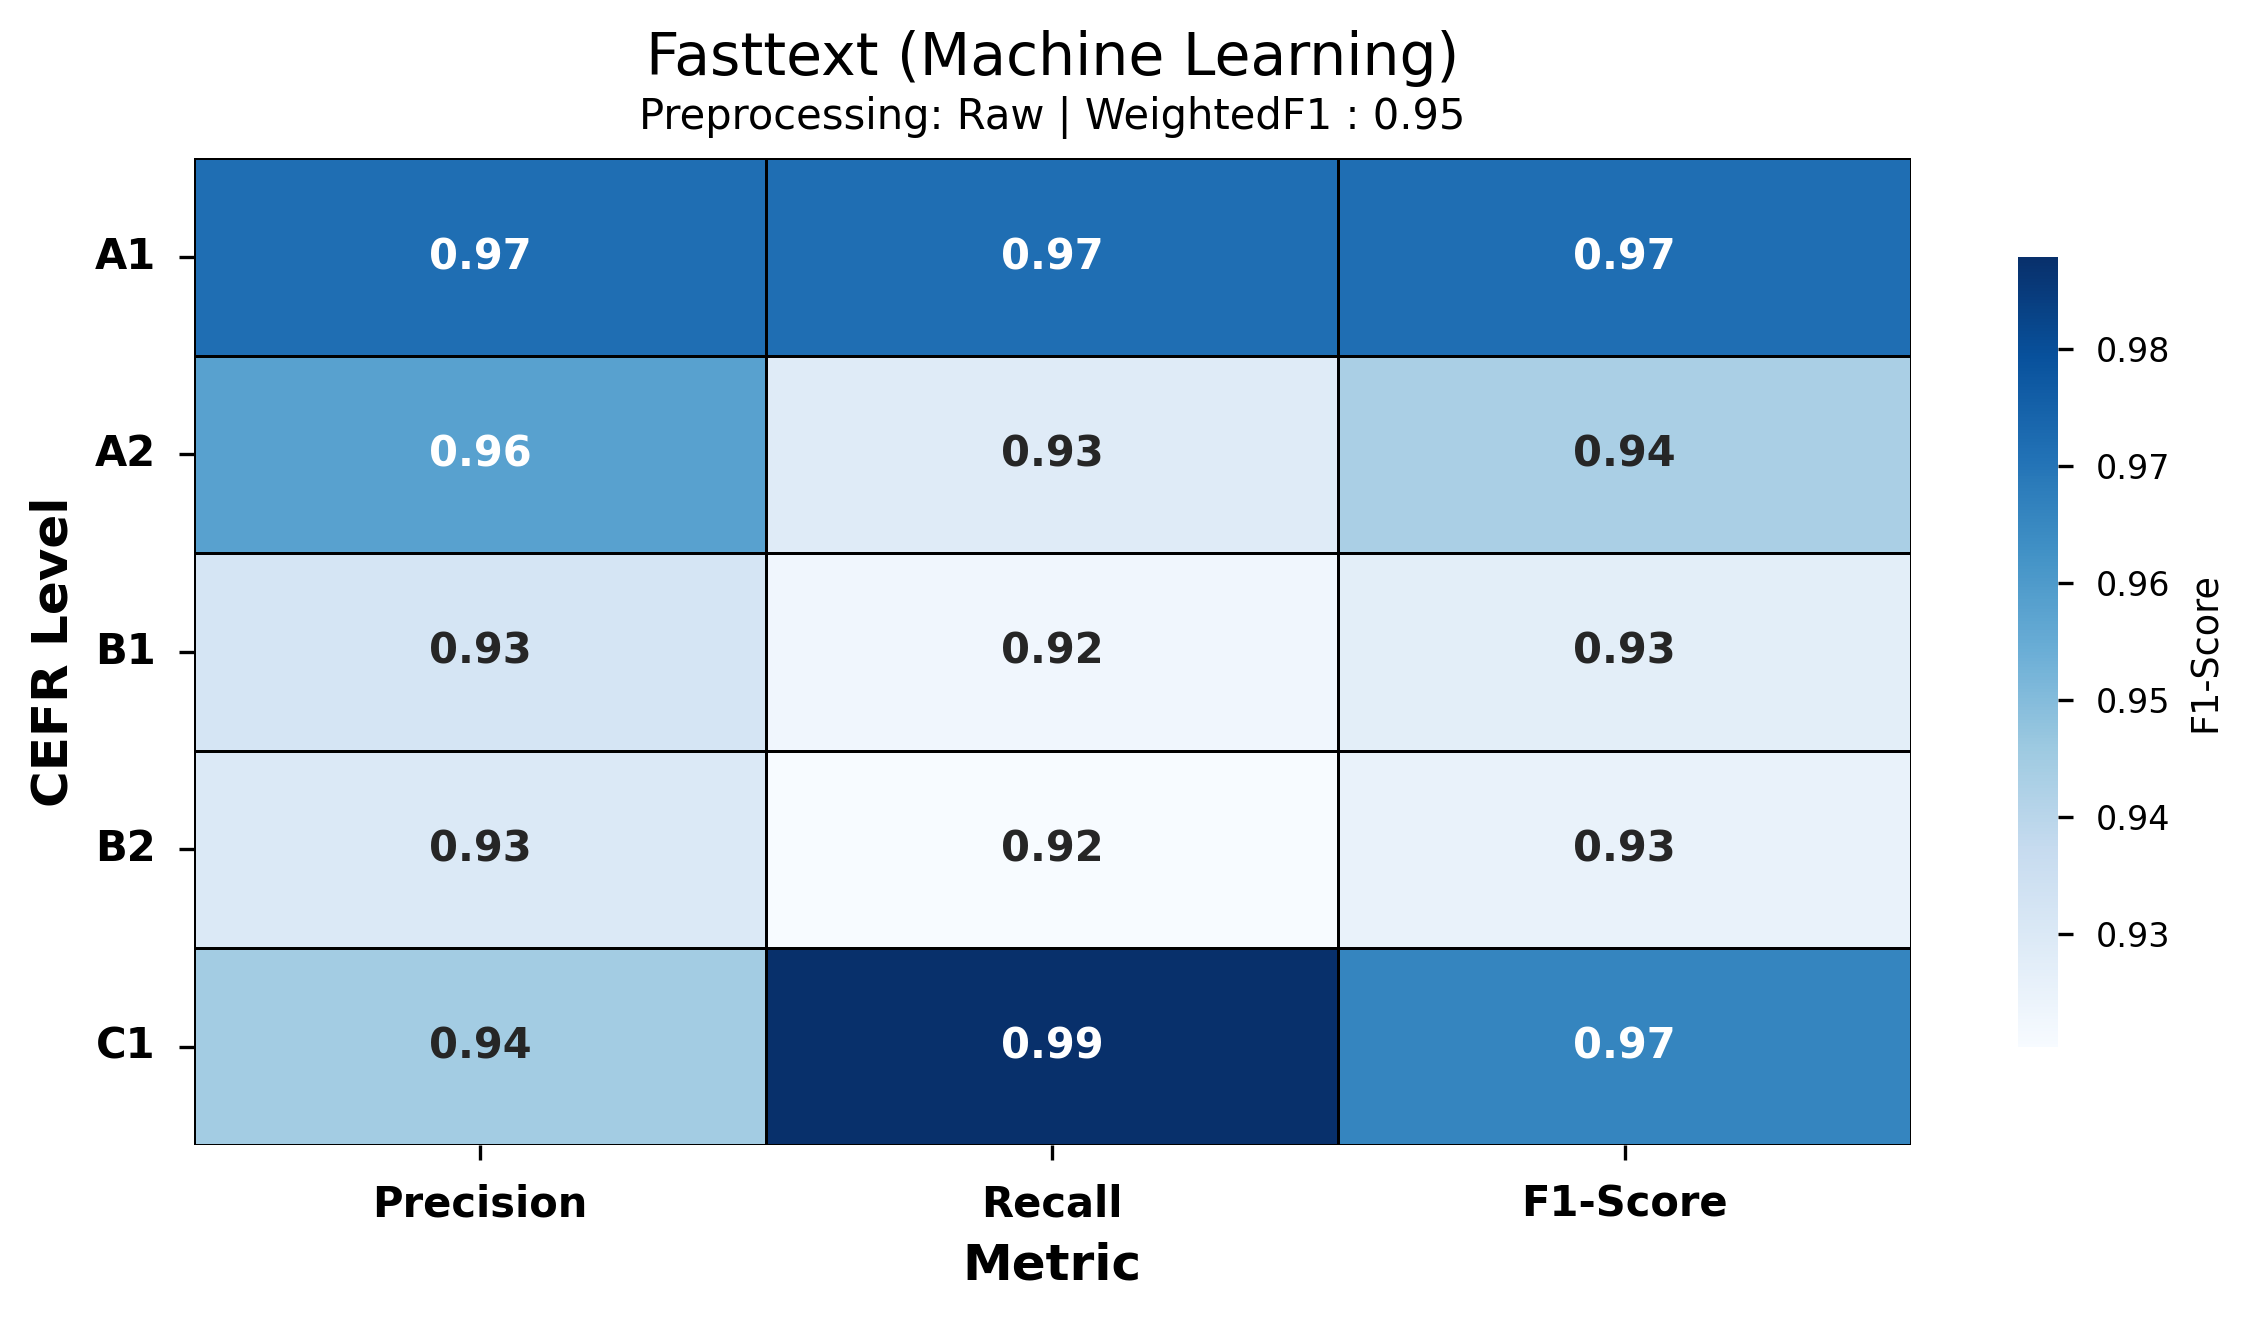

In [32]:
display_report_heatmap(data['main']['machine_learning']['fasttext'])

####**Dataset GENERALIZED**
Notiamo invece come la performance sia praticamente 4 volte più bassa rispetto al dataset precedente:

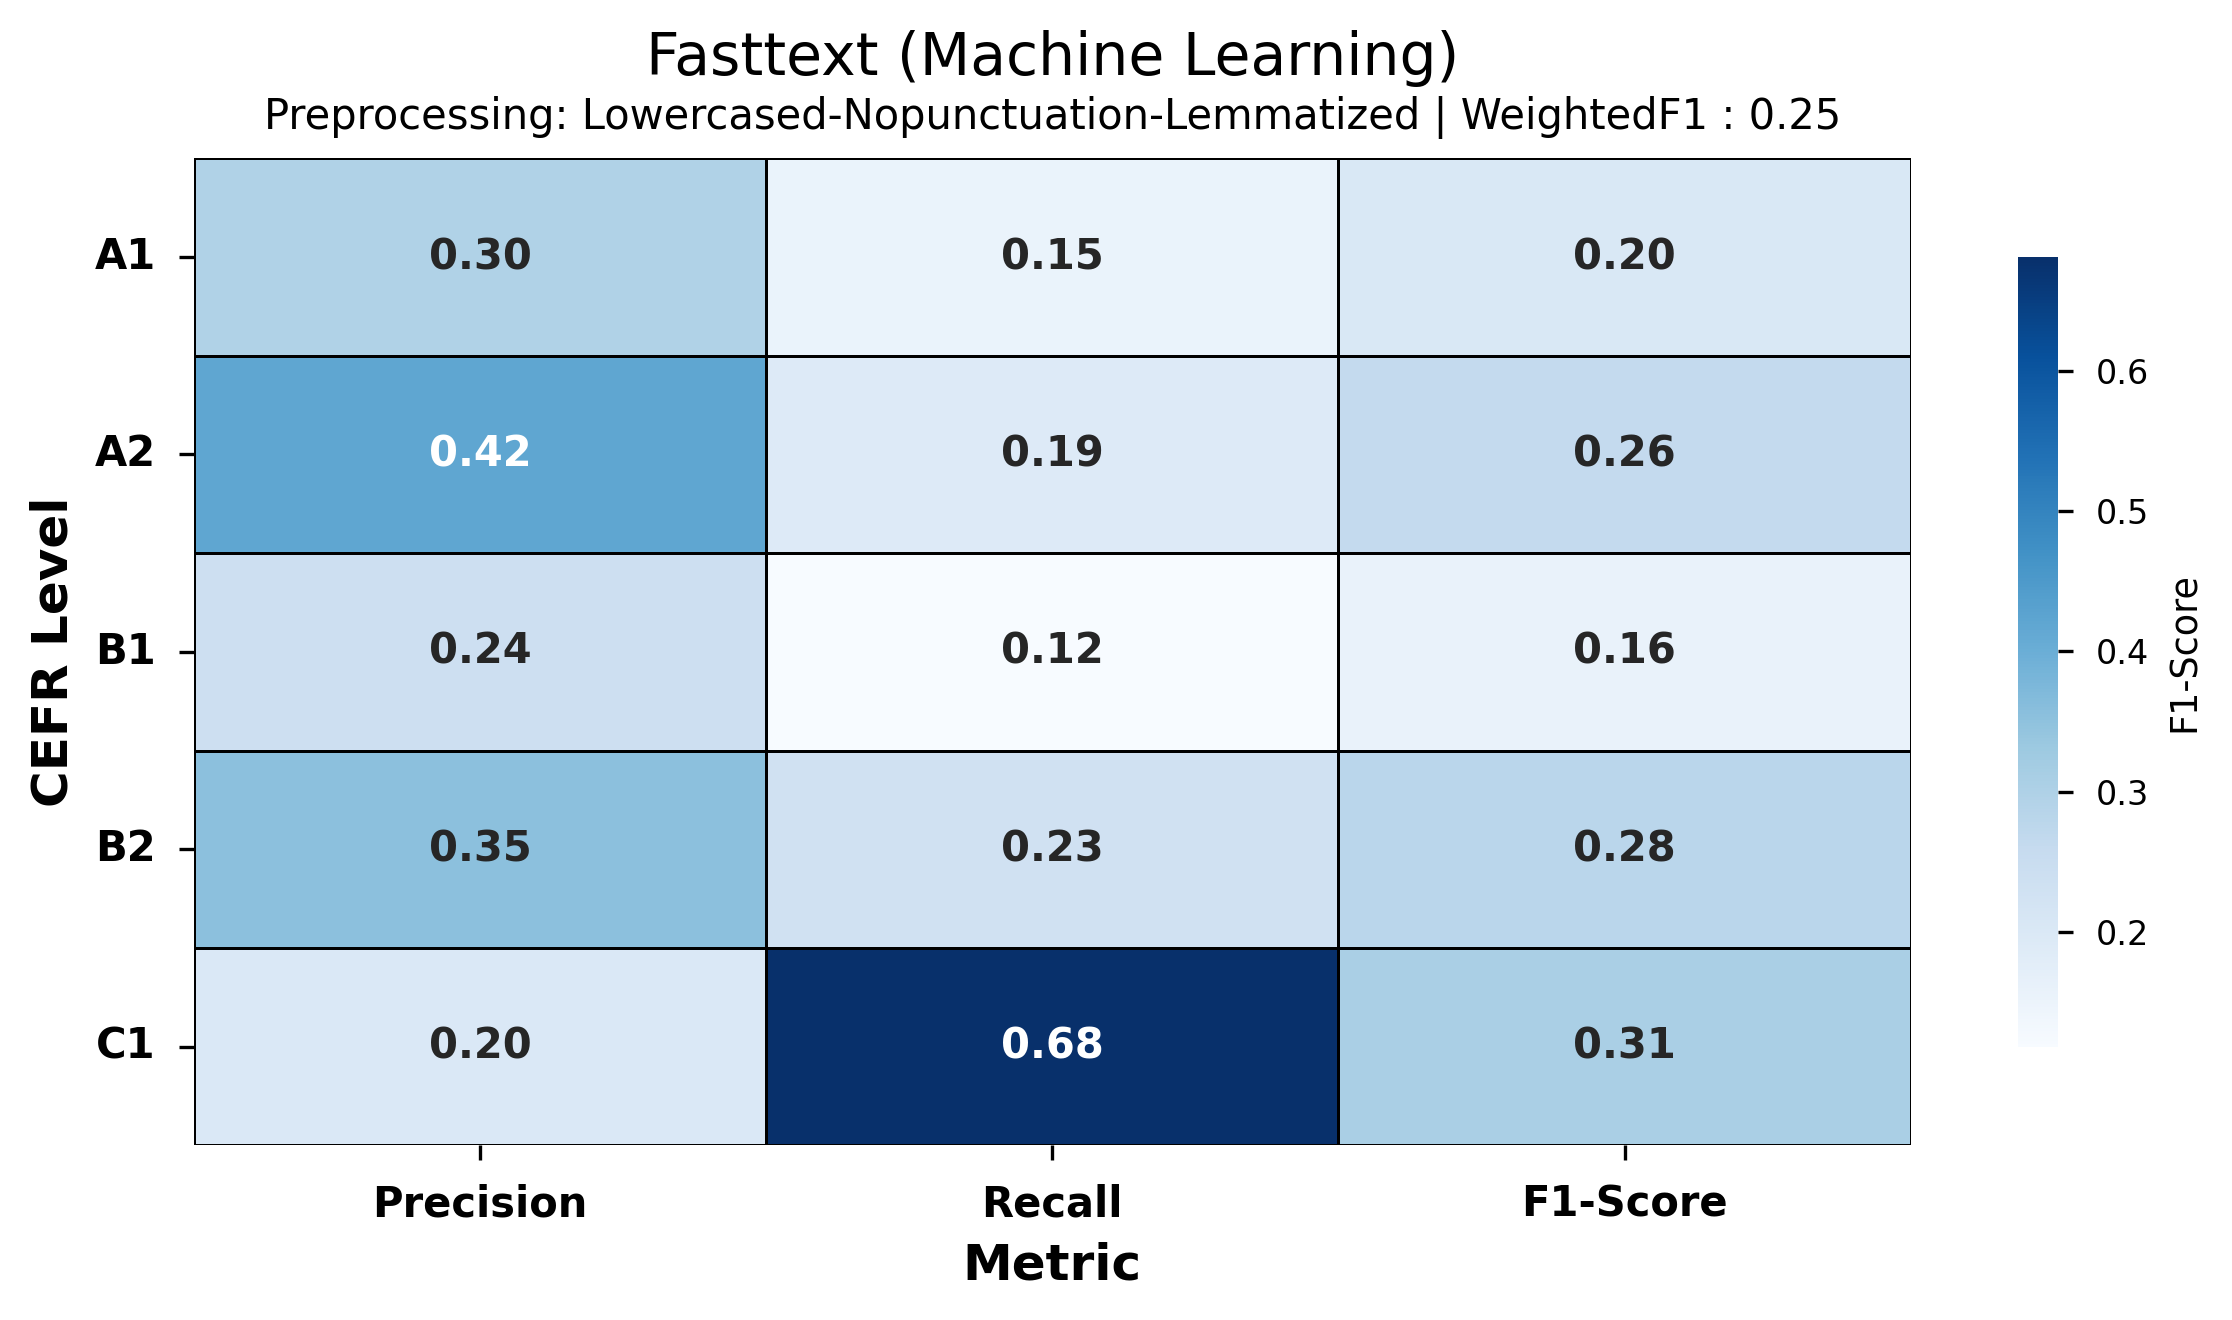

In [33]:
display_report_heatmap(data['generalized']['machine_learning']['fasttext'])

###**Paragone dei vari metodi ML**

####**Dataset main**
Il miglior metodo sul dataset *main* è Fasttext, con una Weighted Average di 0.95. Gli altri metodi invece sono mediamente stabili.

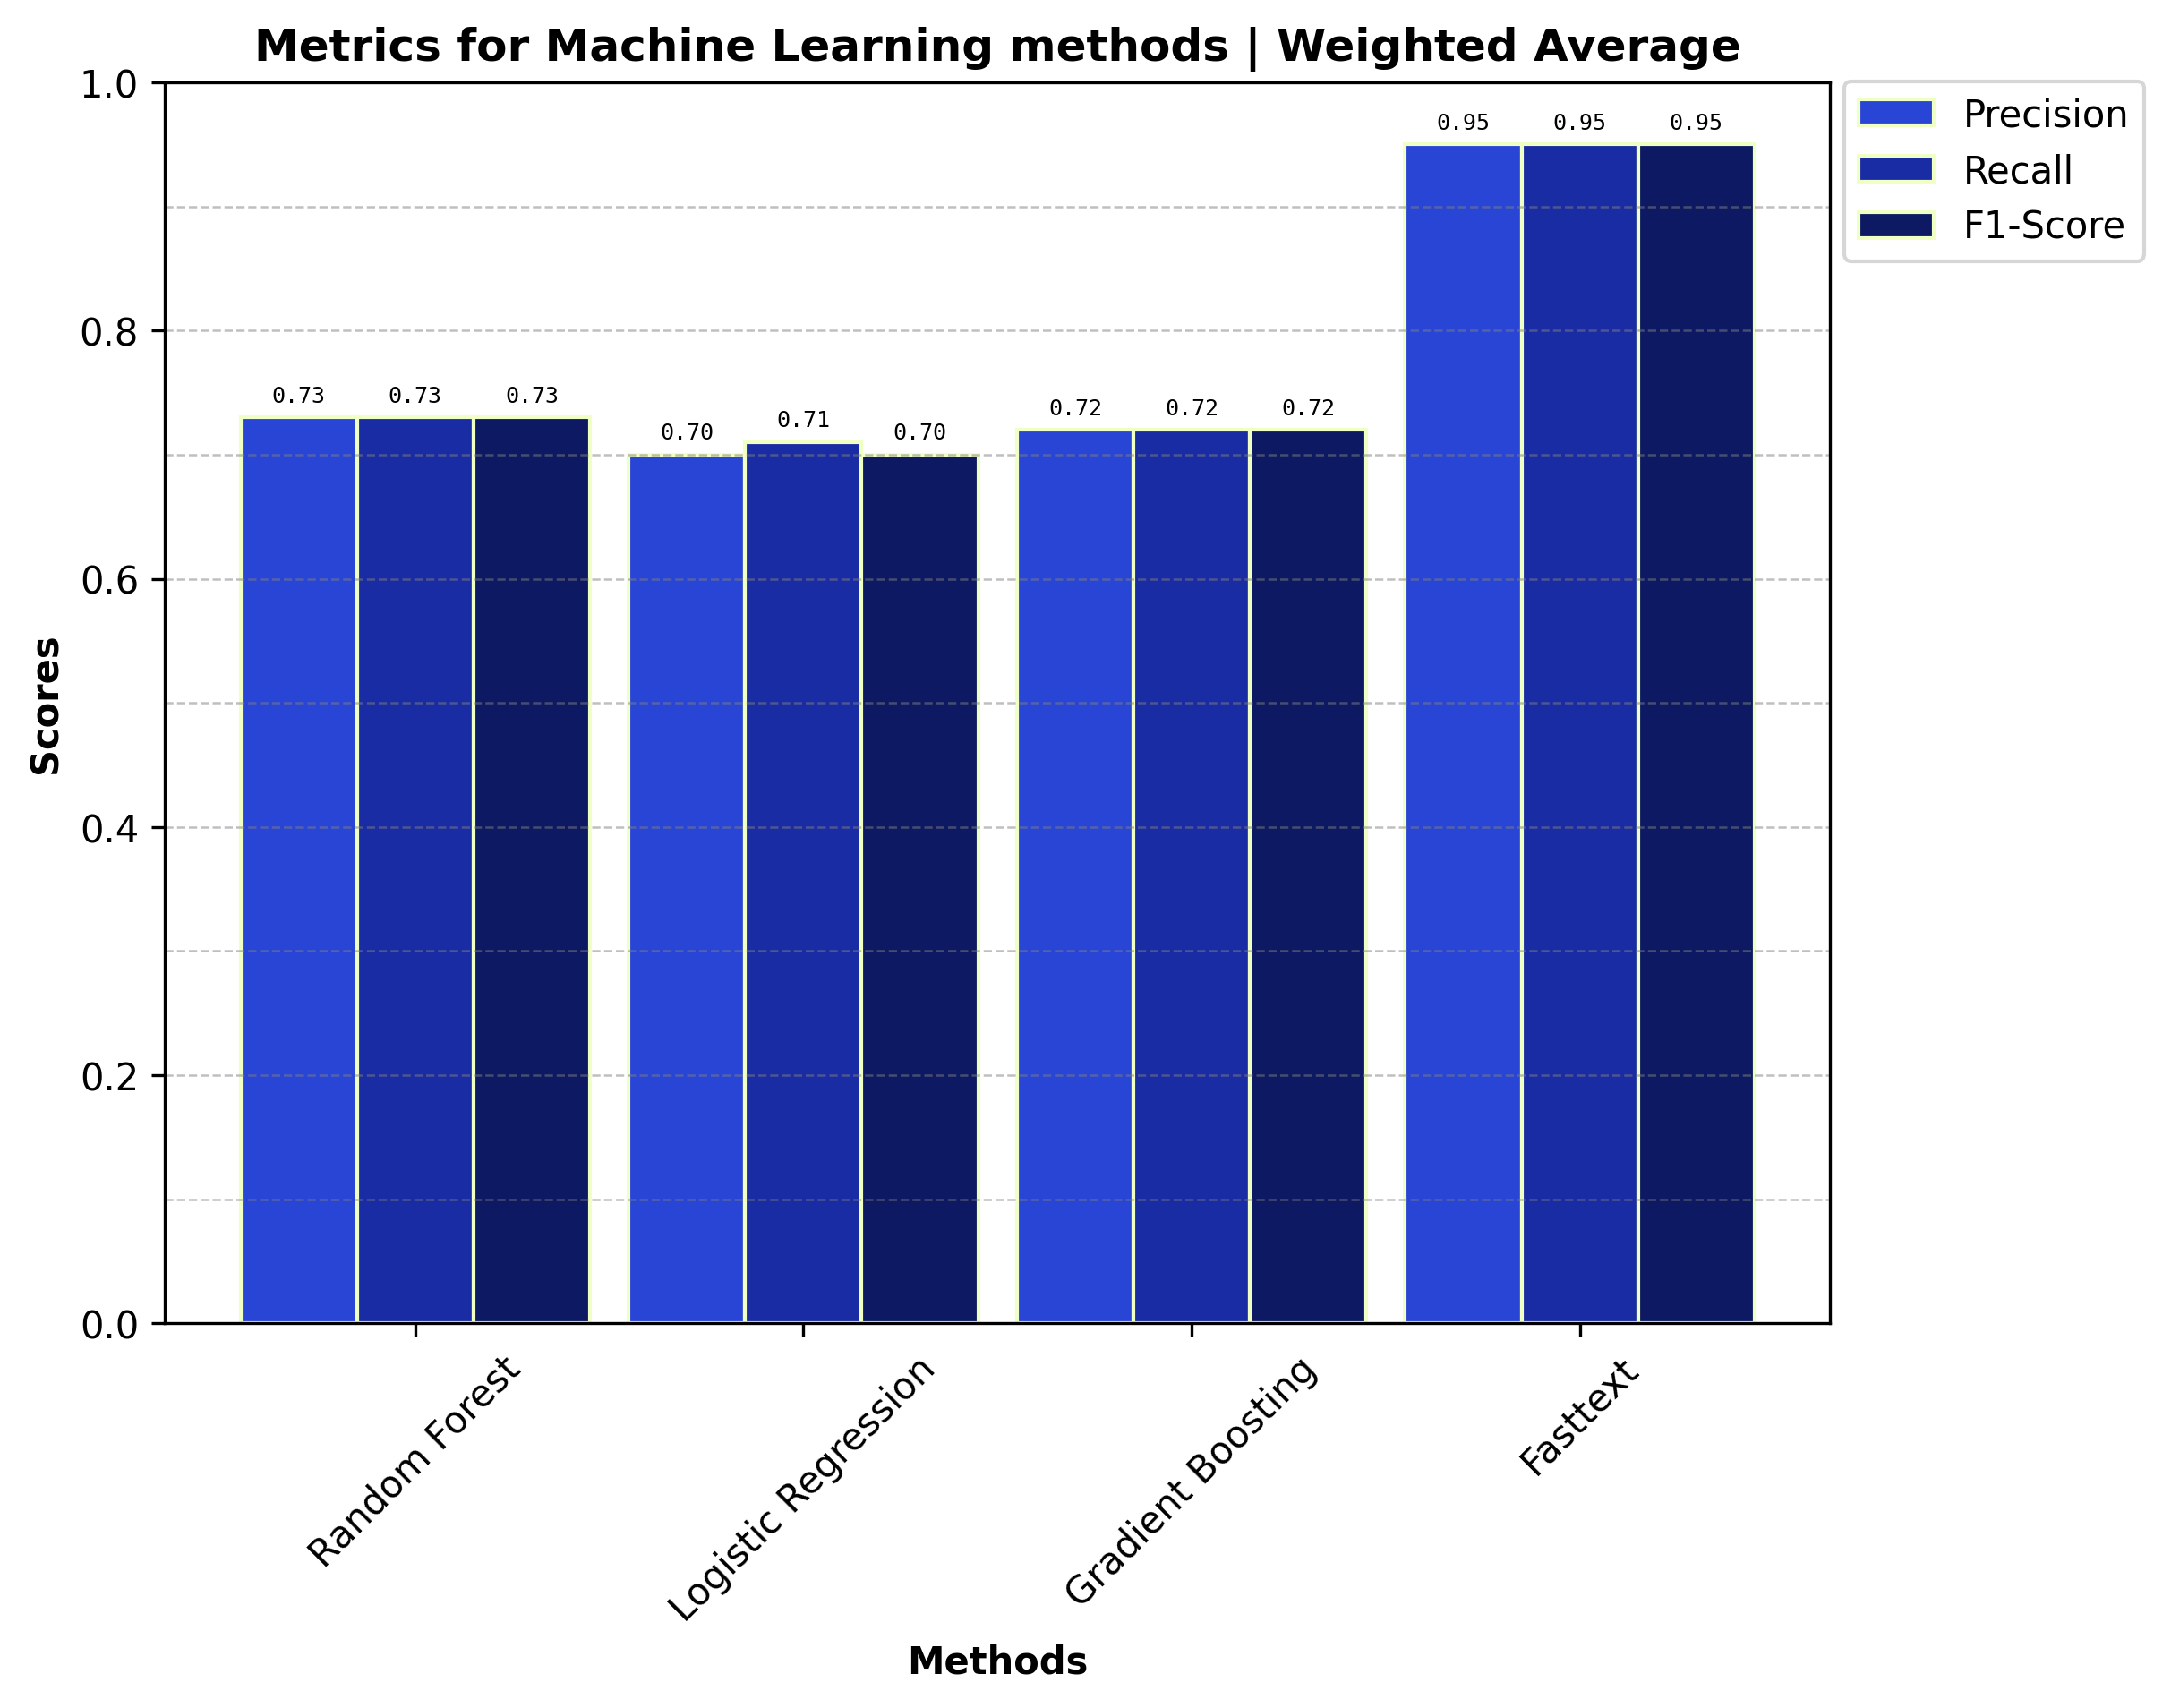

In [34]:
display_approach_barplot(data['main']['machine_learning'])

####**Dataset generalizzato**
I 4 metodi però, pur mantenendo l'"ordine" di performance rispetto alla cella precedente, perdono la maggiorparte del loro potere predittivo.

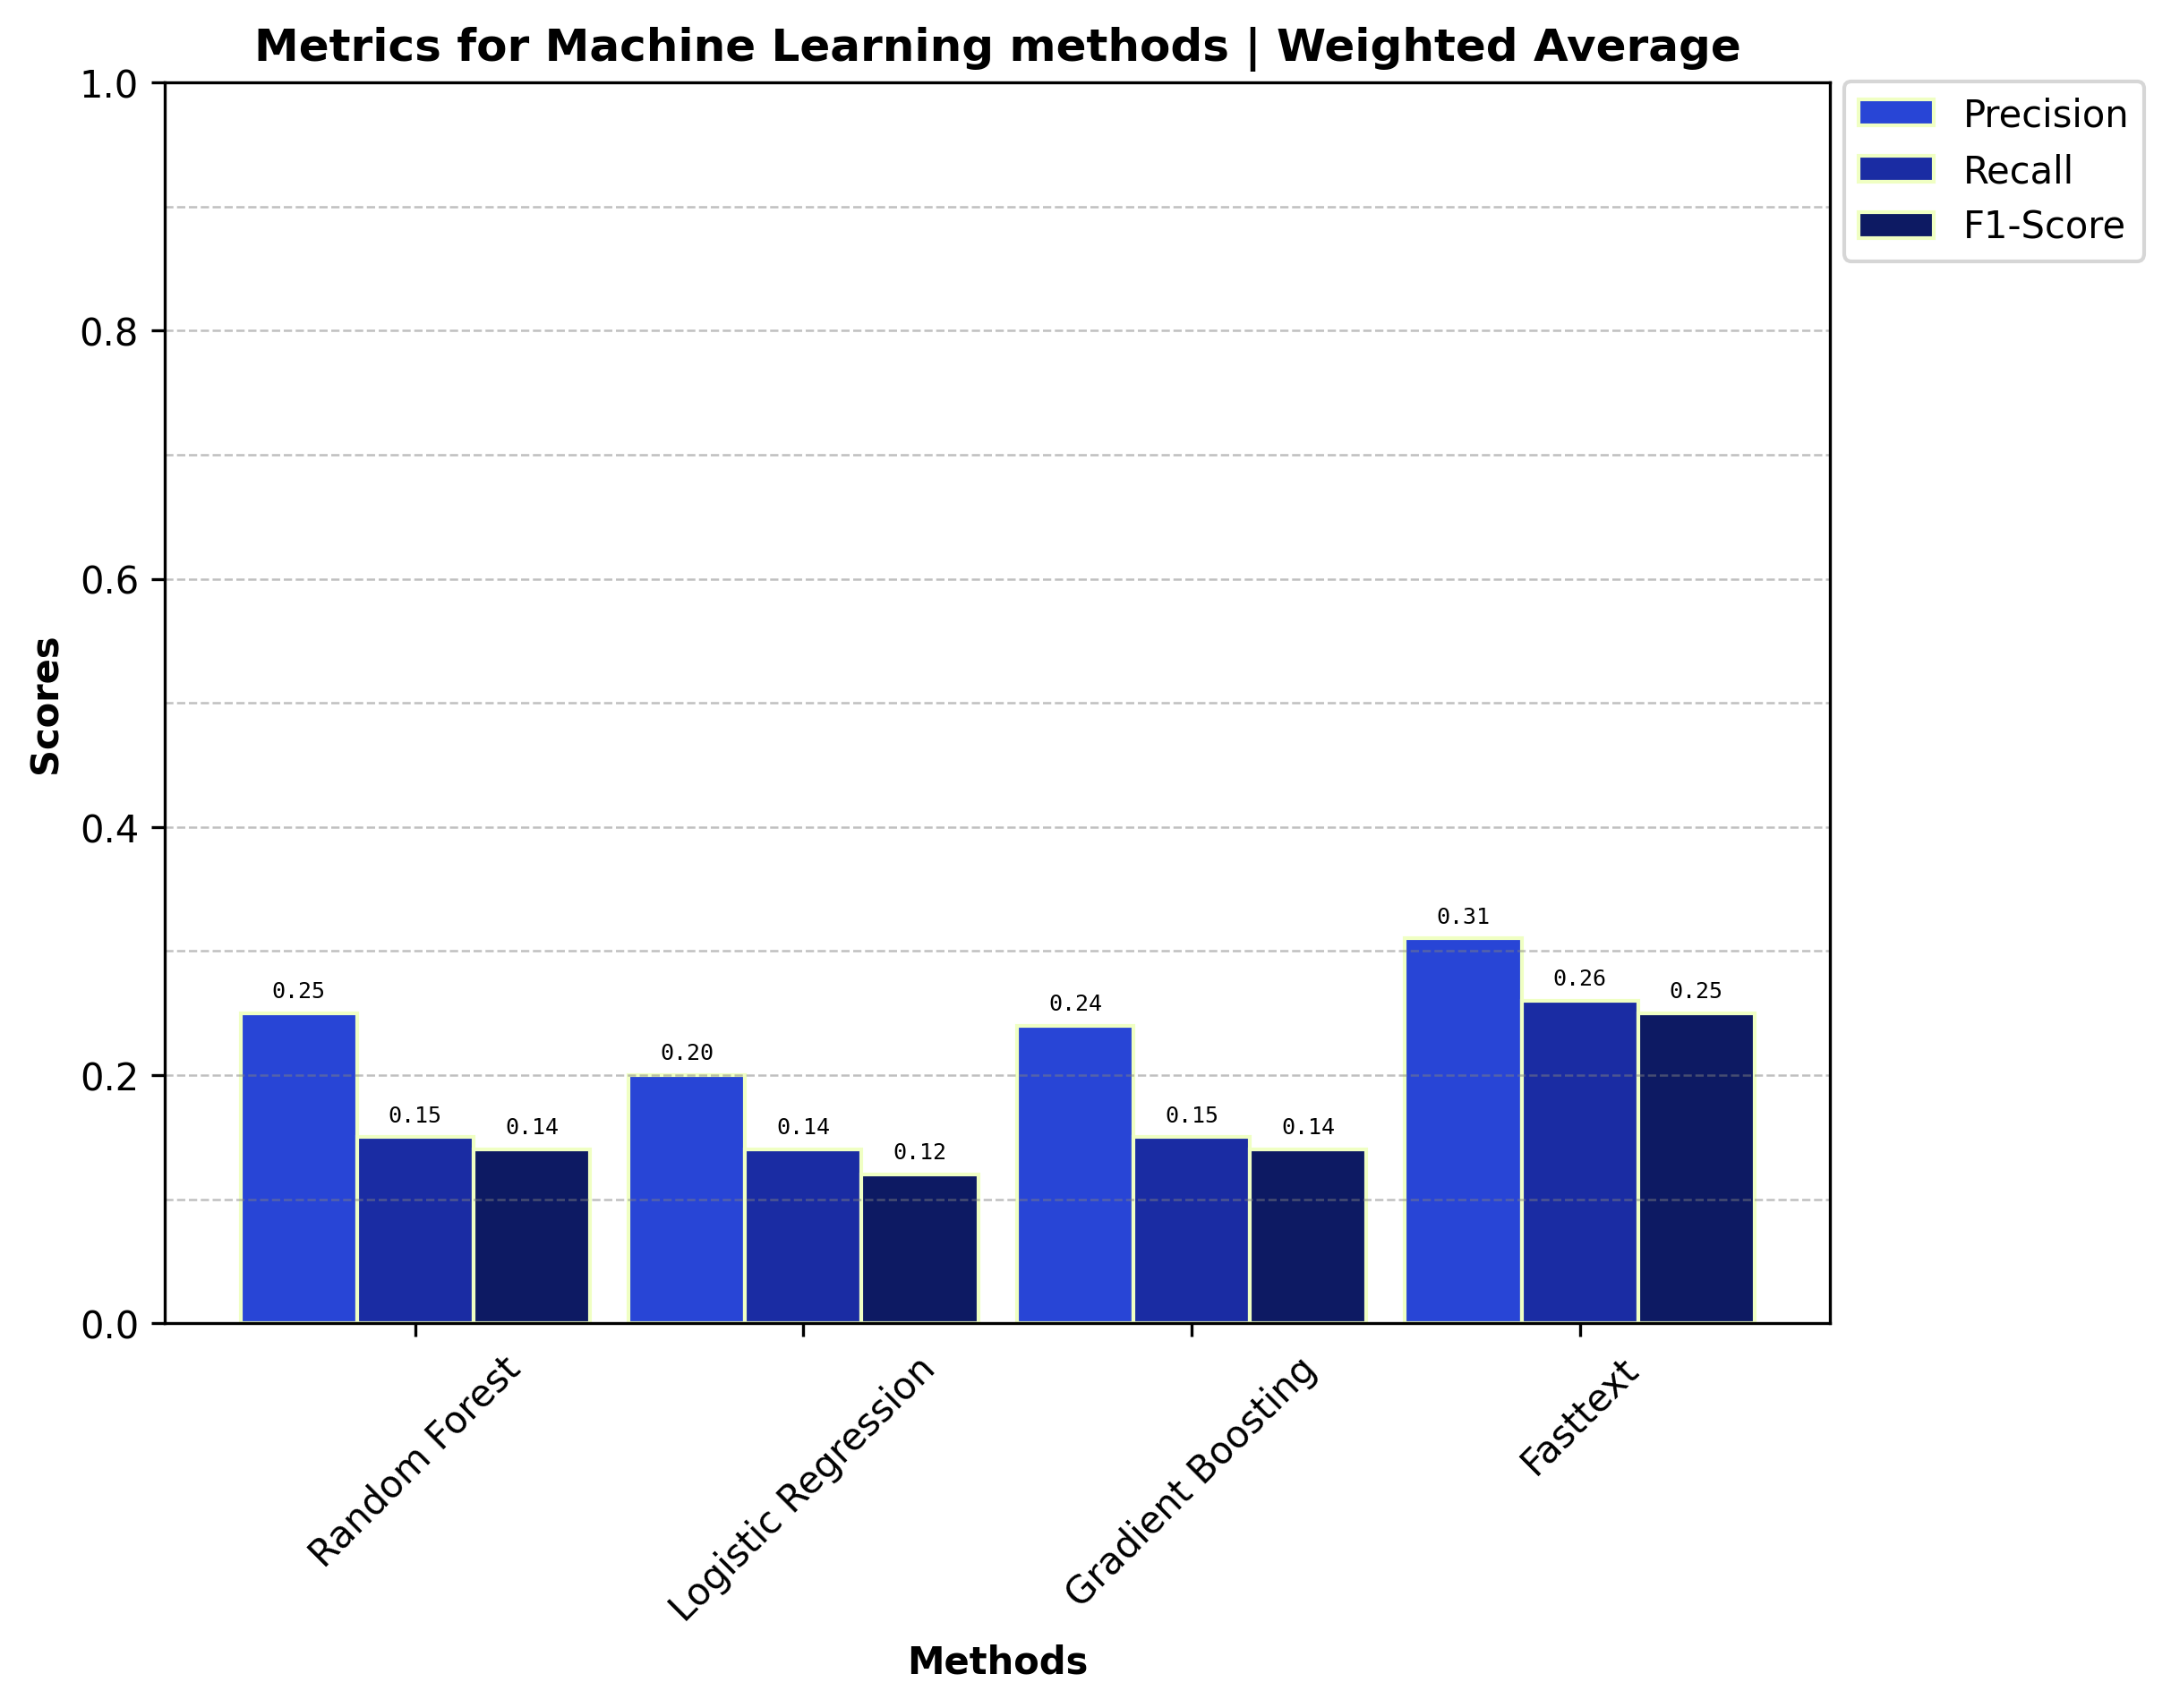

In [35]:
display_approach_barplot(data['generalized']['machine_learning'])

##**LLM: migliore *Weighted F1-Score***
Tramite Gemini sono state create 1500 predizioni, sia per il metodo Zero-Shot, sia per il metodo Few-Shot, solamente sul dataset di testing "*main*".

###**Paragone dei vari metodi con LLM**
Le performance non variano di molto, tuttavia tra le due, la tecnica Few Shot presenta 0.07 punti in più rispetto alla tecnica Zero Shot:

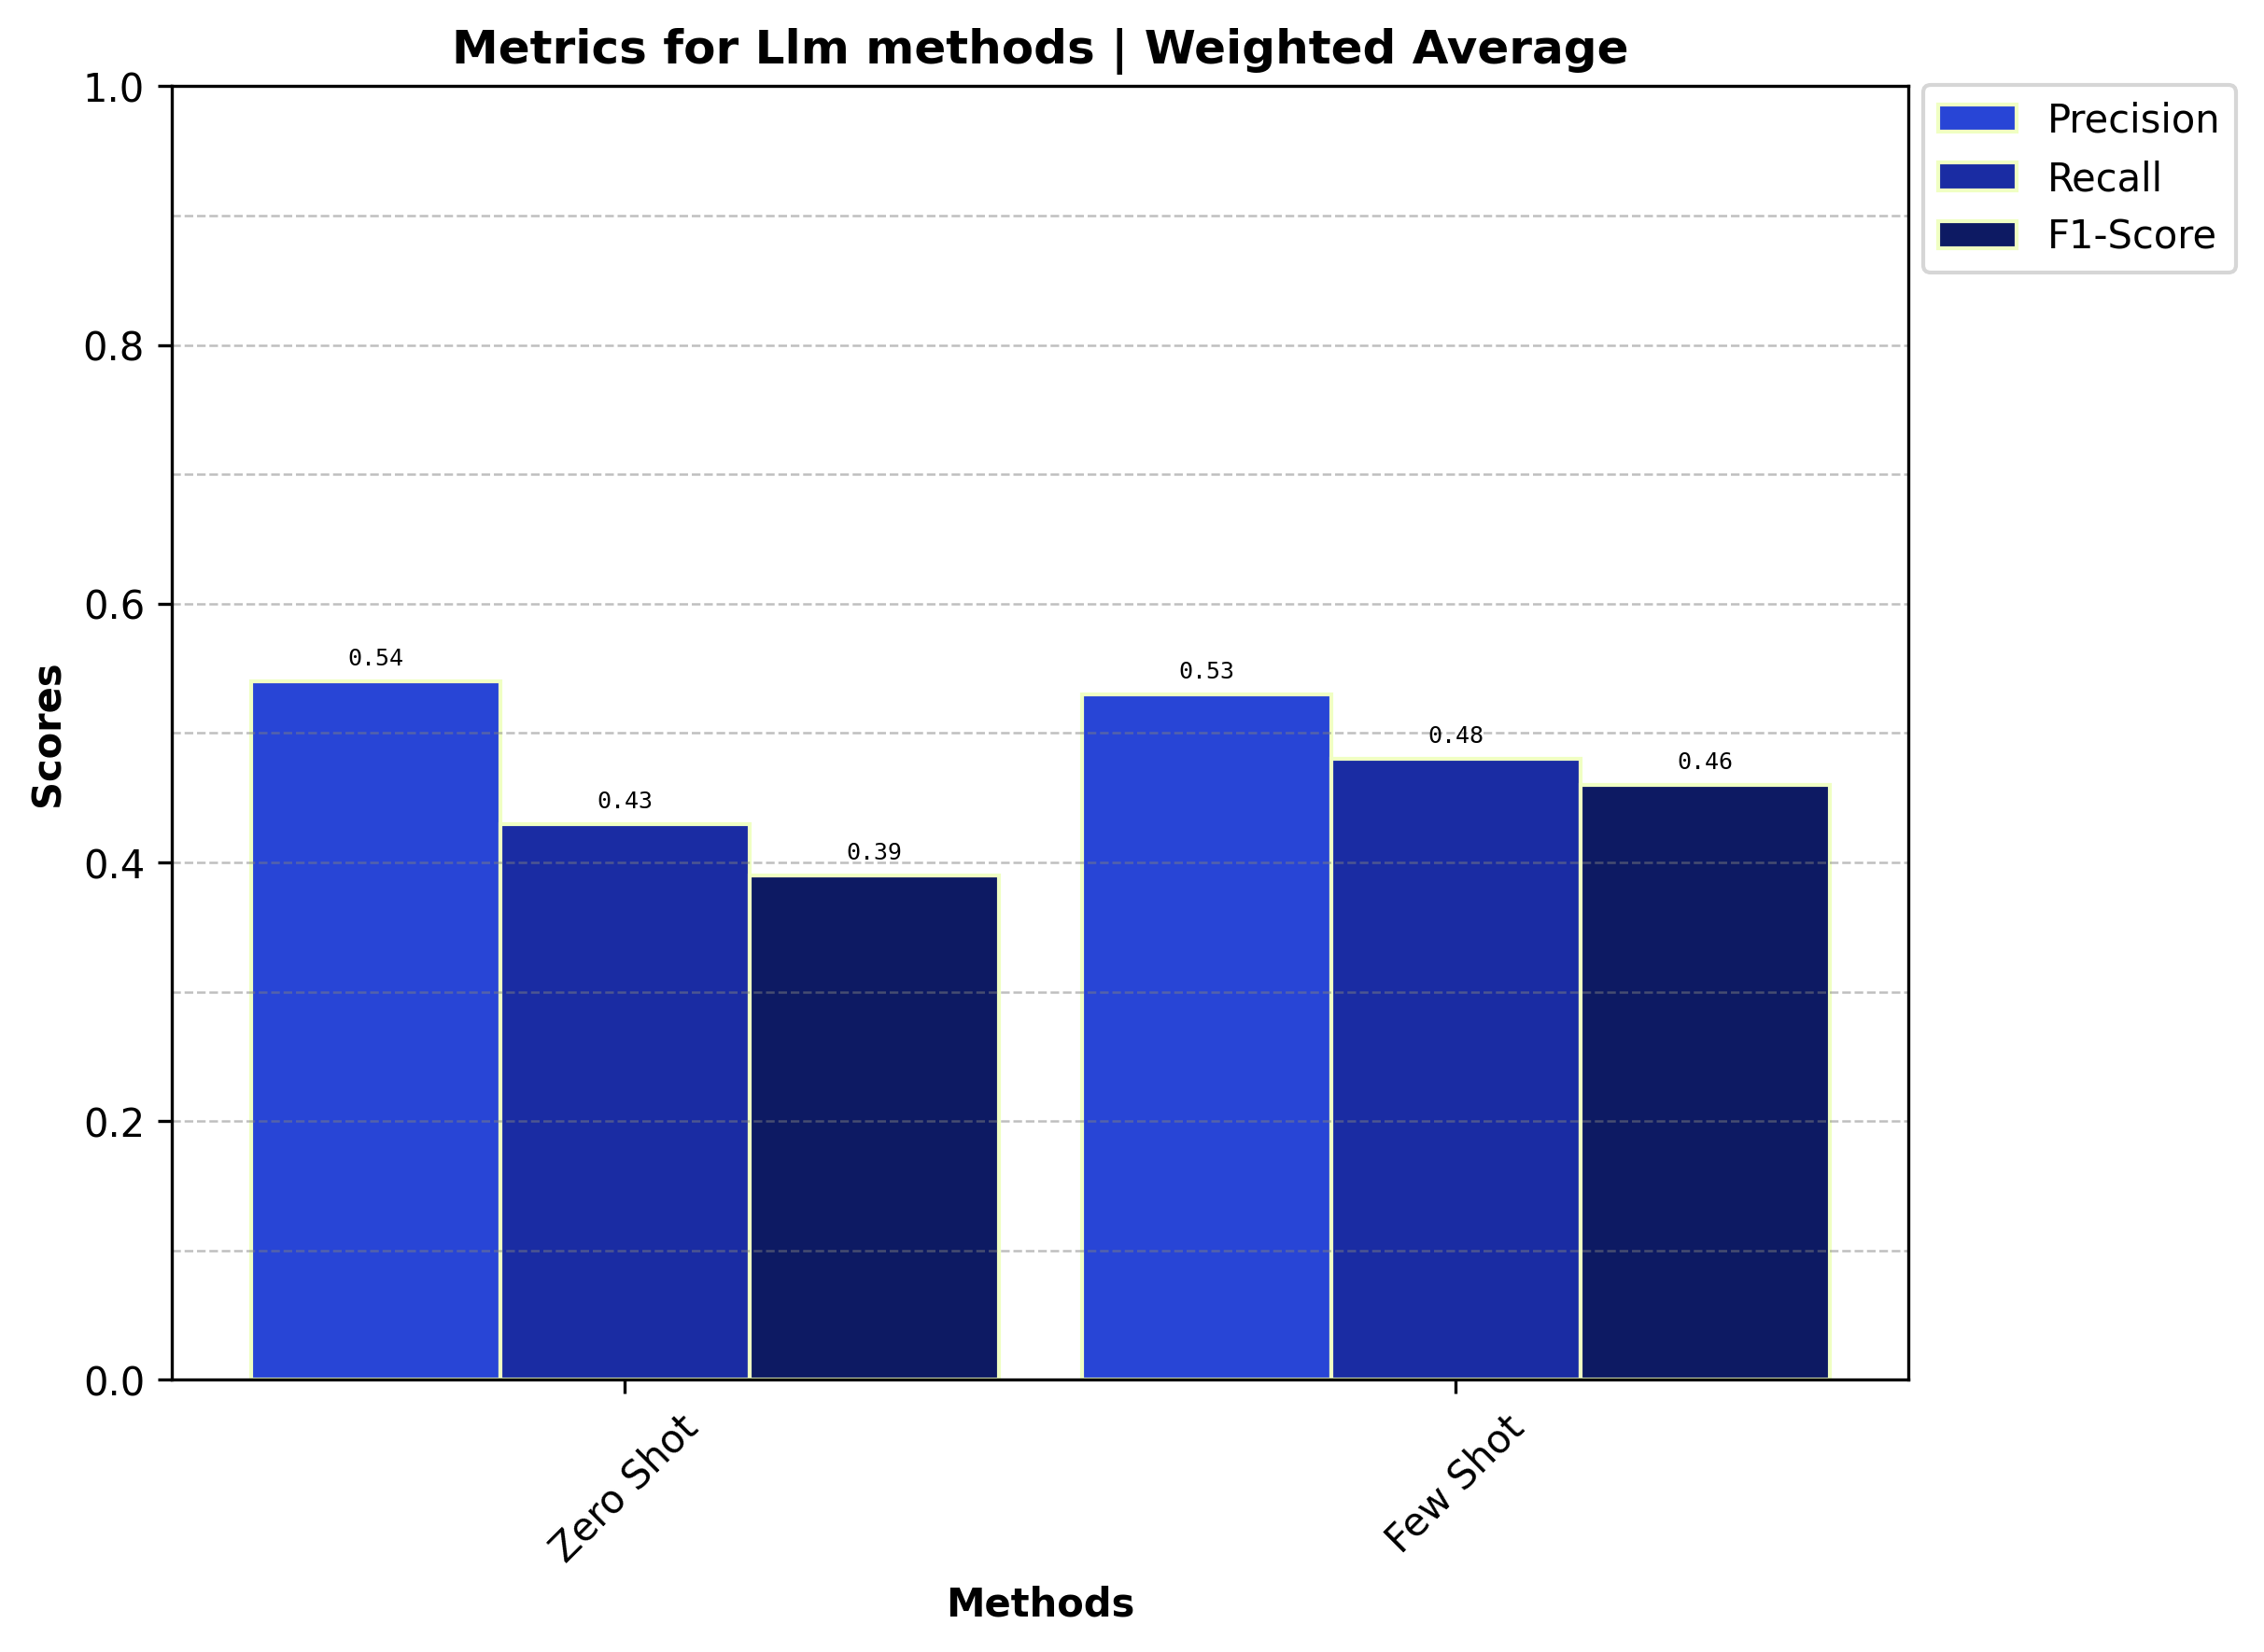

In [36]:
display_approach_barplot(data['main']['LLM'])

##**Migliori performance per ogni approccio**

Nel dataset **main** notiamo una netta superiorità di Fasttext (ML) seguita dalla Weight Extraction (RB) e poi da Gemini Few-Shot (LLM): sottolineiamo come questi metodi abbiano predetto i testi partendo da una base di esempi (dataset di training per RB e ML, e alcuni esempi mostrati al LLM).

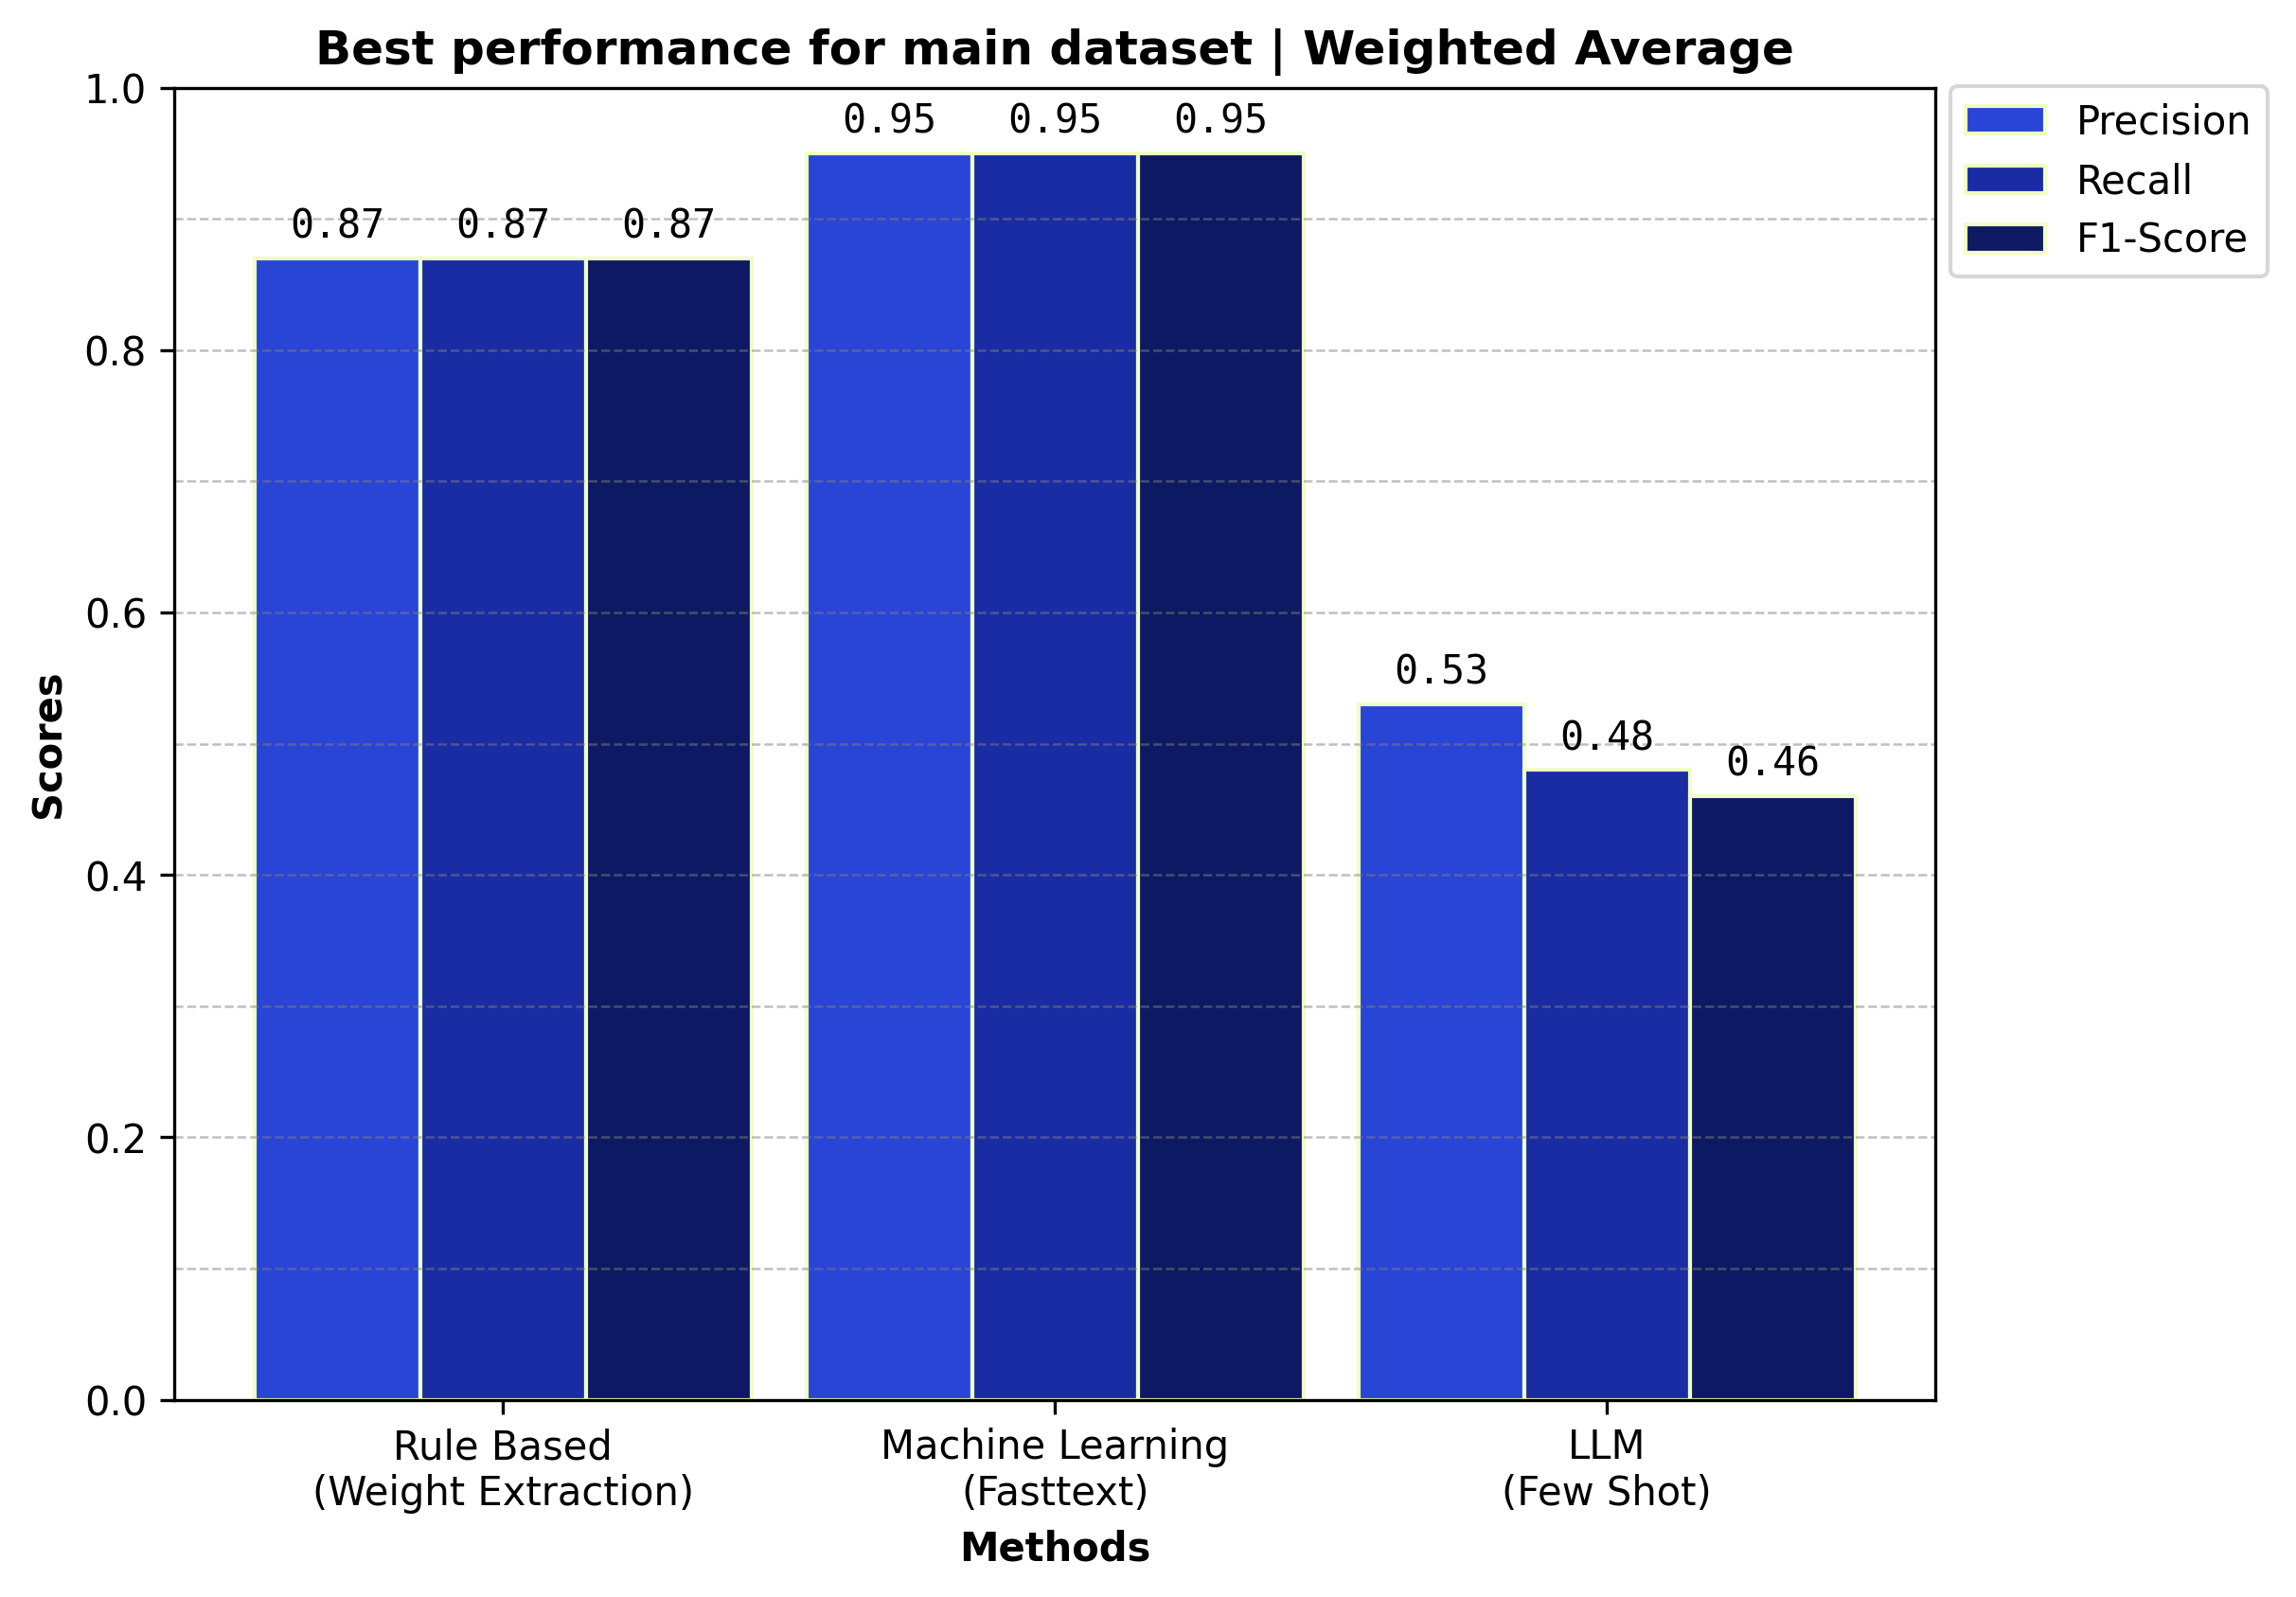

In [37]:
display_best_approaches_barplot(best_across_approaches_MAIN)

Tuttavia, notiamo anche come in RB il metodo Weight Extraction sia stato battuto dalla formula di Flesch-Kincaid, mentre per ML il metodo migliore sembra essere ancora Fasttext (nonostante una performance quasi 4 volte inferiore):

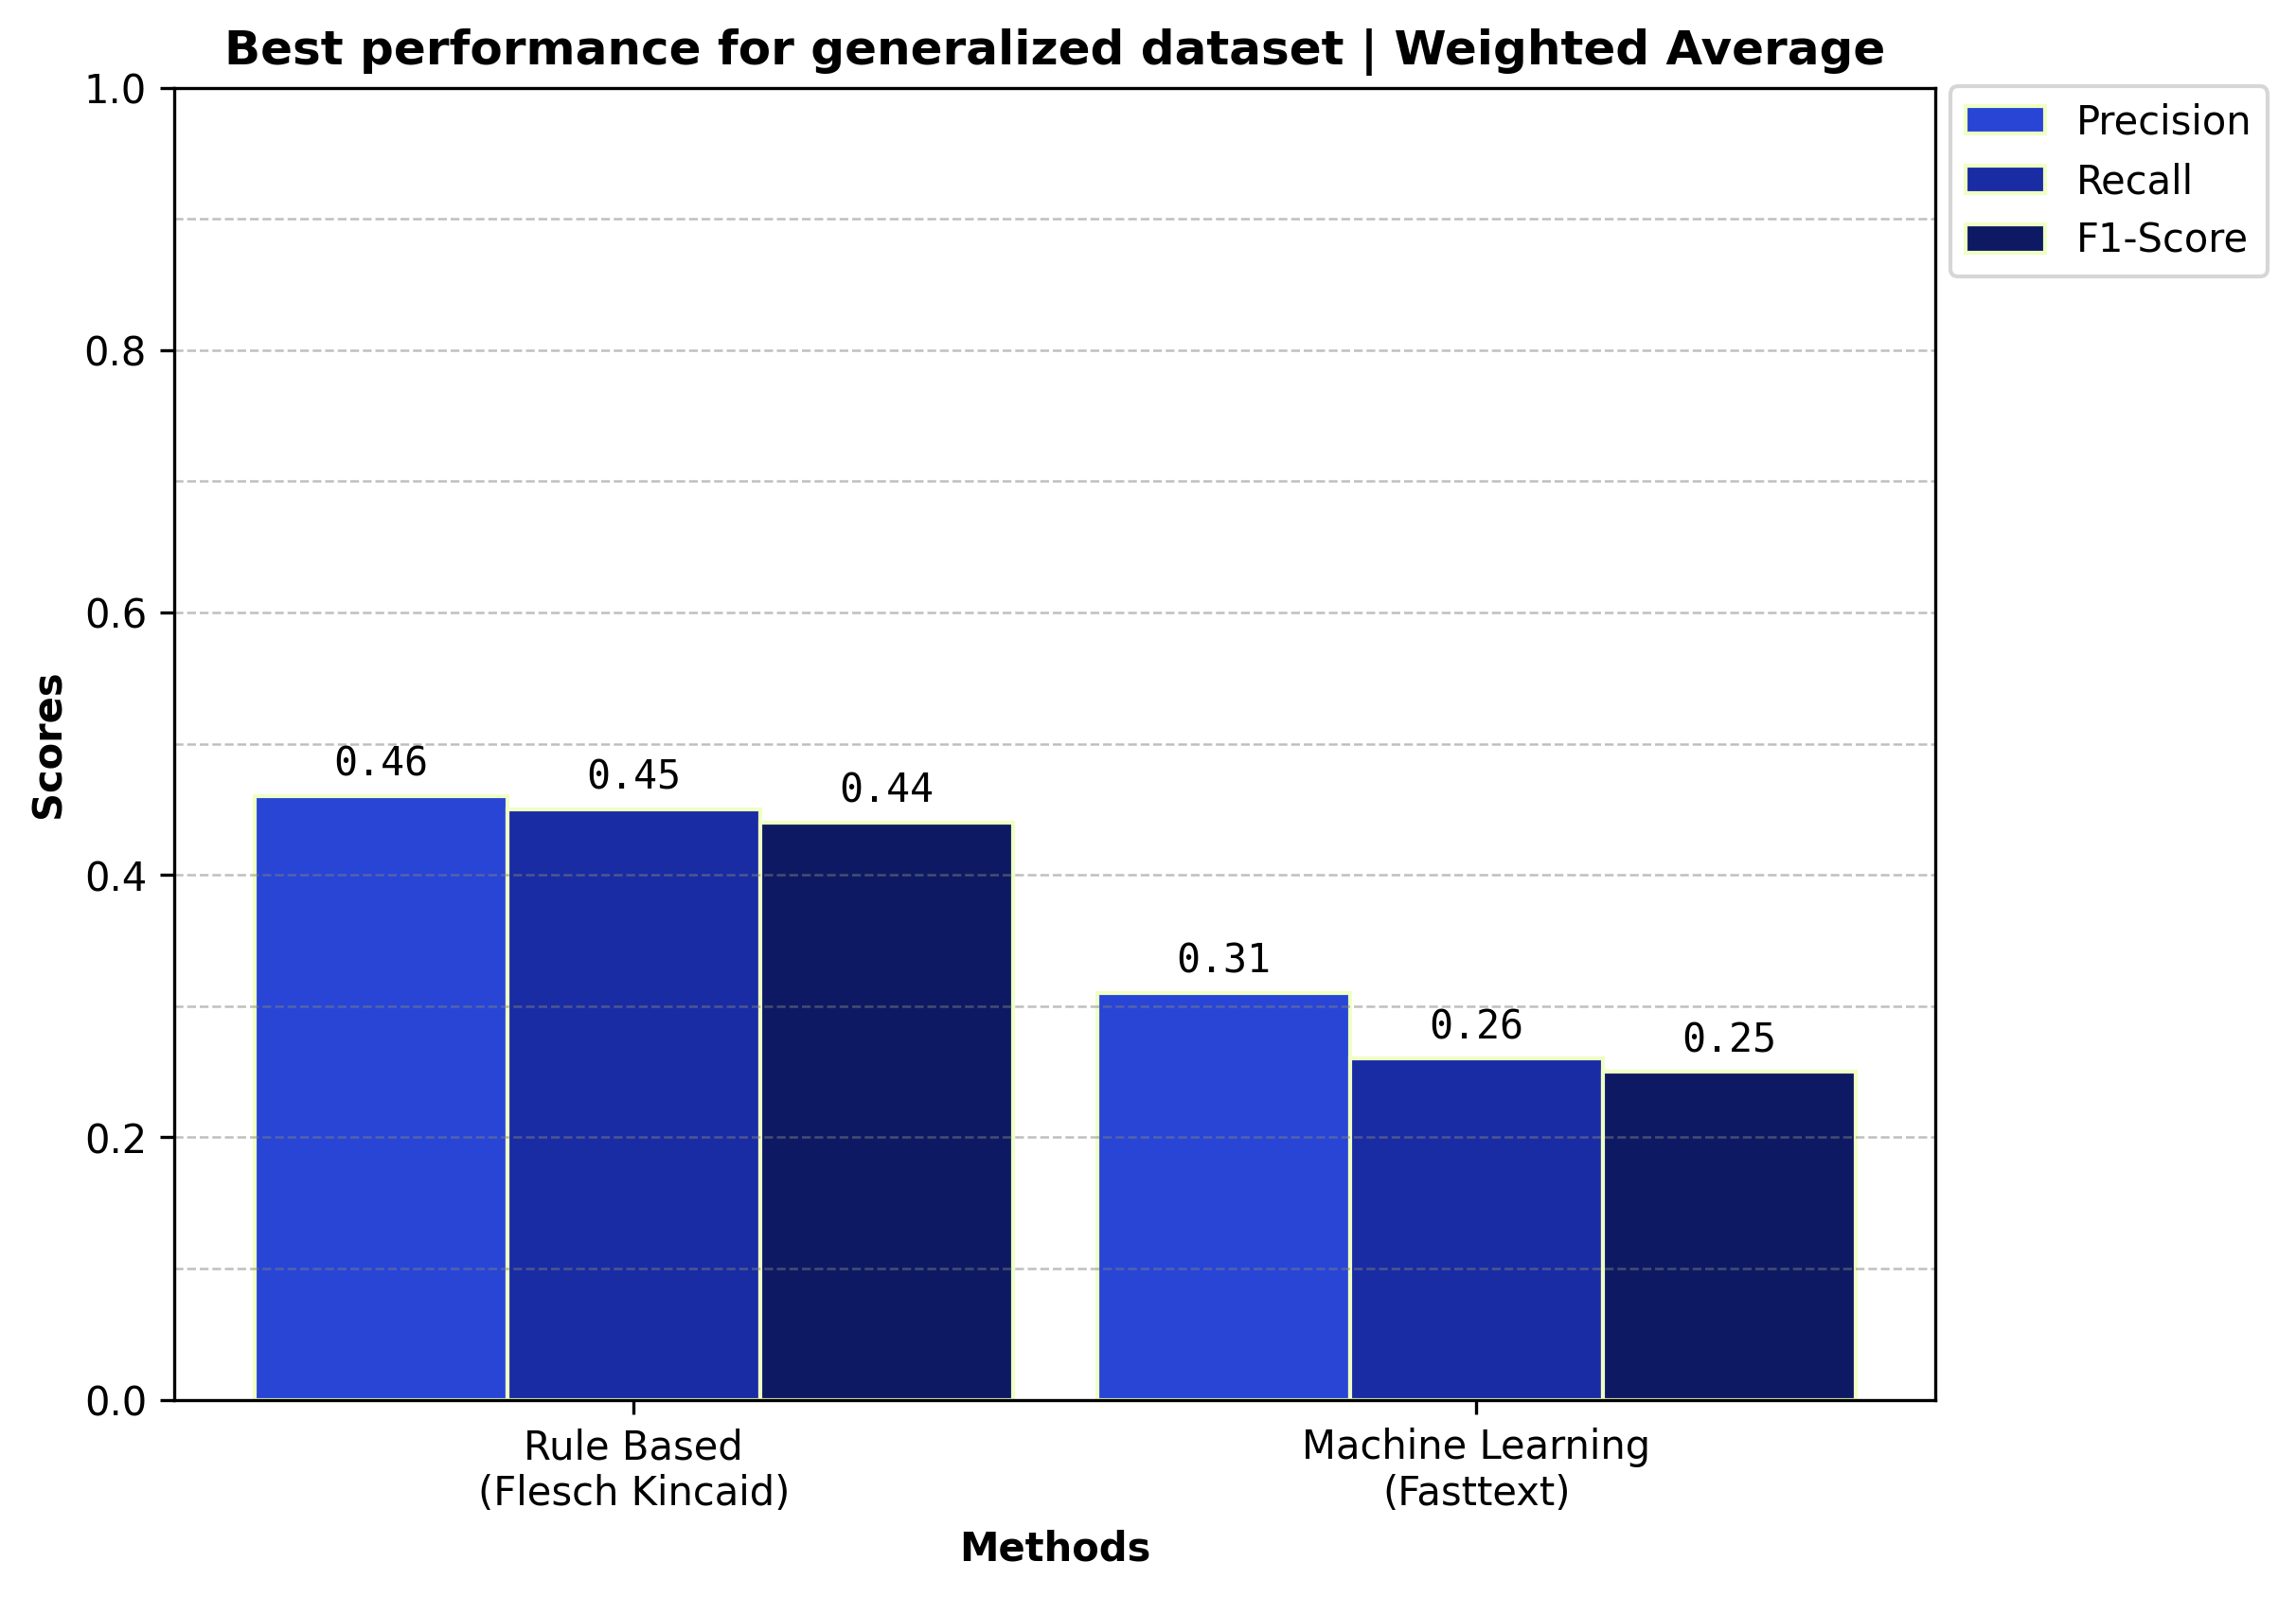

In [38]:
display_best_approaches_barplot(best_across_approaches_GENERALIZED)

#**Limiti**
L'analisi presenta vari limiti da non ignorare:

1. A prescindere dalle performance, è importante sottolineare come questi metodi non possano predire l'abilità linguistica di un utente nella sua interezza, dato che predicono solamente 1 delle 4 competenze che compongono il livello linguistico (ricezione scritta, ricezione orale; **produzione scritta**, produzione orale) ;

5. Questi metodi si fondano in ogni caso sulla natura unicamente strutturale della lingua, non su quella pragmatica e semantica: un utente di livello alto (B2, C1), tra le altre cose, deve dimostrare anche la capacità di produrre e recepire significati impliciti ;

2. I testi utilizzati per il training/testing non tengono conto degli errori grammaticali/lessicali/sintattici, molto importanti per una valutazione congrua (un testo può usare lessico e strutture complesse ma se sono stati commessi molti errori di grammatica, la prova non è superata) ;

3. Il dataset di training, essendo legato a prove scritte dell'ente Cambridge, è composto da testi che devono seguire una determinata struttura (ad esempio, l'*essay*, è composto da un'introduzione, da vari paragrafi argomentati ...) : ciò potrebbe spiegare il forte *generalization gap* tra i due dataset di testing, dato che il secondo è composto per lo più da testi di natura più generica che, proprio per questo motivo, vengono predetti con difficoltà dai vari modelli;

6. Alcuni metodi presentano a priori dei deficit:
    * **Metodi lessicali**: si fondano solamente sulle parole in quanto entità singole e non come elementi legati tra loro (tralaciando quindi la sintassi) ;
    * **Formule di leggibilità**: queste formule sono nate con uno scopo preciso e funzionano meglio o peggio in base alla natura del testo (ad esempio, Flesch-Kincaid è usata per testi tecnici della Marina statunitense, ma anche per testi più generali *[1]*). Formule come Coleman-Liau e ARI invece tralasciano le sillabe e si focalizzano per lo più su caratteri singoli che sulle sillabe ;
    * **Machine Learning** : è fortemente influenzato dal dataset di training ;
    * **LLM**: nonostante le performance relativamente basse, è possibile che il modello sia stato allenato anche sui testi che troviamo nei dataset di questo progetto.

4. Nelle varie Heatmap notiamo come ci siano costantemente delle migliori performance nel predire i testi "agli estremi" (A1 e C1): è complicato per il modello distinguere i testi "intermedi". Ciò si potrebbe verificare perché, oltre alla grande differenza tra i due livelli agli opposti, è implicito che un utente capace di produrre un testo livello C1 abbia abilità linguistiche, automaticamente, di livello B2, B1, A2 e A1 (un utente C1 sa comprendere/produrre un testo B1, il contrario invece è molto improbabile) ;

#**Conclusioni**

Secondo i vari risultati sembra che, in base ai metodi utilizzati, non ci sia ancora alcun modo affidabile per predire con un buona probabilità il livello CEFR di un testo. Tutti i metodi con miglior performance (*Weighted F1-Score* maggiore di 0.7) sono stati allenati su un dataset di training e hanno perso molta della loro efficienza sul dataset generalizzato: un buona idea potrebbe essere ampliare il dataset di training, includendo testi con natura diversa e varia e non solamente basati sulle strutture testuali dell'esame Cambridge.

#**Altri notebook**
Numero|Titolo|URL
----|------|-------
1 / 3|Introduzione, gestione dei dataset e preprocessing|[link](https://colab.research.google.com/drive/11klGGwytqSNmE_WaWieAbVbtZL_qiWkl?authuser=4#scrollTo=75d3EdOJariY)
2 / 3|Costruzione dei modelli, training e primo testing|[link](https://colab.research.google.com/drive/1XXkGnLBFJmKjBbNl1a-1Q-73PIfT2QpZ?authuser=4#scrollTo=2PgXRu6P2iTy)
**3 / 3**|**Grafici e conclusioni**|[link](https://colab.research.google.com/drive/1-jy9wDUCTJ5TB1xcsnP9B_6wdTFvktw6?authuser=4#scrollTo=TT9PH3RlpgML)

#**Note**
Numero|Titolo|URL
----|------|-------
*[1]*|Flesch-Kincaid|[link](https://en.wikipedia.org/wiki/Flesch%E2%80%93Kincaid_readability_tests#:~:text=%22The%20Flesch%E2%80%93Kincaid%22%20(F,policies.%5B3%5D)
